In [4]:
import geopandas as gpd
import pandas as pd
import osmnx as ox
from shapely.geometry import LineString, Point, Polygon
#from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import fiona
import rasterio
from rasterio.plot import show, show_hist
from rasterio.merge import merge
from osgeo import gdal, ogr, osr
from rasterio.mask import mask
from shapely import wkt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import os 

idx = pd.IndexSlice

In [5]:
# Toggle between users

upath = r'/home/babakebrahimi/s3/data'

In [197]:
# calculating shared walls between buildings
def Shared_wall(read_shp, write_shp):
    # Read the shapefile
    building = gpd.read_file(read_shp).to_crs('EPSG:3857')  # Assume initial projection to metric system

    # Create empty columns for NEIGHBORS, WALL_LENGTH, WALL_HEIGHT, SHARED_WALL
    building['NEIGHBORS'] = None
    building['WALL_LENGTH'] = None
    building['WALL_HEIGHT'] = None
    building['SHARED_WALL'] = None

    # Create a spatial index to speed up intersection checks
    spatial_index = building.sindex

    neighbors_list = []
    wall_length_list = []
    wall_height_list = []
    shared_wall_list = []

    # Get the total number of buildings for percentage tracking
    total_buildings = len(building)
    last_printed_percentage = 0

    # Iterate through each building
    for index, row in building.iterrows():
        # Calculate the current percentage of progress
        current_percentage = (index / total_buildings) * 100
        
        # Only print the progress if it exceeds the last printed by 5%
        if current_percentage - last_printed_percentage >= 5:
            print(f"Progress: {int(current_percentage)}%")
            last_printed_percentage = int(current_percentage)

        # Find potential neighbors using the spatial index (bounding box first for speed)
        possible_matches_index = list(spatial_index.intersection(row.geometry.bounds))
        possible_matches = building.iloc[possible_matches_index]

        # Now filter by actual intersection (geometry)
        intersecting_buildings = possible_matches[~possible_matches.geometry.disjoint(row.geometry)]

        # Get the list of 'id' for these buildings, excluding self
        neighbors = intersecting_buildings[intersecting_buildings['id'] != row['id']]['id'].tolist()
        neighbors_list.append(neighbors)

        # Calculate shared wall lengths and heights for neighbors
        wall_lengths = []
        wall_heights = []
        shared_wall_areas = []

        for neighbor_id in neighbors:
            neighbor_row = building[building['id'] == neighbor_id].iloc[0]

            # Calculate the shared wall length
            shared_length = row.geometry.intersection(neighbor_row.geometry).length
            wall_lengths.append(shared_length)

            # Calculate shared wall height (min of two buildings)
            shared_height = min(row['height'], neighbor_row['height'])
            wall_heights.append(shared_height)

            # Calculate the shared wall area
            shared_wall_areas.append(shared_length * shared_height)

        wall_length_list.append(wall_lengths)
        wall_height_list.append(wall_heights)
        shared_wall_list.append(sum(shared_wall_areas))

    # Assign computed lists back to the building DataFrame
    building['NEIGHBORS'] = neighbors_list
    building['WALL_LENGTH'] = wall_length_list
    building['WALL_HEIGHT'] = wall_height_list
    building['SHARED_WALL'] = shared_wall_list

    # Final 100% progress
    print("Progress: 100% - Completed")

    # Save the result to a new shapefile, first converting back to EPSG:4326 (latitude/longitude)
    return building.to_crs(epsg=4326).to_file(write_shp, driver='SQLite')

In [4]:
%%time
Shared_wall(os.path.join(upath,r'Barcelona/EUBUCCO/file/barca_build.sqlite'),
            os.path.join(upath,r'shapefile/Barcelona/Barcelona_building_shared-wall.sqlite'))

CPU times: user 27.5 s, sys: 1.91 s, total: 29.5 s
Wall time: 1min 59s


In [ ]:
# # Fetch Building Polygons from OSM
# # area of interest
# place_name = "Barcelona"

# # Fetch building footprints using the features module
# buildings = ox.features_from_polygon(ox.geocode_to_gdf(place_name).geometry[0], tags={'building': True})[['geometry', 'building']]
# # filtering only polygon data out from the oslo data
# buildings = buildings.loc[buildings.geometry.geom_type=='Polygon']

# # Ensure the 'geometry' column is present and valid
# buildings = buildings[buildings['geometry'].notna()]

# # Set CRS for buildings and points
# buildings = gpd.GeoDataFrame(buildings, geometry='geometry', crs='EPSG:4326')
# points_gdf = Barca

# # Ensure CRS consistency
# buildings = buildings.to_crs(epsg=4326)
# points_gdf = points_gdf.to_crs(epsg=4326)

# Barca_build = buildings.sjoin(points_gdf, how='left').droplevel(0)


In [ ]:
Barca_build_ene = Barca_build[['geometry','CONSUM_ENE','ANY_CONSTR','DATA_ENTRA']]
Barca_build_ene = Barca_build_ene.dropna(subset=['CONSUM_ENE'])

In [35]:
Barca_build_ene.head()

,geometry,CONSUM_ENE,ANY_CONSTR,DATA_ENTRA
osmid,,,,
18606527,"POLYGON ((2.17513 41.37646, 2.17507 41.37646, ...",374.60,1970,2.013090e+13
18606527,"POLYGON ((2.17513 41.37646, 2.17507 41.37646, ...",171.64,None,2.022070e+13
18606527,"POLYGON ((2.17513 41.37646, 2.17507 41.37646, ...",161.87,None,2.018072e+13
18606527,"POLYGON ((2.17513 41.37646, 2.17507 41.37646, ...",259.80,None,2.023112e+13
18606527,"POLYGON ((2.17513 41.37646, 2.17507 41.37646, ...",161.79,None,2.023041e+13


<AxesSubplot: >

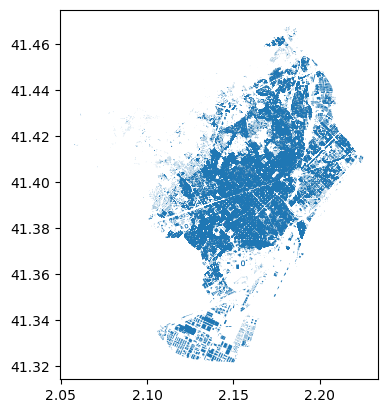

In [21]:
Barca_build.plot()

In [ ]:
# # loading EUBUCCO data for Barcelona only
# data = gpd.read_file(os.path.join(upath, r'Barcelona/EUBUCCO/BCN.geojson'))
# # Set the CRS to EPSG:25831 without transforming the coordinates. This is needed as the EUBUCCO data has a wrong CRF code (i.e., epsg:4326)
# # which doesnt match its geometries coordinates.
# data = data.set_crs('EPSG:25831', allow_override=True).to_crs('EPSG:4326')

In [ ]:
# data = gpd.read_file(os.path.join(upath, r'Barcelona/EUBUCCO/BCN.geojson'))
# # data.plot()

In [6]:
# %%time
# dat = gpd.read_file(os.path.join(upath, r'Barcelona/EUBUCCO/v0_1-ESP.gpkg'))

CPU times: user 1min 29s, sys: 16.3 s, total: 1min 45s
Wall time: 8min 25s


The daily average air temperature data are extracted from Meteostat: https://meteostat.net/en/place/es/barcelona?s=08181&t=2016-01-01/2020-12-31

In [71]:
# Python script to calculate number of heating days for different years

# Daily average temperatures in Celsius for different years
df1 = pd.read_excel(os.path.join(upath, r'tabula-episcope/Barcelona_weather_2010_2015.xlsx'))
df2 = pd.read_excel(os.path.join(upath, r'tabula-episcope/Barcelona_weather_2016_2020.xlsx'))
df3 = pd.read_excel(os.path.join(upath, r'tabula-episcope/Barcelona_weather_2021_2023.xlsx'))

temperature_data = pd.concat([df1, df2, df3], ignore_index=True)

# Convert the 'date' column to datetime, assuming the format is 'YYYY-MM-DD'
temperature_data['date'] = pd.to_datetime(temperature_data['date'], format='%Y-%m-%d')

# Extract year from the date
temperature_data['year'] = temperature_data['date'].dt.year

# Reference temperature in Celsius
reference_temperature = 13

# Function to calculate the number of heating days
def calculate_heating_days(temperatures, ref_temp):
    hdd_total = 0
    for temp in temperatures:
        if temp <= ref_temp:
            hdd_total += 1
    return hdd_total

# Use the 'tavg' attribute for the daily average temperature instead of 'Middeltemperatur (døgn)'
hdd_per_year = {}
for year, group in temperature_data.groupby('year'):
    temperatures = group['tavg']  # assuming the daily average temperatures are stored in a column called 'tavg'
    hdd_per_year[year] = calculate_heating_days(temperatures, reference_temperature)

# Print the number of heating days for each year
for year, hdd in hdd_per_year.items():
    print(f"Total Heating Days for {year}: {hdd}")

Total Heating Days for 2010: 133
Total Heating Days for 2011: 108
Total Heating Days for 2012: 113
Total Heating Days for 2013: 117
Total Heating Days for 2014: 107
Total Heating Days for 2015: 116
Total Heating Days for 2016: 114
Total Heating Days for 2017: 119
Total Heating Days for 2018: 127
Total Heating Days for 2019: 127
Total Heating Days for 2020: 112
Total Heating Days for 2021: 132
Total Heating Days for 2022: 115
Total Heating Days for 2023: 102


In [18]:
%%time
# Shaded wall
df_SW = gpd.read_file(os.path.join(upath,r'shapefile/Barcelona/Barcelona_building_shared-wall.sqlite'))
# read energy certified building in Barcelona province (data are attained from URL: https://sig.gencat.cat/visors/hipermapa.html?param=param&color=vermell&background=orto_ICC_grisos&BBOX=410860,4567836,419125,4572271&layers=ENERGIA_CERTIFICATS_EDIFICIS) 
df = gpd.read_file(os.path.join(upath, 'Barcelona/Energy_certification/Shapefile/ENERGIA_CERTIFICATS_EDIFICIS.shp'))

# considering only Barcelona data
Barca = df[df['NOM_PROVIN']=='Barcelona']

# Keywords indicating residential buildings
residential_keywords = ['Habitatges', 'Lloguer', 'Alquiler', 'Compra', 'Venda', 'Venta']

# Filter DataFrame to include only residential buildings
Barca = Barca[
    Barca['MOTIU_CERT'].apply(lambda desc: 
        any(keyword in desc for keyword in residential_keywords) and 
        'administració pública' not in desc.lower() and 
        'administrativo' not in desc.lower() and 
        'comercial' not in desc.lower()
    )
].copy()  # Use .copy() to avoid the SettingWithCopyWarning

# Define the mapping from US_EDIFICI labels to clusters
building_cluster_mapping = {
    "Habitatge individual en bloc d'habitatges": 'AB',  # Apartment Building
    'Habitatge unifamiliar': 'SFH',                     # Single-Family House
    'Vivienda unifamiliar': 'SFH',                      # Single-Family House
    'Vivienda individual en bloque de viviendas': 'AB', # Apartment Building
    'Terciari': None,                                   # Exclude tertiary buildings
    "Bloc d'habitatges plurifamiliar": 'MFH',           # Multi-Family House
    'Terciario': None,                                  # Exclude tertiary buildings
    "Bloc d'habitatges": 'MFH',                         # Multi-Family House
    'Bloque de viviendas plurifamiliar': 'MFH',         # Multi-Family House
    'Bloque de viviendas': 'MFH',                       # Multi-Family House
    'Habitatge Unifamiliar': 'SFH',                     # Single-Family House
    None: None                                          # Handle missing values
}

# Create a new column for building clusters
Barca['Building_Cluster'] = Barca['US_EDIFICI'].map(building_cluster_mapping)

# Filter out rows where Building_Cluster is None (non-residential or missing values)
Barca = Barca[Barca['Building_Cluster'].notna()].copy()  # Use .copy() again

# Define keywords for renovation, deep renovation, and as-built
renovation_keywords = [
    'reformes', 'ampliacions', 'Modificació del certificat', 'Renovació', 'renovación', 'etiqueta energètica'
]

deep_renovation_keywords = [
    'gran rehabilitació', 'gran rehabilitación', 'ampliació', 'ampliación', 'eficiència energètica', 'rehabilitació'
]

as_built_keywords = [
    'Nova construcció', 'Nueva construcción', 'as-built', 'Construcció original', 'Construcción original'
]

# Function to classify building status
def classify_renovation(description):
    description_lower = description.lower() if isinstance(description, str) else ''
    
    if any(keyword in description_lower for keyword in deep_renovation_keywords):
        return 'Deep Renovation'
    elif any(keyword in description_lower for keyword in renovation_keywords):
        return 'Renovation'
    elif any(keyword in description_lower for keyword in as_built_keywords):
        return 'As-Built'
    else:
        return 'Unknown'

# Apply classification to your dataset
Barca['Renovation_Status'] = Barca['MOTIU_CERT'].apply(classify_renovation)
    
# Ensure CRS consistency
SW = df_SW.to_crs(epsg=4326)
point_df = Barca.to_crs(epsg=4326)

# Overlaying the geometries
SW_Barca_EC = SW.sjoin(point_df[['CONSUM_ENE','DATA_ENTRA','Building_Cluster','Renovation_Status','geometry']], how='left')

# Drop rows where DATA_ENTRA has NaN values
SW_Barca_EC = SW_Barca_EC.dropna(subset=['DATA_ENTRA'])

SW_Barca_EC['scaled_data_entra'] = SW_Barca_EC['DATA_ENTRA'] / 1e6  # Scaling to milliseconds

# Convert the scaled_data_entra to string, then to datetime using the format 'YYYYMMDD'
SW_Barca_EC['date_EC'] = pd.to_datetime(SW_Barca_EC['scaled_data_entra'].astype(int).astype(str), format='%Y%m%d', errors='coerce')

# Extract the year from the datetime
SW_Barca_EC['year'] = SW_Barca_EC['date_EC'].dt.year

# Check the first few rows
print(SW_Barca_EC[['DATA_ENTRA', 'scaled_data_entra', 'date_EC', 'year']].head())

# Save the file
SW_Barca_EC.to_file(os.path.join(upath,r'shapefile/Barcelona/Barcelona_building_shared-wall_energy_certificates.sqlite'), driver='SQLite')


     DATA_ENTRA  scaled_data_entra    date_EC  year
0  2.015011e+13         20150113.0 2015-01-13  2015
0  2.016080e+13         20160805.0 2016-08-05  2016
1  2.021052e+13         20210519.0 2021-05-19  2021
1  2.017043e+13         20170427.0 2017-04-27  2017
1  2.024010e+13         20240103.0 2024-01-03  2024
CPU times: user 42.5 s, sys: 3.38 s, total: 45.8 s
Wall time: 1min 12s


In [3]:
# ##  Extract residential building types from OpenStreetMap (OSM) for Barcelona

# # Define the place of interest
# place_name = "Barcelona, Spain"

# # Building types of interest
# building_types = ["house", "terrace", "rowhouse", "apartments", "residential"]

# # Query the data
# gdf = ox.geometries_from_place(
#     place_name, 
#     tags={"building": building_types}
# )

# # Filter out only residential buildings explicitly defined
# gdf_residential = gdf[gdf['building'].isin(building_types)]

# # Save to a file if needed
# gdf_residential.to_file(os.path.join(upath,r'shapefile/Barcelona/barcelona_residential_buildings.geojson'), driver="GeoJSON")

# print(f"Extracted {len(gdf_residential)} residential buildings in Barcelona.")

/tmp/ipykernel_109/1306029132.py:10: UserWarning: The `geometries` module and `geometries_from_X` functions have been renamed the `features` module and `features_from_X` functions. Use these instead. The `geometries` module and function names are deprecated and will be removed in a future release.
  gdf = ox.geometries_from_place(


Extracted 46272 residential buildings in Barcelona.


In [4]:

# Define the place of interest
place_name = "Barcelona, Spain"

# Building types of interest
building_types = ["house", "terrace", "rowhouse", "apartments", "residential"]

# Query the residential buildings
gdf = ox.geometries_from_place(
    place_name, 
    tags={"building": building_types}
)

# Filter out only residential buildings explicitly defined
gdf_residential = gdf[gdf['building'].isin(building_types)]

# Exclude geometries that are "Point"
gdf_residential_filtered = gdf_residential[gdf_residential.geometry.type != 'Point'][['building', 'geometry']]

# Define mapping for the 'building' column
building_to_bolig_type = {
    'apartments': 'AB',  # Apartment building
    'residential': 'MFH',  # Multi-family house
    'house': 'SFH',  # Single-family house
    'terrace': 'TH'  # Townhouse or rowhouse
}

# Create the 'bolig_type' column using the mapping
gdf_residential_filtered['bolig_type'] = gdf_residential_filtered['building'].map(building_to_bolig_type)

# Handle cases where 'building' values are not in the mapping
gdf_residential_filtered['bolig_type'] = gdf_residential_filtered['bolig_type'].fillna('Unknown')

# Query for points of interest (restaurants, shops, grocery stores)
poi_types = [
    "restaurant", "cafe", "bar", "pub", "fast_food",  # Food and beverage
    "shop", "supermarket", "convenience", "mall", "department_store",  # Retail
    "office", "industrial", "commercial", "warehouse",  # Business and industrial
    "school", "university", "college", "kindergarten",  # Educational
    "hospital", "clinic", "pharmacy",  # Healthcare
    "hotel", "hostel", "motel", "guest_house",  # Accommodation
    "church", "mosque", "temple", "synagogue",  # Religious
    "library", "theatre", "cinema", "museum", "arts_centre",  # Cultural
    "sports_centre", "stadium", "gym", "recreation_ground",  # Sports and recreation
    "government", "courthouse", "police", "fire_station",  # Government and services
    "transport", "bus_station", "train_station", "airport",  # Transportation hubs
    "construction", "parking", "fuel", "car_wash", "garage"  # Miscellaneous infrastructure
]

gdf_pois = ox.geometries_from_place(
    place_name,
    tags={
        "amenity": poi_types,
        "building": [b for b in poi_types if b not in ["house", "residential", "terrace", "apartments"]]
    }
)


# Ensure both datasets have the same CRS
gdf_residential_filtered = gdf_residential_filtered.to_crs(gdf_pois.crs)

# Perform spatial join to find residential buildings near POIs
gdf_residential_with_poi = gpd.sjoin(
    gdf_residential_filtered, 
    gdf_pois, 
    how="inner", 
    predicate="intersects"
)

# Exclude residential buildings that intersect with POIs
residential_exclusive = gdf_residential_filtered.loc[
    ~gdf_residential_filtered.index.isin(gdf_residential_with_poi.index)
]

# # Save the filtered result
# residential_exclusive.to_file(os.path.join(upath,r'shapefile/Barcelona/Barcelona_building_shared-wall_energy_certificates_OSM-build-type_v2.sqlite'), driver='SQLite')

print(f"Extracted {len(residential_exclusive)} 100% residential buildings in Barcelona.")


/tmp/ipykernel_241/342860853.py:8: UserWarning: The `geometries` module and `geometries_from_X` functions have been renamed the `features` module and `features_from_X` functions. Use these instead. The `geometries` module and function names are deprecated and will be removed in a future release.
  gdf = ox.geometries_from_place(
/tmp/ipykernel_241/342860853.py:49: UserWarning: The `geometries` module and `geometries_from_X` functions have been renamed the `features` module and `features_from_X` functions. Use these instead. The `geometries` module and function names are deprecated and will be removed in a future release.
  gdf_pois = ox.geometries_from_place(
/home/babakebrahimi/.local/lib/python3.9/site-packages/osmnx/features.py:281: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  polygon = gdf_place["geometry"].unary_union


Extracted 39123 100% residential buildings in Barcelona.


In [ ]:
# # Exclude geometries that are "Point"
# gdf_residential_filtered = gdf_residential[gdf_residential.geometry.type != 'Point'][['building', 'geometry']]

# # Define mapping for the 'building' column
# building_to_bolig_type = {
#     'apartments': 'AB',  # Apartment building
#     'residential': 'MFH',  # Multi-family house
#     'house': 'SFH',  # Single-family house
#     'terrace': 'TH'  # Townhouse or rowhouse
# }

# # Create the 'bolig_type' column using the mapping
# gdf_residential_filtered['bolig_type'] = gdf_residential_filtered['building'].map(building_to_bolig_type)

# # Handle cases where 'building' values are not in the mapping
# gdf_residential_filtered['bolig_type'] = gdf_residential_filtered['bolig_type'].fillna('Unknown')


                         building bolig_type  \
element_type osmid                             
way          34116398  apartments         AB   
             34116403  apartments         AB   
             34116409  apartments         AB   
             34116412  apartments         AB   
             34116416  apartments         AB   

                                                                geometry  
element_type osmid                                                        
way          34116398  POLYGON ((2.17471 41.40896, 2.17471 41.40894, ...  
             34116403  POLYGON ((2.17576 41.40876, 2.17576 41.40858, ...  
             34116409  POLYGON ((2.17471 41.4096, 2.17472 41.4096, 2....  
             34116412  POLYGON ((2.17407 41.41075, 2.17405 41.41076, ...  
             34116416  POLYGON ((2.17462 41.41072, 2.1746 41.41072, 2...  


In [13]:
os.path.join(upath,r'shapefile/Barcelona_building_shared-wall_energy_certificates_OSM-build-type_v2.sqlite')

'/home/babakebrahimi/s3/data/shapefile/Barcelona_building_shared-wall_energy_certificates_OSM-build-type_v2.sqlite'

In [34]:
barca = gpd.read_file(os.path.join(upath,r'shapefile/Barcelona/Barcelona_building_shared-wall_energy_certificates.sqlite')).to_crs('EPSG:3857').reset_index(drop=True)

# Ensure CRS consistency
gdf_residential_filtered = residential_exclusive.to_crs(barca.crs).reset_index(drop=True)

# Compute centroids
gdf_residential_filtered['centroid'] = gdf_residential_filtered.geometry.centroid

# Create a new GeoDataFrame for centroids
centroids_gdf = gpd.GeoDataFrame(
    gdf_residential_filtered[['bolig_type']],
    geometry=gdf_residential_filtered['centroid'],
    crs=gdf_residential_filtered.crs
)

# Rename 'index_right' in the barca GeoDataFrame to avoid conflicts
if 'index_right' in barca.columns:
    barca = barca.rename(columns={'index_right': 'barca_index_right'})

# Perform the spatial join
overlay_result = gpd.sjoin(
    centroids_gdf,
    barca,
    how="right",
    predicate="intersects"
)

# Drop rows where 'bolig_type' is NaN
overlay_result = overlay_result.dropna(subset=['bolig_type'])

# Save the result if needed
overlay_result.to_file(os.path.join(upath,r'shapefile/Barcelona/Barcelona_building_shared-wall_energy_certificates_OSM-build-type_v2.sqlite'), driver='SQLite')

# Display the resulting GeoDataFrame
overlay_result.head()

,index_left,bolig_type,id,height,age,type,id_source,type_sourc,neighbors,wall_length,...,shared_wall,barca_index_right,consum_ene,data_entra,building_cluster,renovation_status,scaled_data_entra,date_ec,year,geometry
11797,5798.0,AB,v0.1-ESP.6.1.3.21_1-94,15.0,1961.0,residential,ES.SDGC.BU.4557801DF3845F,1_residential,[],[],...,0.0,1274973.0,254.64,2.018012e+13,AB,Unknown,20180117.0,2018-01-17,2018,"POLYGON ((246665.702 5074233.871, 246600.173 5..."
11798,5798.0,AB,v0.1-ESP.6.1.3.21_1-94,15.0,1961.0,residential,ES.SDGC.BU.4557801DF3845F,1_residential,[],[],...,0.0,1305701.0,196.17,2.015120e+13,AB,Unknown,20151203.0,2015-12-03,2015,"POLYGON ((246665.702 5074233.871, 246600.173 5..."
11799,5798.0,AB,v0.1-ESP.6.1.3.21_1-94,15.0,1961.0,residential,ES.SDGC.BU.4557801DF3845F,1_residential,[],[],...,0.0,1290549.0,181.72,2.022080e+13,AB,Unknown,20220803.0,2022-08-03,2022,"POLYGON ((246665.702 5074233.871, 246600.173 5..."
11800,5798.0,AB,v0.1-ESP.6.1.3.21_1-94,15.0,1961.0,residential,ES.SDGC.BU.4557801DF3845F,1_residential,[],[],...,0.0,1315208.0,190.51,2.023120e+13,AB,Unknown,20231204.0,2023-12-04,2023,"POLYGON ((246665.702 5074233.871, 246600.173 5..."
11801,5798.0,AB,v0.1-ESP.6.1.3.21_1-94,15.0,1961.0,residential,ES.SDGC.BU.4557801DF3845F,1_residential,[],[],...,0.0,1269421.0,145.57,2.014110e+13,AB,Unknown,20141102.0,2014-11-02,2014,"POLYGON ((246665.702 5074233.871, 246600.173 5..."


In [35]:
overlay_result['bolig_type']

11797     AB
11798     AB
11799     AB
11800     AB
11801     AB
          ..
325309    AB
325310    AB
325311    AB
325312    AB
325313    AB
Name: bolig_type, Length: 152548, dtype: object

   height   footprint building_type
0    15.0  164.222037           SFH
1    15.0  164.222037           SFH
2    15.0  164.222037           SFH
3    15.0  164.222037           SFH
4    20.0  557.140380           SFH


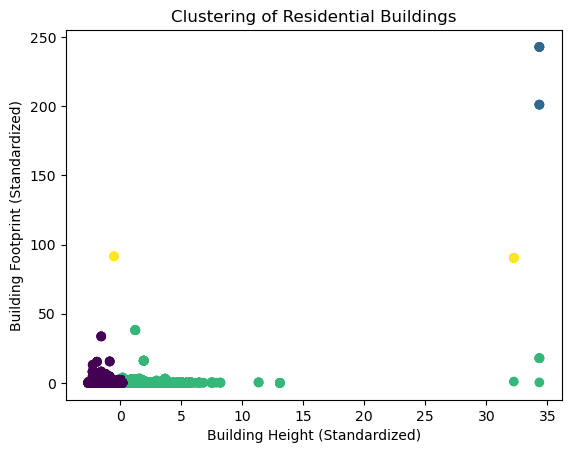

In [4]:
## labelling buiding by their types using K-Mean for clustering them to SFH, TH, MFH, and AB 

# Read data source
df = gpd.read_file(os.path.join(upath, r'shapefile/Barcelona/Barcelona_building_shared-wall_energy_certificates.sqlite')).to_crs('EPSG:3857').reset_index(drop=True)

# Calculate footprint area
df['footprint'] = df['geometry'].area

# Keep only relevant columns (height, footprint)
data = df[['height', 'footprint']]

# Remove rows with NaN values from both the DataFrame and data_values
df_cleaned = data.dropna().reset_index(drop=True)

# Convert to numpy array for easier processing
data_values = df_cleaned.values

# Normalize the data using StandardScaler
scaler = StandardScaler()
data_normalized = scaler.fit_transform(data_values)

# Apply K-Means clustering
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
labels = kmeans.fit_predict(data_normalized)

# Determine labels for clusters
# Get centroids from the fitted KMeans object
centroids = kmeans.cluster_centers_

# Reverse the standardization for easier interpretation
# Bring the centroids back to original scale
original_centroids = scaler.inverse_transform(centroids)

# Analyze centroids to decide labels (SFH, RH, MFH, AB)
# Sort clusters based on height and footprint to decide labels
cluster_info = [(i, centroid[0], centroid[1]) for i, centroid in enumerate(original_centroids)]
# Sorting based on height first, then footprint
cluster_info_sorted = sorted(cluster_info, key=lambda x: (x[1], x[2]))

# Assign labels based on sorted order
labels_mapping = {}
labels_order = ["SFH", "RH", "MFH", "AB"]

for index, label in enumerate(labels_order):
    cluster_id = cluster_info_sorted[index][0]
    labels_mapping[cluster_id] = label

# Assign labels to the cleaned DataFrame
df_cleaned['building_type'] = [labels_mapping[label] for label in labels]

# Replace "RH" with "TH" in building_type column
df_cleaned['building_type'] = df_cleaned['building_type'].replace("RH", "TH")

# Merge the cleaned DataFrame back with the original DataFrame
# This way, we retain the information of the buildings that were removed due to NaN
df = df.dropna().reset_index(drop=True)
df['building_type'] = df_cleaned['building_type']

# Check the output
print(df[['height', 'footprint', 'building_type']].head())

# Save the file
df.to_file(os.path.join(upath,r'shapefile/Barcelona/Barcelona_building_shared-wall_energy_certificates_Building_type.sqlite'), driver='SQLite')

# Visualize the results
plt.scatter(data_normalized[:, 0], data_normalized[:, 1], c=labels, cmap='viridis')
plt.xlabel('Building Height (Standardized)')
plt.ylabel('Building Footprint (Standardized)')
plt.title('Clustering of Residential Buildings')
plt.show()


In [9]:
def QH_calc(read_file, write_file):
    
    # Extracting parts of TABULA spreadsheet
    buil_set = pd.read_excel(os.path.join(upath, 'tabula-episcope', 'subset_TABULA.xlsx'))
    sys_set = pd.read_excel(os.path.join(upath, 'tabula-episcope', 'TABULA_sys_set_ES.xlsx'))
    
    # Removing rows that don't represent a country 
    buil_set = buil_set[buil_set['Code_Country'].notna()]
    buil_set = buil_set[buil_set['Description_BuildingVariant'].notna()]
    buil_set = buil_set[buil_set['Code_Country'] != 'XX']

    # Creating a multiindex
    buil_set.set_index(['Code_Country', 'Code_DataType_Building', 'Name_ClimateRegion', 
                        'Description_BuildingVariant', 'Code_BuildingSizeClass', 
                        'Year1_Building', 'Year2_Building'], inplace=True)

    buil_set = buil_set.sort_index(level=[0, 1, 2, 3, 4])

    # Creating a multiindex for system set
    sys_set.set_index(['Code_BuildingVariant'], inplace=True)
    sys_set = sys_set.sort_index(level=[0])

    # Reading the generated shapefile containing building info   
    bolig = gpd.read_file(read_file).to_crs('EPSG:3857').reset_index(drop=True)

    # Filtering out buildings without age attribute
    bolig = bolig[(bolig['age'].notna()) & (bolig['type_sourc'] == '1_residential')]

    # Define constants
    CO = 'ES'
    Typo = 'ReEx'
    Cl = 'Mediterranean'
    COND_dic = {
        1: ['Existing condition'],
        2: ['Level 1 of improvements'],
        3: ['Level 2 of improvements']
    }
        # Looping through building energy performance levels
    for c in [1]:
        for YY, VV in year_vv_dict.items():
            for BRA in [1]:
                for WR in [1]:
                    print(YY, '--', BRA, '--', WR)
                    
                    for index, row in bolig.iterrows():
                        
                        # Check if the 'year' in the row matches YY
                        if row['year'] != YY:
                            # Skip to the next row if year doesn't match
                            continue

                        B_type = row['bolig_type'] #bolig_type
                        
                        Y = row['age']
                        
                        # Creating a multiindex element
                        i = None
                        for a in buil_set.loc[(CO, Typo, Cl, COND_dic[c], B_type)].index:
                            if a[-2] <= Y <= a[-1]:
                                y0, y1 = a[-2], a[-1]
                                i = (CO, Typo, Cl, COND_dic[c], B_type, y0, y1)
                                break
                        
                        if i is None:
                            continue  # Skip if no matching index found
                        
                        try:
                            if 0 <= Y <= 1955:
                                sys_i = f"{CO}.ME.{B_type}.01.Gen.{Typo}.001.00{c}"
                            elif 1956 <= Y <= 1970:
                                sys_i = f"{CO}.ME.{B_type}.02.Gen.{Typo}.001.00{c}"
                            elif 1971 <= Y <= 1980:
                                sys_i = f"{CO}.ME.{B_type}.03.Gen.{Typo}.001.00{c}"
                            elif 1981 <= Y <= 1990:
                                sys_i = f"{CO}.ME.{B_type}.04.Gen.{Typo}.001.00{c}"
                            elif 1991 <= Y <= 2000:
                                sys_i = f"{CO}.ME.{B_type}.05.Gen.{Typo}.001.00{c}"
                            elif 2001 <= Y <= 2010:
                                sys_i = f"{CO}.ME.{B_type}.06.Gen.{Typo}.001.00{c}"
                            elif 2011 <= Y <= 9999:
                                sys_i = f"{CO}.ME.{B_type}.07.Gen.{Typo}.001.00{c}"
                            else:
                                raise ValueError("Unexpected value of Y:", Y)
                        except Exception as e:
                            print("Error:", e)
                            continue  # Skip to next iteration

                        # Estimated air-conditioned area
                        A_C_est = BRA * row['geometry'].area
                        
                        # print("A_C_est: ", A_C_est)

                        # Estimated areas
                        A_roof_est = BRA * row['geometry'].area
                        A_floor_est = BRA * row['geometry'].area
                        A_wall_est = WR * ((row.geometry.length * row['height_dem'] - row['shared_wall']) * (1 - 0.13))
                        A_window_est = WR * ((row.geometry.length * row['height_dem'] - row['shared_wall']) * 0.13)
                        A_door_est = 0

                        # Heat transfer coefficients
                        Htr_roof = buil_set.loc[idx[i], 'U_Roof_1'].values * A_roof_est * buil_set.loc[idx[i], 'b_Transmission_Roof_1'].values
                        Htr_floor = buil_set.loc[idx[i], 'U_Floor_1'].values * A_floor_est * buil_set.loc[idx[i], 'b_Transmission_Floor_1'].values
                        Htr_wall = buil_set.loc[idx[i], 'U_Wall_1'].values * A_wall_est * buil_set.loc[idx[i], 'b_Transmission_Wall_1'].values
                        Htr_window = buil_set.loc[idx[i], 'U_Window_1'].values * A_window_est
                        Htr_door = buil_set.loc[idx[i], 'U_Door_1'].values * A_door_est
                        Htr_tb = buil_set.loc[idx[i], 'delta_U_ThermalBridging_Original'].values * (A_roof_est + A_floor_est + A_wall_est + A_window_est + A_door_est)

                        Htr = Htr_roof + Htr_floor + Htr_wall + Htr_window + Htr_door + Htr_tb
                        
                        # print("Htr: ", Htr)

                        # Heat transfer by ventilation
                        Cp_air = 0.34
                        Hve = Cp_air * (buil_set.loc[idx[i], 'n_air_use'].values + buil_set.loc[idx[i], 'n_air_infiltration'].values) * A_C_est * buil_set.loc[idx[i], 'h_room'].values

                        # Internal temperature
                        if buil_set.loc[idx[i],'theta_i'].values >= 0:
                            int_tmp = buil_set.loc[idx[i], 'theta_i']
                        else:
                            int_tmp = buil_set.loc[idx[i], 'theta_i_htr1'].values + (Htr - 1) / 3 * (buil_set.loc[idx[i], 'theta_i_htr4'].values - buil_set.loc[idx[i], 'theta_i_htr1'].values)

                        tmp = (int_tmp - buil_set.loc[idx[i], 'Theta_e'].values) * VV

#                         # Ensure Htr and A_C_est are not zero or NaN
#                         if A_C_est is None or A_C_est == 0 or np.isnan(A_C_est):
#                             Fred = np.nan
#                         elif Htr is None or Htr == 0 or np.isnan(Htr):
#                             Fred = np.nan
#                         else:
#                             # Temperature reduction factor
#                             if Htr / A_C_est <= 1:
#                                 Fred = min(
#                                     buil_set.loc[idx[i], 'F_red_htr1'].values + 
#                                     (1 - (Htr / A_C_est)) / 0.5 * 
#                                     (1 - buil_set.loc[idx[i], 'F_red_htr1'].values), 1
#                                 )
#                             elif Htr / A_C_est >= 4:
#                                 Fred = buil_set.loc[idx[i], 'F_red_htr4'].values
#                             else:
#                                 Fred = (
#                                     buil_set.loc[idx[i], 'F_red_htr1'].values +
#                                     (Htr / A_C_est - 1) * 
#                                     (buil_set.loc[idx[i], 'F_red_htr4'].values - buil_set.loc[idx[i], 'F_red_htr1'].values) / 3
#                                 )

#                         # Ensure Hve is not zero or NaN before computing aH
#                         if Htr + Hve > 0:
#                             aH = 0.8 + ((buil_set.loc[idx[i], 'c_m'].values * A_C_est / (Htr + Hve)) / 30)
#                         else:
#                             aH = np.nan  # Handle invalid cases gracefully
                        
                        
                        # Temperature reduction factor
                        if Htr / A_C_est <= 1:
                            Fred = min(buil_set.loc[idx[i], 'F_red_htr1'].values + (1 - (Htr / A_C_est)) / 0.5 * (1 - buil_set.loc[idx[i], 'F_red_htr1'].values), 1)
                        elif Htr / A_C_est >= 4:
                            Fred = buil_set.loc[idx[i], 'F_red_htr4']
                        else:
                            Fred = buil_set.loc[idx[i], 'F_red_htr1'].values + (Htr / A_C_est - 1) * (buil_set.loc[idx[i], 'F_red_htr4'].values - buil_set.loc[idx[i], 'F_red_htr1'].values) / 3

                        Qht = (Htr + Hve) * Fred * (tmp * 0.024)

                        # Solar heat load
                        Qsol = 0
                        for w in ['Hor', 'East', 'South', 'West', 'North']:
                            if w == 'Hor':
                                Qsol += buil_set.loc[idx[i], 'F_sh_hor'].values * (1 - buil_set.loc[idx[i], 'F_f'].values) * buil_set.loc[idx[i], 'F_w'].values * buil_set.loc[idx[i], 'g_gl_n_Window_1'].values * 0 * buil_set.loc[idx[i], f'I_Sol_{w}'].values
                            else:
                                Qsol += buil_set.loc[idx[i], 'F_sh_vert'].values * (1 - buil_set.loc[idx[i], 'F_f'].values) * buil_set.loc[idx[i], 'F_w'].values * buil_set.loc[idx[i], 'g_gl_n_Window_1'].values * (A_window_est * 0.25) * buil_set.loc[idx[i], f'I_Sol_{w}'].values

                        # Internal heat source
                        Qint = 0.024 * buil_set.loc[idx[i], 'phi_int'].values * VV * A_C_est

                        # # Check if Htr + Hve is valid
                        # if Htr is None or Hve is None or np.isnan(Htr) or np.isnan(Hve) or (Htr + Hve) == 0:
                        #     aH = np.nan  # Assign NaN if the denominator is invalid
                        # else:
                        #     aH = 0.8 + ((buil_set.loc[idx[i], 'c_m'].values * A_C_est / (Htr + Hve)) / 30)

                        # Constant parameter aH
                        aH = 0.8 + ((buil_set.loc[idx[i], 'c_m'].values * A_C_est / (Htr + Hve)) / 30)

                        # Heat balance ratio
                        lamd = (Qsol + Qint) / Qht

                        # Gain utilization factor for heating
                        mu = (1 - lamd ** aH) / (1 - lamd ** (aH + 1))

                        # Energy needed for heating
                        QH = Qht - mu * (Qsol + Qint)

                        # bolig.at[index, f'QH_(kWh/a).00{c}_{BRA}_{WR}{YY}'] = QH.iloc[0]
                        bolig.at[index, f'QH_(kWh/m2a).00{c}_{BRA}_{WR}{YY}'] = QH.iloc[0] / A_C_est

    return bolig.to_file(write_file, driver='SQLite')

In [8]:
%%time
QH_calc(os.path.join(upath,r'shapefile/Barcelona/Barcelona_building_shared-wall_energy_certificates_OSM-build-type_v2.sqlite'),
        os.path.join(upath,r'shapefile/Barcelona/Barcelona_building-QH_BRA_share_HDD+as-built_W2W-13%_as_built_W-KM-BT_13degree_OSM_v4.sqlite'))

2013 -- 1 -- 1
2014 -- 1 -- 1
2015 -- 1 -- 1
2016 -- 1 -- 1
2017 -- 1 -- 1
2018 -- 1 -- 1
2019 -- 1 -- 1
2020 -- 1 -- 1
2021 -- 1 -- 1
2022 -- 1 -- 1
2023 -- 1 -- 1
CPU times: user 49min 1s, sys: 2.6 s, total: 49min 4s
Wall time: 49min 18s


In [ ]:
# # Divide by a factor to scale down the timestamp to milliseconds

# SW_Barca_EC = test

# # Drop rows where DATA_ENTRA has NaN values
# SW_Barca_EC = SW_Barca_EC.dropna(subset=['data_entra'])

# SW_Barca_EC['scaled_data_entra'] = SW_Barca_EC['data_entra'] / 1e6  # Scaling to milliseconds

# # Convert the scaled_data_entra to string, then to datetime using the format 'YYYYMMDD'
# SW_Barca_EC['date_EC'] = pd.to_datetime(SW_Barca_EC['scaled_data_entra'].astype(int).astype(str), format='%Y%m%d', errors='coerce')

# # Extract the year from the datetime
# SW_Barca_EC['year'] = SW_Barca_EC['date_EC'].dt.year

# # Check the first few rows
# print(SW_Barca_EC[['data_entra', 'scaled_data_entra', 'date_EC', 'year']].head())

/home/babakebrahimi/.local/lib/python3.9/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


     data_entra  scaled_data_entra    date_EC  year
0  2.016080e+13         20160805.0 2016-08-05  2016
1  2.015011e+13         20150113.0 2015-01-13  2015
2  2.023012e+13         20230123.0 2023-01-23  2023
3  2.019043e+13         20190426.0 2019-04-26  2019
4  2.014060e+13         20140603.0 2014-06-03  2014


/home/babakebrahimi/.local/lib/python3.9/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [12]:
def QH_calc(read_file, write_file):
    
    # Extracting parts of TABULA spreadsheet
    buil_set = pd.read_excel(os.path.join(upath, 'tabula-episcope', 'subset_TABULA.xlsx'))
    sys_set = pd.read_excel(os.path.join(upath, 'tabula-episcope', 'TABULA_sys_set_ES.xlsx'))
    
    # Removing rows that don't represent a country 
    buil_set = buil_set[buil_set['Code_Country'].notna()]
    buil_set = buil_set[buil_set['Description_BuildingVariant'].notna()]
    buil_set = buil_set[buil_set['Code_Country'] != 'XX']

    # Creating a multiindex
    buil_set.set_index(['Code_Country', 'Code_DataType_Building', 'Name_ClimateRegion', 
                        'Description_BuildingVariant', 'Code_BuildingSizeClass', 
                        'Year1_Building', 'Year2_Building'], inplace=True)

    buil_set = buil_set.sort_index(level=[0, 1, 2, 3, 4])

    # Creating a multiindex for system set
    sys_set.set_index(['Code_BuildingVariant'], inplace=True)
    sys_set = sys_set.sort_index(level=[0])

    # Reading the generated shapefile containing building info   
    bolig = gpd.read_file(read_file).to_crs('EPSG:3857').reset_index(drop=True)

    # Filtering out buildings without age attribute
    bolig = bolig[(bolig['age'].notna()) & (bolig['type_sourc'] == '1_residential')]

    # Define constants
    CO = 'ES'
    Typo = 'ReEx'
    Cl = 'Mediterranean'
    COND_dic = {
        1: ['Existing condition'],
        2: ['Level 1 of improvements'],
        3: ['Level 2 of improvements']
    }
        # Looping through building energy performance levels
    for c in [2]:
        for YY, VV in year_vv_dict.items():
            for BRA in [1]:
                for WR in [1]:
                    print(YY, '--', BRA, '--', WR)
                    
                    for index, row in bolig.iterrows():
                        
                        # Check if the 'year' in the row matches YY
                        if row['year'] != YY:
                            # Skip to the next row if year doesn't match
                            continue
                            
                        B_type = row['bolig_type']
                        
                        Y = row['age']
                        
                        # Creating a multiindex element
                        i = None
                        for a in buil_set.loc[(CO, Typo, Cl, COND_dic[c], B_type)].index:
                            if a[-2] <= Y <= a[-1]:
                                y0, y1 = a[-2], a[-1]
                                i = (CO, Typo, Cl, COND_dic[c], B_type, y0, y1)
                                break
                        
                        if i is None:
                            continue  # Skip if no matching index found
                        
                        try:
                            if 0 <= Y <= 1955:
                                sys_i = f"{CO}.ME.{B_type}.01.Gen.{Typo}.001.00{c}"
                            elif 1956 <= Y <= 1970:
                                sys_i = f"{CO}.ME.{B_type}.02.Gen.{Typo}.001.00{c}"
                            elif 1971 <= Y <= 1980:
                                sys_i = f"{CO}.ME.{B_type}.03.Gen.{Typo}.001.00{c}"
                            elif 1981 <= Y <= 1990:
                                sys_i = f"{CO}.ME.{B_type}.04.Gen.{Typo}.001.00{c}"
                            elif 1991 <= Y <= 2000:
                                sys_i = f"{CO}.ME.{B_type}.05.Gen.{Typo}.001.00{c}"
                            elif 2001 <= Y <= 2010:
                                sys_i = f"{CO}.ME.{B_type}.06.Gen.{Typo}.001.00{c}"
                            elif 2011 <= Y <= 9999:
                                sys_i = f"{CO}.ME.{B_type}.07.Gen.{Typo}.001.00{c}"
                            else:
                                raise ValueError("Unexpected value of Y:", Y)
                        except Exception as e:
                            print("Error:", e)
                            continue  # Skip to next iteration

                        # Estimated air-conditioned area
                        A_C_est = BRA * row['geometry'].area

                        # Estimated areas
                        A_roof_est = BRA * row['geometry'].area
                        A_floor_est = BRA * row['geometry'].area
                        A_wall_est = WR * ((row.geometry.length * row['height_dem'] - row['shared_wall']) * (1 - 0.13))
                        A_window_est = WR * ((row.geometry.length * row['height_dem'] - row['shared_wall']) * 0.13)
                        A_door_est = 0

                        # Heat transfer coefficients
                        Htr_roof = buil_set.loc[idx[i], 'U_Roof_1'].values * A_roof_est * buil_set.loc[idx[i], 'b_Transmission_Roof_1'].values
                        Htr_floor = buil_set.loc[idx[i], 'U_Floor_1'].values * A_floor_est * buil_set.loc[idx[i], 'b_Transmission_Floor_1'].values
                        Htr_wall = buil_set.loc[idx[i], 'U_Wall_1'].values * A_wall_est * buil_set.loc[idx[i], 'b_Transmission_Wall_1'].values
                        Htr_window = buil_set.loc[idx[i], 'U_Window_1'].values * A_window_est
                        Htr_door = buil_set.loc[idx[i], 'U_Door_1'].values * A_door_est
                        Htr_tb = buil_set.loc[idx[i], 'delta_U_ThermalBridging_Original'].values * (A_roof_est + A_floor_est + A_wall_est + A_window_est + A_door_est)

                        Htr = Htr_roof + Htr_floor + Htr_wall + Htr_window + Htr_door + Htr_tb

                        # Heat transfer by ventilation
                        Cp_air = 0.34
                        Hve = Cp_air * (buil_set.loc[idx[i], 'n_air_use'].values + buil_set.loc[idx[i], 'n_air_infiltration'].values) * A_C_est * buil_set.loc[idx[i], 'h_room'].values

                        # Internal temperature
                        if buil_set.loc[idx[i],'theta_i'].values >= 0:
                            int_tmp = buil_set.loc[idx[i], 'theta_i']
                        else:
                            int_tmp = buil_set.loc[idx[i], 'theta_i_htr1'].values + (Htr - 1) / 3 * (buil_set.loc[idx[i], 'theta_i_htr4'].values - buil_set.loc[idx[i], 'theta_i_htr1'].values)

                        tmp = (int_tmp - buil_set.loc[idx[i], 'Theta_e'].values) * VV

                        # Ensure Htr and A_C_est are not zero or NaN
                        if A_C_est is None or A_C_est == 0 or np.isnan(A_C_est):
                            Fred = np.nan
                        elif Htr is None or Htr == 0 or np.isnan(Htr):
                            Fred = np.nan
                        else:
                            # Temperature reduction factor
                            if Htr / A_C_est <= 1:
                                Fred = min(
                                    buil_set.loc[idx[i], 'F_red_htr1'].values + 
                                    (1 - (Htr / A_C_est)) / 0.5 * 
                                    (1 - buil_set.loc[idx[i], 'F_red_htr1'].values), 1
                                )
                            elif Htr / A_C_est >= 4:
                                Fred = buil_set.loc[idx[i], 'F_red_htr4'].values
                            else:
                                Fred = (
                                    buil_set.loc[idx[i], 'F_red_htr1'].values +
                                    (Htr / A_C_est - 1) * 
                                    (buil_set.loc[idx[i], 'F_red_htr4'].values - buil_set.loc[idx[i], 'F_red_htr1'].values) / 3
                                )

                        # Ensure Hve is not zero or NaN before computing aH
                        if Htr + Hve > 0:
                            aH = 0.8 + ((buil_set.loc[idx[i], 'c_m'].values * A_C_est / (Htr + Hve)) / 30)
                        else:
                            aH = np.nan  # Handle invalid cases gracefully
                        
                        # # Temperature reduction factor
                        # if Htr / A_C_est <= 1:
                        #     Fred = min(buil_set.loc[idx[i], 'F_red_htr1'].values + (1 - (Htr / A_C_est)) / 0.5 * (1 - buil_set.loc[idx[i], 'F_red_htr1'].values), 1)
                        # elif Htr / A_C_est >= 4:
                        #     Fred = buil_set.loc[idx[i], 'F_red_htr4']
                        # else:
                        #     Fred = buil_set.loc[idx[i], 'F_red_htr1'].values + (Htr / A_C_est - 1) * (buil_set.loc[idx[i], 'F_red_htr4'].values - buil_set.loc[idx[i], 'F_red_htr1'].values) / 3

                        Qht = (Htr + Hve) * Fred * (tmp * 0.024)

                        # Solar heat load
                        Qsol = 0
                        for w in ['Hor', 'East', 'South', 'West', 'North']:
                            if w == 'Hor':
                                Qsol += buil_set.loc[idx[i], 'F_sh_hor'].values * (1 - buil_set.loc[idx[i], 'F_f'].values) * buil_set.loc[idx[i], 'F_w'].values * buil_set.loc[idx[i], 'g_gl_n_Window_1'].values * 0 * buil_set.loc[idx[i], f'I_Sol_{w}'].values
                            else:
                                Qsol += buil_set.loc[idx[i], 'F_sh_vert'].values * (1 - buil_set.loc[idx[i], 'F_f'].values) * buil_set.loc[idx[i], 'F_w'].values * buil_set.loc[idx[i], 'g_gl_n_Window_1'].values * (A_window_est * 0.25) * buil_set.loc[idx[i], f'I_Sol_{w}'].values

                        # Internal heat source
                        Qint = 0.024 * buil_set.loc[idx[i], 'phi_int'].values * VV * A_C_est

                        # Check if Htr + Hve is valid
                        if Htr is None or Hve is None or np.isnan(Htr) or np.isnan(Hve) or (Htr + Hve) == 0:
                            aH = np.nan  # Assign NaN if the denominator is invalid
                        else:
                            aH = 0.8 + ((buil_set.loc[idx[i], 'c_m'].values * A_C_est / (Htr + Hve)) / 30)
                            
                        # Constant parameter aH
                        # aH = 0.8 + ((buil_set.loc[idx[i], 'c_m'].values * A_C_est / (Htr + Hve)) / 30)

                        # Heat balance ratio
                        lamd = (Qsol + Qint) / Qht

                        # Gain utilization factor for heating
                        mu = (1 - lamd ** aH) / (1 - lamd ** (aH + 1))

                        # Energy needed for heating
                        QH = Qht - mu * (Qsol + Qint)
                        
                        # print('Qht =', Qht.iloc[0])
                        # print('QH =', QH.iloc[0] / A_C_est)

                        bolig.at[index, f'QH_(kWh/a).00{c}_{BRA}_{WR}{YY}'] = QH.iloc[0]
                        bolig.at[index, f'QH_(kWh/m2a).00{c}_{BRA}_{WR}{YY}'] = QH.iloc[0] / A_C_est

    return bolig.to_file(write_file, driver='SQLite')

In [13]:
%%time
QH_calc(os.path.join(upath,r'shapefile/Barcelona/Barcelona_building-QH_BRA_share_HDD+refurbish_W2W-13%_as_built_W-KM-BT_13degree_OSM_v4_DEM.sqlite'),
        os.path.join(upath,r'shapefile/Barcelona/Barcelona_building-QH_BRA_share_HDD+refurbish_W2W-13%_renovated_W-KM-BT_13degree_OSM_v5_DEM.sqlite'))

2013 -- 1 -- 1
2014 -- 1 -- 1
2015 -- 1 -- 1
2016 -- 1 -- 1
2017 -- 1 -- 1
2018 -- 1 -- 1
2019 -- 1 -- 1
2020 -- 1 -- 1
2021 -- 1 -- 1
2022 -- 1 -- 1
2023 -- 1 -- 1
CPU times: user 49min 3s, sys: 3.22 s, total: 49min 7s
Wall time: 49min 18s


In [16]:
# def QH_calc(read_file, write_file):
    
#     # Extracting parts of TABULA spreadsheet
#     buil_set = pd.read_excel(os.path.join(upath, 'tabula-episcope', 'subset_TABULA.xlsx'))
#     sys_set = pd.read_excel(os.path.join(upath, 'tabula-episcope', 'TABULA_sys_set_ES.xlsx'))
    
#     # Removing rows that don't represent a country 
#     buil_set = buil_set[buil_set['Code_Country'].notna()]
#     buil_set = buil_set[buil_set['Description_BuildingVariant'].notna()]
#     buil_set = buil_set[buil_set['Code_Country'] != 'XX']

#     # Creating a multiindex
#     buil_set.set_index(['Code_Country', 'Code_DataType_Building', 'Name_ClimateRegion', 
#                         'Description_BuildingVariant', 'Code_BuildingSizeClass', 
#                         'Year1_Building', 'Year2_Building'], inplace=True)

#     buil_set = buil_set.sort_index(level=[0, 1, 2, 3, 4])

#     # Creating a multiindex for system set
#     sys_set.set_index(['Code_BuildingVariant'], inplace=True)
#     sys_set = sys_set.sort_index(level=[0])

#     # Reading the generated shapefile containing building info   
#     bolig = gpd.read_file(read_file).to_crs('EPSG:3857').reset_index(drop=True)

#     # Filtering out buildings without age attribute
#     bolig = bolig[(bolig['age'].notna()) & (bolig['type_sourc'] == '1_residential')]

#     # Define constants
#     CO = 'ES'
#     Typo = 'ReEx'
#     Cl = 'Mediterranean'
#     COND_dic = {
#         1: ['Existing condition'],
#         2: ['Level 1 of improvements'],
#         3: ['Level 2 of improvements']
#     }
#         # Looping through building energy performance levels
#     for c in [1]:
    
#         for BRA in [1, 0.8]:
#             for WR in [1, 0.7]:
#                 print(BRA, '--', WR)

#                 for index, row in bolig.iterrows():
# #                         B_type = None
# #                         for i, j in bygg_dic.items():
# #                             if int(row['BYGGTYPEKO']) in j:
# #                                 B_type = i
# #                                 break

# #                         if B_type is None:
# #                             continue  # Skip if no building type matches
#                     B_type = 'AB'

#                     Y = row['age']

#                     # Creating a multiindex element
#                     i = None
#                     for a in buil_set.loc[(CO, Typo, Cl, COND_dic[c], B_type)].index:
#                         if a[-2] <= Y <= a[-1]:
#                             y0, y1 = a[-2], a[-1]
#                             i = (CO, Typo, Cl, COND_dic[c], B_type, y0, y1)
#                             break

#                     if i is None:
#                         continue  # Skip if no matching index found

#                     try:
#                         if 0 <= Y <= 1955:
#                             sys_i = f"{CO}.ME.{B_type}.01.Gen.{Typo}.001.00{c}"
#                         elif 1956 <= Y <= 1970:
#                             sys_i = f"{CO}.ME.{B_type}.02.Gen.{Typo}.001.00{c}"
#                         elif 1971 <= Y <= 1980:
#                             sys_i = f"{CO}.ME.{B_type}.03.Gen.{Typo}.001.00{c}"
#                         elif 1981 <= Y <= 1990:
#                             sys_i = f"{CO}.ME.{B_type}.04.Gen.{Typo}.001.00{c}"
#                         elif 1991 <= Y <= 2000:
#                             sys_i = f"{CO}.ME.{B_type}.05.Gen.{Typo}.001.00{c}"
#                         elif 2001 <= Y <= 2010:
#                             sys_i = f"{CO}.ME.{B_type}.06.Gen.{Typo}.001.00{c}"
#                         elif 2011 <= Y <= 9999:
#                             sys_i = f"{CO}.ME.{B_type}.07.Gen.{Typo}.001.00{c}"
#                         else:
#                             raise ValueError("Unexpected value of Y:", Y)
#                     except Exception as e:
#                         print("Error:", e)
#                         continue  # Skip to next iteration

#                     # Estimated air-conditioned area
#                     A_C_est = BRA * row['geometry'].area

#                     # Estimated areas
#                     A_roof_est = BRA * row['geometry'].area
#                     A_floor_est = BRA * row['geometry'].area
#                     A_wall_est = WR * ((row.geometry.length * row['height'] - row['shared_wall']) * (1 - 0.13))
#                     A_window_est = WR * ((row.geometry.length * row['height'] - row['shared_wall']) * 0.13)
#                     A_door_est = 0

#                     # Heat transfer coefficients
#                     Htr_roof = buil_set.loc[idx[i], 'U_Roof_1'].values * A_roof_est * buil_set.loc[idx[i], 'b_Transmission_Roof_1'].values
#                     Htr_floor = buil_set.loc[idx[i], 'U_Floor_1'].values * A_floor_est * buil_set.loc[idx[i], 'b_Transmission_Floor_1'].values
#                     Htr_wall = buil_set.loc[idx[i], 'U_Wall_1'].values * A_wall_est * buil_set.loc[idx[i], 'b_Transmission_Wall_1'].values
#                     Htr_window = buil_set.loc[idx[i], 'U_Window_1'].values * A_window_est
#                     Htr_door = buil_set.loc[idx[i], 'U_Door_1'].values * A_door_est
#                     Htr_tb = buil_set.loc[idx[i], 'delta_U_ThermalBridging_Original'].values * (A_roof_est + A_floor_est + A_wall_est + A_window_est + A_door_est)

#                     Htr = Htr_roof + Htr_floor + Htr_wall + Htr_window + Htr_door + Htr_tb

#                     # Heat transfer by ventilation
#                     Cp_air = 0.34
#                     Hve = Cp_air * (buil_set.loc[idx[i], 'n_air_use'].values + buil_set.loc[idx[i], 'n_air_infiltration'].values) * A_C_est * buil_set.loc[idx[i], 'h_room'].values

#                     # Internal temperature
#                     if buil_set.loc[idx[i],'theta_i'].values >= 0:
#                         int_tmp = buil_set.loc[idx[i], 'theta_i']
#                     else:
#                         int_tmp = buil_set.loc[idx[i], 'theta_i_htr1'].values + (Htr - 1) / 3 * (buil_set.loc[idx[i], 'theta_i_htr4'].values - buil_set.loc[idx[i], 'theta_i_htr1'].values)

#                     tmp = (int_tmp - buil_set.loc[idx[i], 'Theta_e'].values) * 175 #buil_set.loc[idx[i],'HeatingDays'].values

#                     # Temperature reduction factor
#                     if Htr / A_C_est <= 1:
#                         Fred = min(buil_set.loc[idx[i], 'F_red_htr1'].values + (1 - (Htr / A_C_est)) / 0.5 * (1 - buil_set.loc[idx[i], 'F_red_htr1'].values), 1)
#                     elif Htr / A_C_est >= 4:
#                         Fred = buil_set.loc[idx[i], 'F_red_htr4']
#                     else:
#                         Fred = buil_set.loc[idx[i], 'F_red_htr1'].values + (Htr / A_C_est - 1) * (buil_set.loc[idx[i], 'F_red_htr4'].values - buil_set.loc[idx[i], 'F_red_htr1'].values) / 3

#                     Qht = (Htr + Hve) * Fred * (tmp * 0.024)
#                     print('Qht =', Qht.iloc[0])

#                     # Solar heat load
#                     Qsol = 0
#                     for w in ['Hor', 'East', 'South', 'West', 'North']:
#                         if w == 'Hor':
#                             Qsol += buil_set.loc[idx[i], 'F_sh_hor'].values * (1 - buil_set.loc[idx[i], 'F_f'].values) * buil_set.loc[idx[i], 'F_w'].values * buil_set.loc[idx[i], 'g_gl_n_Window_1'].values * 0 * buil_set.loc[idx[i], f'I_Sol_{w}'].values
#                         else:
#                             Qsol += buil_set.loc[idx[i], 'F_sh_vert'].values * (1 - buil_set.loc[idx[i], 'F_f'].values) * buil_set.loc[idx[i], 'F_w'].values * buil_set.loc[idx[i], 'g_gl_n_Window_1'].values * (A_window_est * 0.25) * buil_set.loc[idx[i], f'I_Sol_{w}'].values

#                     # Internal heat source
#                     Qint = 0.024 * buil_set.loc[idx[i], 'phi_int'].values * 175 * A_C_est # buil_set.loc[idx[i],'HeatingDays'].values * A_C_est

#                     # Constant parameter aH
#                     aH = 0.8 + ((buil_set.loc[idx[i], 'c_m'].values * A_C_est / (Htr + Hve)) / 30)

#                     # Heat balance ratio
#                     lamd = (Qsol + Qint) / Qht

#                     # Gain utilization factor for heating
#                     mu = (1 - lamd ** aH) / (1 - lamd ** (aH + 1))

#                     # Energy needed for heating
#                     QH = Qht - mu * (Qsol + Qint)
                    
#                     print('QH =', QH.iloc[0] / A_C_est)

#                     bolig.at[index, f'QH_(kWh/a).00{c}_{BRA}_{WR}'] = QH.iloc[0]
#                     bolig.at[index, f'QH_(kWh/m2a).00{c}_{BRA}_{WR}'] = QH.iloc[0] / A_C_est

#     return bolig.to_crs(epsg=4326).to_file(write_file, driver='SQLite')

In [ ]:
# %%time
# Shared_wall(os.path.join(upath,r'Barcelona/EUBUCCO/file/barca_build.shp'),
#             os.path.join(upath,r'shapefile/Barcelona/Barcelona_building_shared-wall.shp'))

/home/conda/fairicube/509ef1ea91778cd89e0732da937c672a0e4c27fd9e360fadaa9831b15c3fb15c-20230123-091006-736556-1-edc-2022.10-14/lib/python3.9/site-packages/shapely/set_operations.py:133: RuntimeWarning: invalid value encountered in intersection
  return lib.intersection(a, b, **kwargs)


In [8]:
# def QH_calc(read_file, write_file):
    
#     # Extracting parts of TABULA spreadsheet
#     buil_set = pd.read_excel(os.path.join(upath, 'tabula-episcope', 'subset_TABULA.xlsx'))
#     sys_set = pd.read_excel(os.path.join(upath, 'tabula-episcope', 'TABULA_sys_set_ES.xlsx'))
    
#     # Removing rows that don't represent a country 
#     buil_set = buil_set[buil_set['Code_Country'].notna()]
#     buil_set = buil_set[buil_set['Description_BuildingVariant'].notna()]
#     buil_set = buil_set[buil_set['Code_Country'] != 'XX']

#     # Creating a multiindex
#     buil_set.set_index(['Code_Country', 'Code_DataType_Building', 'Name_ClimateRegion', 
#                         'Description_BuildingVariant', 'Code_BuildingSizeClass', 
#                         'Year1_Building', 'Year2_Building'], inplace=True)

#     buil_set = buil_set.sort_index(level=[0, 1, 2, 3, 4])

#     # Creating a multiindex for system set
#     sys_set.set_index(['Code_BuildingVariant'], inplace=True)
#     sys_set = sys_set.sort_index(level=[0])

#     # Reading the generated shapefile containing building info   
#     bolig = gpd.read_file(read_file).to_crs('EPSG:3857').reset_index(drop=True)

#     # Filtering out buildings without age attribute
#     bolig = bolig[(bolig['age'].notna()) & (bolig['type_sourc'] == '1_residential')]

#     # Define constants
#     CO = 'ES'
#     Typo = 'ReEx'
#     Cl = 'Mediterranean'
#     COND_dic = {
#         1: ['Existing condition'],
#         2: ['Level 1 of improvements'],
#         3: ['Level 2 of improvements']
#     }
#         # Looping through building energy performance levels
#     for c in [2]:
    
#         for BRA in [1, 0.8]:
#             for WR in [1, 0.7]:
#                 print(BRA, '--', WR)

#                 for index, row in bolig.iterrows():
# #                         B_type = None
# #                         for i, j in bygg_dic.items():
# #                             if int(row['BYGGTYPEKO']) in j:
# #                                 B_type = i
# #                                 break

# #                         if B_type is None:
# #                             continue  # Skip if no building type matches
#                     B_type = 'AB'

#                     Y = row['age']

#                     # Creating a multiindex element
#                     i = None
#                     for a in buil_set.loc[(CO, Typo, Cl, COND_dic[c], B_type)].index:
#                         if a[-2] <= Y <= a[-1]:
#                             y0, y1 = a[-2], a[-1]
#                             i = (CO, Typo, Cl, COND_dic[c], B_type, y0, y1)
#                             break

#                     if i is None:
#                         continue  # Skip if no matching index found

#                     try:
#                         if 0 <= Y <= 1955:
#                             sys_i = f"{CO}.ME.{B_type}.01.Gen.{Typo}.001.00{c}"
#                         elif 1956 <= Y <= 1970:
#                             sys_i = f"{CO}.ME.{B_type}.02.Gen.{Typo}.001.00{c}"
#                         elif 1971 <= Y <= 1980:
#                             sys_i = f"{CO}.ME.{B_type}.03.Gen.{Typo}.001.00{c}"
#                         elif 1981 <= Y <= 1990:
#                             sys_i = f"{CO}.ME.{B_type}.04.Gen.{Typo}.001.00{c}"
#                         elif 1991 <= Y <= 2000:
#                             sys_i = f"{CO}.ME.{B_type}.05.Gen.{Typo}.001.00{c}"
#                         elif 2001 <= Y <= 2010:
#                             sys_i = f"{CO}.ME.{B_type}.06.Gen.{Typo}.001.00{c}"
#                         elif 2011 <= Y <= 9999:
#                             sys_i = f"{CO}.ME.{B_type}.07.Gen.{Typo}.001.00{c}"
#                         else:
#                             raise ValueError("Unexpected value of Y:", Y)
#                     except Exception as e:
#                         print("Error:", e)
#                         continue  # Skip to next iteration

#                     # Estimated air-conditioned area
#                     A_C_est = BRA * row['geometry'].area

#                     # Estimated areas
#                     A_roof_est = BRA * row['geometry'].area
#                     A_floor_est = BRA * row['geometry'].area
#                     A_wall_est = WR * ((row.geometry.length * row['height'] - row['shared_wall']) * (1 - 0.13))
#                     A_window_est = WR * ((row.geometry.length * row['height'] - row['shared_wall']) * 0.13)
#                     A_door_est = 0

#                     # Heat transfer coefficients
#                     Htr_roof = buil_set.loc[idx[i], 'U_Roof_1'].values * A_roof_est * buil_set.loc[idx[i], 'b_Transmission_Roof_1'].values
#                     Htr_floor = buil_set.loc[idx[i], 'U_Floor_1'].values * A_floor_est * buil_set.loc[idx[i], 'b_Transmission_Floor_1'].values
#                     Htr_wall = buil_set.loc[idx[i], 'U_Wall_1'].values * A_wall_est * buil_set.loc[idx[i], 'b_Transmission_Wall_1'].values
#                     Htr_window = buil_set.loc[idx[i], 'U_Window_1'].values * A_window_est
#                     Htr_door = buil_set.loc[idx[i], 'U_Door_1'].values * A_door_est
#                     Htr_tb = buil_set.loc[idx[i], 'delta_U_ThermalBridging_Original'].values * (A_roof_est + A_floor_est + A_wall_est + A_window_est + A_door_est)

#                     Htr = Htr_roof + Htr_floor + Htr_wall + Htr_window + Htr_door + Htr_tb

#                     # Heat transfer by ventilation
#                     Cp_air = 0.34
#                     Hve = Cp_air * (buil_set.loc[idx[i], 'n_air_use'].values + buil_set.loc[idx[i], 'n_air_infiltration'].values) * A_C_est * buil_set.loc[idx[i], 'h_room'].values

#                     # Internal temperature
#                     if buil_set.loc[idx[i],'theta_i'].values >= 0:
#                         int_tmp = buil_set.loc[idx[i], 'theta_i']
#                     else:
#                         int_tmp = buil_set.loc[idx[i], 'theta_i_htr1'].values + (Htr - 1) / 3 * (buil_set.loc[idx[i], 'theta_i_htr4'].values - buil_set.loc[idx[i], 'theta_i_htr1'].values)

#                     tmp = (int_tmp - buil_set.loc[idx[i], 'Theta_e'].values) * buil_set.loc[idx[i],'HeatingDays'].values

#                     # Temperature reduction factor
#                     if Htr / A_C_est <= 1:
#                         Fred = min(buil_set.loc[idx[i], 'F_red_htr1'].values + (1 - (Htr / A_C_est)) / 0.5 * (1 - buil_set.loc[idx[i], 'F_red_htr1'].values), 1)
#                     elif Htr / A_C_est >= 4:
#                         Fred = buil_set.loc[idx[i], 'F_red_htr4']
#                     else:
#                         Fred = buil_set.loc[idx[i], 'F_red_htr1'].values + (Htr / A_C_est - 1) * (buil_set.loc[idx[i], 'F_red_htr4'].values - buil_set.loc[idx[i], 'F_red_htr1'].values) / 3

#                     Qht = (Htr + Hve) * Fred * (tmp * 0.024)

#                     # Solar heat load
#                     Qsol = 0
#                     for w in ['Hor', 'East', 'South', 'West', 'North']:
#                         if w == 'Hor':
#                             Qsol += buil_set.loc[idx[i], 'F_sh_hor'].values * (1 - buil_set.loc[idx[i], 'F_f'].values) * buil_set.loc[idx[i], 'F_w'].values * buil_set.loc[idx[i], 'g_gl_n_Window_1'].values * 0 * buil_set.loc[idx[i], f'I_Sol_{w}'].values
#                         else:
#                             Qsol += buil_set.loc[idx[i], 'F_sh_vert'].values * (1 - buil_set.loc[idx[i], 'F_f'].values) * buil_set.loc[idx[i], 'F_w'].values * buil_set.loc[idx[i], 'g_gl_n_Window_1'].values * (A_window_est * 0.25) * buil_set.loc[idx[i], f'I_Sol_{w}'].values

#                     # Internal heat source
#                     Qint = 0.024 * buil_set.loc[idx[i], 'phi_int'].values * buil_set.loc[idx[i],'HeatingDays'].values * A_C_est

#                     # Constant parameter aH
#                     aH = 0.8 + ((buil_set.loc[idx[i], 'c_m'].values * A_C_est / (Htr + Hve)) / 30)

#                     # Heat balance ratio
#                     lamd = (Qsol + Qint) / Qht

#                     # Gain utilization factor for heating
#                     mu = (1 - lamd ** aH) / (1 - lamd ** (aH + 1))

#                     # Energy needed for heating
#                     QH = Qht - mu * (Qsol + Qint)

#                     bolig.at[index, f'QH_(kWh/a).00{c}_{BRA}_{WR}'] = QH.iloc[0]
#                     bolig.at[index, f'QH_(kWh/m2a).00{c}_{BRA}_{WR}'] = QH.iloc[0] / A_C_est

#     return bolig.to_crs(epsg=4326).to_file(write_file, driver='SQLite')

In [9]:
# %%time
# QH_calc(os.path.join(upath,r'shapefile/Barcelona/Barcelona_building_shared-wall.sqlite'),
#         os.path.join(upath,r'shapefile/Barcelona/Barcelona_building-QH_BRA_share_HDD+refurbish_W2W-13%_renovated.sqlite'))

1 -- 1
1 -- 0.7
0.8 -- 1
0.8 -- 0.7
CPU times: user 2h 36min 35s, sys: 4.74 s, total: 2h 36min 40s
Wall time: 2h 36min 45s


In [37]:
# Read as-built and renovated data

# Function to remove ".001" and ".002" from column names
def remove_suffixes(column_name):
    return column_name.replace('.001', '').replace('.002', '')

as_built = gpd.read_file(os.path.join(upath,r'shapefile/Barcelona/Barcelona_building-QH_BRA_share_HDD+refurbish_W2W-13%_as_built_W-KM-BT_13degree_OSM_v4_DEM.sqlite'))

# # Update column names in the DataFrame
as_built.columns = [remove_suffixes(col) for col in as_built.columns]

renovated = gpd.read_file(os.path.join(upath,r'shapefile/Barcelona/Barcelona_building-QH_BRA_share_HDD+refurbish_W2W-13%_renovated_W-KM-BT_13degree_OSM_v5_DEM.sqlite'))

# Update column names in the DataFrame
renovated.columns = [remove_suffixes(col) for col in renovated.columns]


<AxesSubplot: >

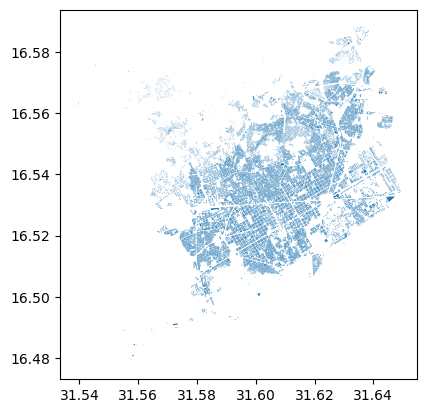

In [48]:
# renovated.plot()#.set_crs('EPSG:25831', allow_override=True).to_crs('EPSG:4326').plot()

In [16]:
%%time
Shared_wall(os.path.join(upath,r'Barcelona/EUBUCCO/file/barca_build.sqlite'),
            os.path.join(upath,r'shapefile/Barcelona/Barcelona_building_shared-wall.sqlite'))

Progress: 5%
Progress: 10%
Progress: 15%
Progress: 20%
Progress: 25%
Progress: 30%
Progress: 35%
Progress: 40%
Progress: 45%
Progress: 50%
Progress: 55%
Progress: 60%
Progress: 65%
Progress: 70%
Progress: 75%
Progress: 80%
Progress: 85%
Progress: 90%
Progress: 95%
Progress: 100% - Completed
CPU times: user 37min 19s, sys: 1.19 s, total: 37min 20s
Wall time: 37min 25s


In [4]:
### Read part of a geofile ###
# Load the source geofile from which you want to extract the bounding box
gdf_source = gpd.read_file(os.path.join(upath, r'Barcelona/EUBUCCO/ADM_POLIGONS.json')).to_crs('epsg:4326')

# Get the bounding box (minx, miny, maxx, maxy) from the source file
bbox = tuple(gdf_source.total_bounds)  # Convert numpy array to tuple

# Load part of another shapefile using the bounding box from the first file
gdf_target = gpd.read_file(os.path.join(upath, r'Barcelona/EUBUCCO/file/spain.shp'), bbox=bbox)

# Save the croped file 
gdf_target.to_file(os.path.join(upath,r'Barcelona/EUBUCCO/file/barca_build.sqlite'), driver='SQLite')

# Now `gdf_target` contains only the geometries that fall within the bounding box of the source file
print(gdf_target)

                               id  height     age         type  \
0           v0.1-ESP.6.1.3.5_1-39    15.0  1997.0  residential   
1           v0.1-ESP.6.1.3.5_1-40    20.0  1966.0  residential   
2           v0.1-ESP.6.1.3.5_1-41    17.5  1970.0  residential   
3           v0.1-ESP.6.1.3.5_1-42    22.5  1967.0  residential   
4          v0.1-ESP.6.1.3.5_1-240    15.0  1963.0  residential   
...                           ...     ...     ...          ...   
135394  v0.1-ESP.6.1.11.26_1-2828     2.5  1990.0  residential   
135395  v0.1-ESP.6.1.11.26_1-2829     7.5  1990.0  residential   
135396  v0.1-ESP.6.1.11.26_1-2830     2.5  1990.0  residential   
135397  v0.1-ESP.6.1.11.26_1-2831     2.5  1990.0  residential   
135398  v0.1-ESP.6.1.11.26_1-2832     2.5  1990.0  residential   

                               id_source     type_sourc  \
0              ES.SDGC.BU.4872301DF3847B  1_residential   
1              ES.SDGC.BU.4872302DF3847B  1_residential   
2              ES.SDGC.BU.4872

In [44]:
# Step 1: Load and Inspect the Data

# FCube_Barca = pd.concat([renovated[renovated['age']<2000] , as_built[as_built['age']>=2000]])
FCube_Barca = renovated
# FCube_Barca = as_built

## Averaging cerian columns based on identified duplication
# Columns to check for duplicates
duplicate_columns = [
    'index_left', 'bolig_type', 'id', 'height', 'age', 'type', 'id_source',
    'type_sourc', 'neighbors', 'wall_length', 'wall_height', 'shared_wall',
    'year', 'geometry'  # Exclude 'consum_ene' from grouping
]

# Columns to average
average_columns = [
    'consum_ene', 'qh_(kwh/a)_1_12013', 'qh_(kwh/m2a)_1_12013', 
    'qh_(kwh/a)_1_12014', 'qh_(kwh/m2a)_1_12014', 'qh_(kwh/a)_1_12015', 
    'qh_(kwh/m2a)_1_12015', 'qh_(kwh/a)_1_12016', 'qh_(kwh/m2a)_1_12016', 
    'qh_(kwh/a)_1_12017', 'qh_(kwh/m2a)_1_12017', 'qh_(kwh/a)_1_12018', 
    'qh_(kwh/m2a)_1_12018', 'qh_(kwh/a)_1_12019', 'qh_(kwh/m2a)_1_12019', 
    'qh_(kwh/a)_1_12020', 'qh_(kwh/m2a)_1_12020', 'qh_(kwh/a)_1_12021', 
    'qh_(kwh/m2a)_1_12021', 'qh_(kwh/a)_1_12022', 'qh_(kwh/m2a)_1_12022', 
    'qh_(kwh/a)_1_12023', 'qh_(kwh/m2a)_1_12023']

# Check available columns in the DataFrame
available_columns = FCube_Barca.columns

# Filter average_columns to include only those present in the DataFrame
average_columns_filtered = [col for col in average_columns if col in available_columns]

# Group by the columns used for finding duplicates
grouped = FCube_Barca.groupby(duplicate_columns)

# Calculate mean for the filtered average columns
result = grouped[average_columns_filtered].mean().reset_index()

# Handle geometry aggregation (optional)
if 'geometry' in duplicate_columns:
    result['geometry'] = grouped['geometry'].first().reset_index(drop=True)

FCube_Barca = []
FCube_Barca = result

# Define the function to classify years into cohorts
def classify_year_to_cohort(year):
    if pd.isna(year) or not isinstance(year, (int, float)):
        return 'Unknown'
    elif 0 <= year <= 1955:
        return '0_1955'
    elif 1956 <= year <= 1970:
        return '1956_1970'
    elif 1971 <= year <= 1980:
        return '1971_1980'
    elif 1981 <= year <= 1990:
        return '1981_1990'
    elif 1991 <= year <= 2000:
        return '1991_2000'
    elif 2001 <= year <= 2010:
        return '2001_2010'
    elif 2011 <= year <= 9999:
        return '2011_9999'
    else:
        return 'Unknown'

FCube_Barca['cohort'] = FCube_Barca['age'].apply(classify_year_to_cohort)

FCube_Barca = FCube_Barca[FCube_Barca['consum_ene'].notna()]


In [45]:


for j in FCube_Barca['cohort'].unique():
    locals()['percentile_90_'+'_'+j] = np.percentile(FCube_Barca[FCube_Barca['cohort']==j]['consum_ene'], 90)
    locals()['percentile_10_'+'_'+j] = np.percentile(FCube_Barca[FCube_Barca['cohort']==j]['consum_ene'], 10)
    
    print(f"Cohort: {j}")
    print(f"Dataset 1 - 10th: {np.percentile(FCube_Barca[FCube_Barca['cohort']==j]['consum_ene'], 10)}")
    print(f"Dataset 1 - 90th: {np.percentile(FCube_Barca[FCube_Barca['cohort']==j]['consum_ene'], 90)}")

# Initialize an empty list to store the filtered DataFrames
filtered_dfs = []
final_df = []

print(FCube_Barca['cohort'].value_counts())  # Before filtering

# Loop through each combination of i and j
for j in FCube_Barca['cohort'].unique():
    # Filter the DataFrame based on the conditions and remove values above 1000 in the specified column
    filtered_df = FCube_Barca[
        (FCube_Barca['cohort'] == j) &
        (FCube_Barca['consum_ene'] <= locals()['percentile_90_'+'_'+j]) &
        (FCube_Barca['consum_ene'] >= locals()['percentile_10_'+'_'+j])
    ]
    # Append the filtered DataFrame to the list
    filtered_dfs.append(filtered_df)

# Concatenate all the filtered DataFrames into one final DataFrame
final_df = pd.concat(filtered_dfs, ignore_index=True)

print(final_df['cohort'].value_counts())     # After filtering



Cohort: 0_1955
Dataset 1 - 10th: 112.21
Dataset 1 - 90th: 282.7
Cohort: 1971_1980
Dataset 1 - 10th: 111.24866666666667
Dataset 1 - 90th: 257.0526666666667
Cohort: 1981_1990
Dataset 1 - 10th: 107.0065
Dataset 1 - 90th: 251.775
Cohort: 1991_2000
Dataset 1 - 10th: 100.378
Dataset 1 - 90th: 245.00000000000014
Cohort: 1956_1970
Dataset 1 - 10th: 118.206
Dataset 1 - 90th: 274.06600000000003
Cohort: 2001_2010
Dataset 1 - 10th: 82.26100000000001
Dataset 1 - 90th: 223.59400000000002
Cohort: 2011_9999
Dataset 1 - 10th: 56.778999999999996
Dataset 1 - 90th: 217.87300000000002
0_1955       33690
1956_1970    31377
1971_1980    17999
1981_1990     3760
2001_2010     3543
1991_2000     3139
2011_9999      278
Name: cohort, dtype: int64
0_1955       26957
1956_1970    25101
1971_1980    14399
1981_1990     3008
2001_2010     2833
1991_2000     2511
2011_9999      222
Name: cohort, dtype: int64


In [ ]:
# # Step 2: Calculate the Error
# # Calculate the relative mean error

# for i in range(2013,2024):
    
#     for j in ['1_1','1_0.7','0.8_1', '0.8_0.7']:
    
#         final_df['error'+'_'+j+'_'+str(i)] = ((final_df[final_df['year']==str(i)]['qh_(kwh/m2a)_'+j+str(i)] - final_df[final_df['year']==str(i)]['consum_ene']).mean()) / final_df[final_df['year']==str(i)]['consum_ene']
    
# final_df.head()

In [38]:
final_df = pd.read_csv(r'/home/babakebrahimi/s3/data/Barcelona/plot_Barcelona.csv')

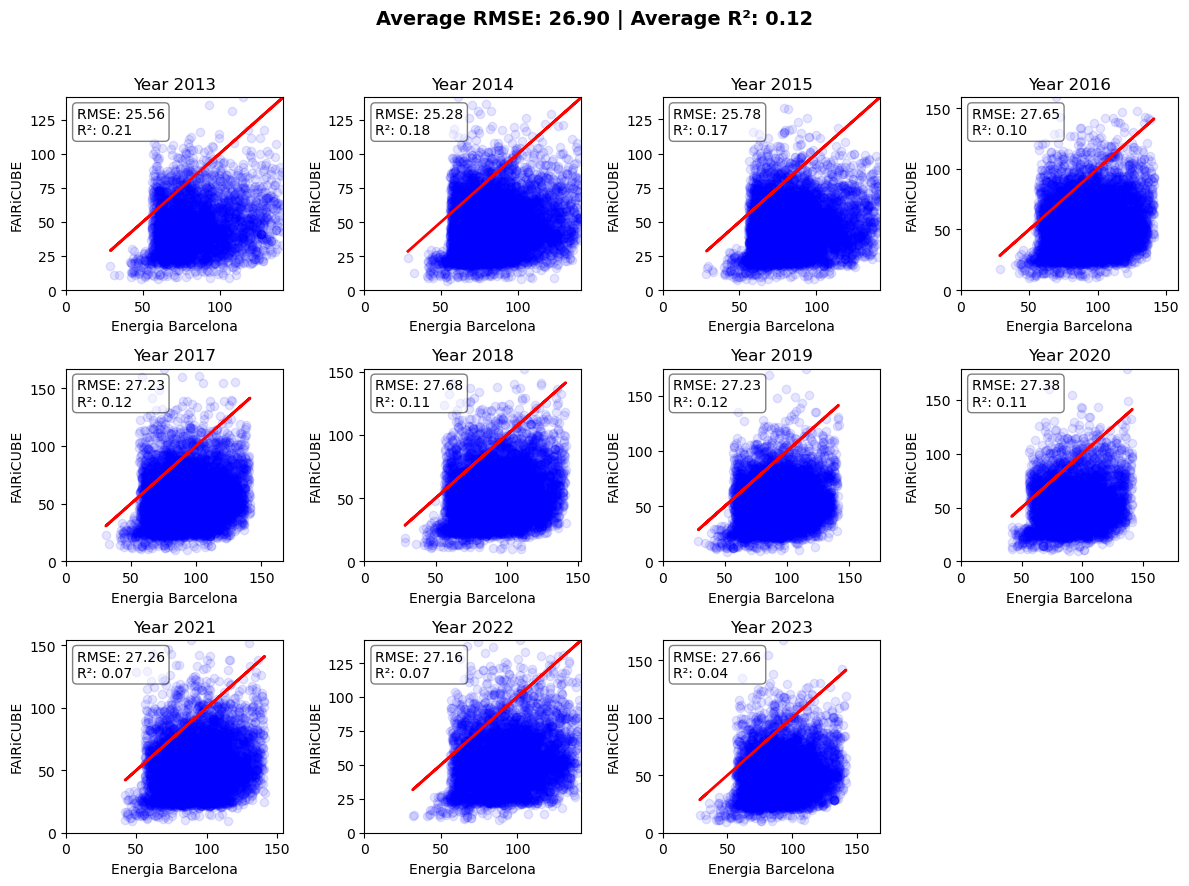

In [43]:
from sklearn.metrics import mean_squared_error, r2_score

# Function to calculate and display RMSE and R² for 2D data
def calculate_and_display_metrics(ax, true_x, true_y, pred_x, pred_y):
    """Compute RMSE and R² for 2D predictor and true values and display them on a subplot."""
    # Drop NaN values to avoid computation errors
    valid_data = np.isfinite(true_x) & np.isfinite(true_y) & np.isfinite(pred_x) & np.isfinite(pred_y)
    true_x, true_y, pred_x, pred_y = true_x[valid_data], true_y[valid_data], pred_x[valid_data], pred_y[valid_data]

    # Compute Euclidean distances for true and predicted points
    true_distances = np.sqrt(true_x**2 + true_y**2)
    pred_distances = np.sqrt(pred_x**2 + pred_y**2)

    # Compute RMSE and R² score
    mse = mean_squared_error(true_distances, pred_distances)
    rmse = np.sqrt(mse)  # Compute Root Mean Squared Error
    r2 = r2_score(true_distances, pred_distances)

    # Annotate metrics on the plot
    ax.text(0.05, 0.95, f'RMSE: {rmse:.2f}\nR²: {r2:.2f}', transform=ax.transAxes, 
            fontsize=10, verticalalignment='top', bbox=dict(boxstyle="round", facecolor="white", alpha=0.5))
    
    return rmse, r2

# List to hold available data indices
valid_years = []
rmse_values = []
r2_values = []

# Check available years dynamically
for i in range(11):
    column_name = 'qh_(kwh/m2a)_1_1' + str(2013 + i)
    if column_name in final_df.columns:
        data = final_df[(final_df['year'].astype(int) == 2013 + i) & 
                        (final_df[column_name] < 400) & 
                        (final_df['consum_ene'] > 0)].copy()
        
        if not data.empty:  # Ensure the dataset is not empty before adding it
            valid_years.append(i)

# Dynamically set subplot grid size based on available data
n_subplots = len(valid_years)

if n_subplots == 0:
    print("No valid data available for any year.")
else:
    n_cols = 4  # Number of columns per row (adjustable)
    n_rows = int(np.ceil(n_subplots / n_cols))  # Calculate rows dynamically

    fig, axs = plt.subplots(n_rows, n_cols, figsize=(12, 9))
    axs = axs.flatten()  # Flatten in case of fewer subplots

    # Iterate over valid years
    for idx, i in enumerate(valid_years):
        column_name = 'qh_(kwh/m2a)_1_1' + str(2013 + i)

        data = final_df[(final_df['year'].astype(int) == 2013 + i) & 
                        (final_df[column_name] < 400) &
                        (final_df['consum_ene'] < 400) &
                        (final_df['consum_ene'] > 0)].copy()
        
        # Define true and predicted values correctly
        true_x = data['consum_ene']/2
        true_y = data['consum_ene']/2
        
        pred_x = data['consum_ene']/2
        pred_y = data[column_name]

        # Plot scatter
        axs[idx].scatter(true_x, pred_y, color='blue', marker='o', alpha=0.1, label='Observed vs Predicted')
        axs[idx].plot(true_x, true_x, color='red', linestyle='-', linewidth=2, label='Perfect Prediction (45°)')  # Diagonal reference line
        axs[idx].set_title(f'Year {2013 + i}')
        axs[idx].set_xlabel('Energia Barcelona')
        axs[idx].set_ylabel('FAIRiCUBE')

        # Ensure identical x- and y-axis scales
        max_limit = max(true_x.max(), pred_y.max())
        axs[idx].set_xlim(0, max_limit)
        axs[idx].set_ylim(0, max_limit)

        # Calculate and display metrics
        rmse, r2 = calculate_and_display_metrics(axs[idx], true_x, true_y, pred_x, pred_y)
        rmse_values.append(rmse)
        r2_values.append(r2)
    
    # Compute average RMSE and R² scores
    avg_rmse = np.mean(rmse_values)
    avg_r2 = np.mean(r2_values)

    # Display average metrics in the plot
    fig.suptitle(f'Average RMSE: {avg_rmse:.2f} | Average R²: {avg_r2:.2f}', fontsize=14, fontweight='bold')

    # Hide unused subplots if there are fewer plots than grid spaces
    for j in range(idx + 1, len(axs)):
        fig.delaxes(axs[j])

    # Adjust layout and show plot
    plt.tight_layout(rect=[0, 0, 1, 0.96])  # Leave space for the suptitle
    plt.savefig("barcelona_energy_use_esimate.png", dpi=300)
    plt.show()

374
805
725
670
685
655
585
492
590
535
507


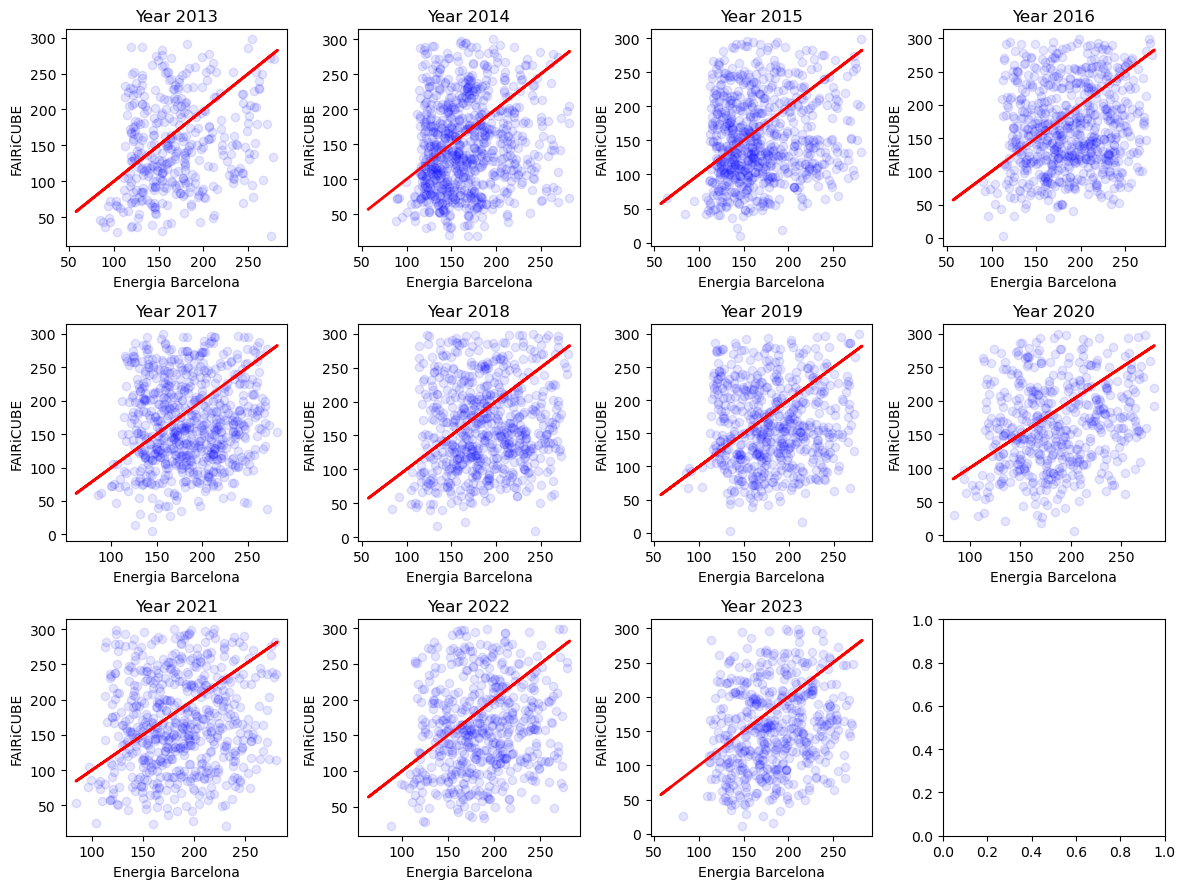

In [17]:
# Create a grid plot with 12 subplots arranged in a 3x4 grid
fig, axs = plt.subplots(3, 4, figsize=(12, 9))

# Flatten the axs array to easily access each subplot
axs = axs.flatten()

# Plot data in each subplot, skipping 2024
for i in range(12):
    year = 2013 + i
    if year == 2024:
        continue  # Skip plotting for 2024
    
    # Filter and sample 10% of the data
    data = final_df[(final_df['year'].astype(int) == year) & (final_df['qh_(kwh/m2a)_1_1'+str(year)].iloc[:,1] < 300)]
    sampled_data = data.sample(frac=0.1, random_state=42)  # Randomly sample 10% of the data
    
    print(len(sampled_data))  # Check the length of the sampled data

    axs[i].scatter(sampled_data['consum_ene'], sampled_data['qh_(kwh/m2a)_1_1'+str(year)].iloc[:,1], 
                   color='blue', marker='o', alpha=0.1, label='Observed vs Predicted')
    axs[i].plot(data['consum_ene'], data['consum_ene'], 
                color='red', linestyle='-', linewidth=2, label='Perfect Prediction (45°)')  # Add a diagonal line for perfect prediction
    axs[i].set_title(f'Year {year}')
    axs[i].set_xlabel('Energia Barcelona')
    axs[i].set_ylabel('FAIRiCUBE')

# Adjust layout and show plot
plt.tight_layout()
plt.show()

388
838
748
734
751
708
631
534
639
573
540


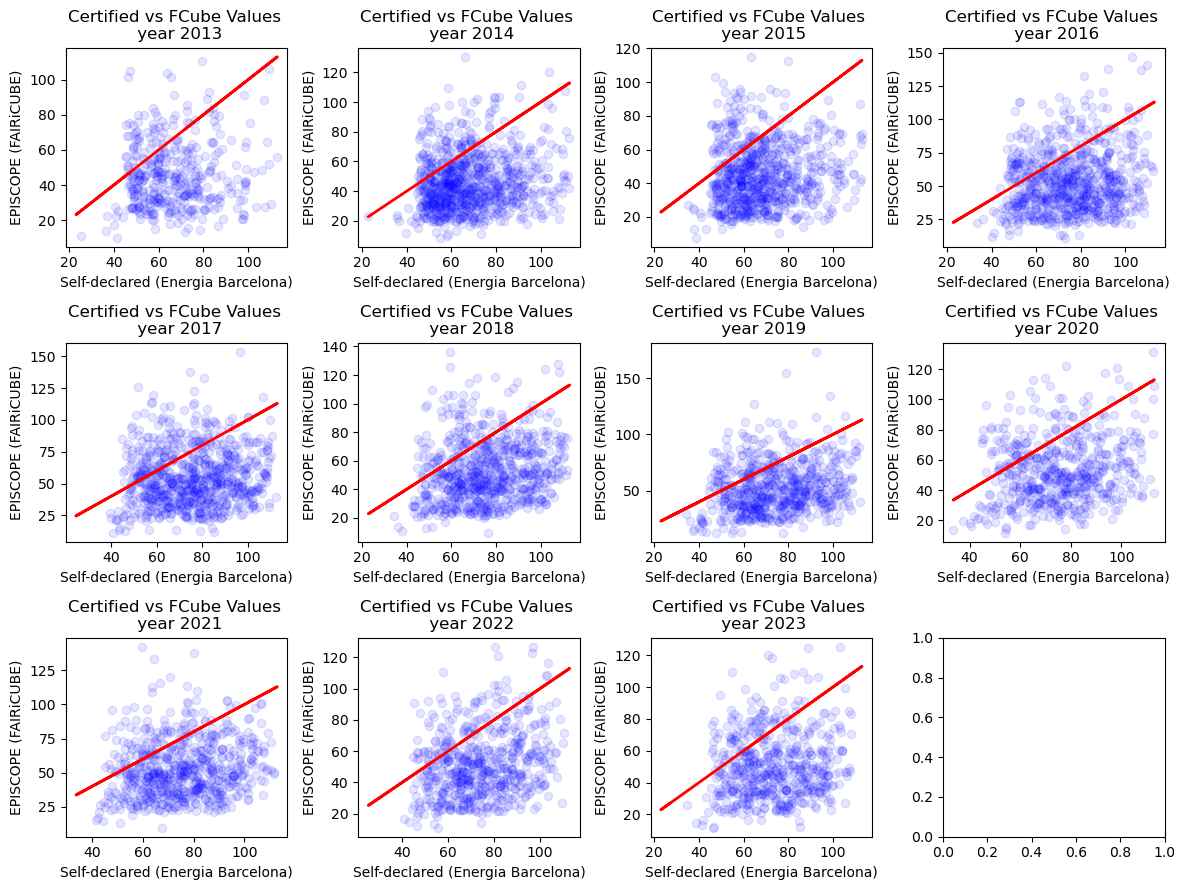

In [31]:
# Create a grid plot with 12 subplots arranged in a 3x4 grid
fig, axs = plt.subplots(3, 4, figsize=(12, 9))

# Flatten the axs array to easily access each subplot
axs = axs.flatten()

# Plot data in each subplot, skipping 2024
for i in range(12):
    year = 2013 + i
    if year == 2024:
        continue  # Skip plotting for 2024
    
    # Filter and sample 10% of the data
    data = final_df[(final_df['year'].astype(int) == year) & (final_df['qh_(kwh/m2a)_1_1'+str(year)] < 400)]
    sampled_data = data.sample(frac=0.1, random_state=42)  # Randomly sample 10% of the data
    
    print(len(sampled_data))  # Check the length of the sampled data

    axs[i].scatter(sampled_data['consum_ene']*0.4, sampled_data['qh_(kwh/m2a)_1_1'+str(year)], 
                   color='blue', marker='o', alpha=0.1, label='Observed vs Predicted')
    axs[i].plot(data['consum_ene']*0.4, data['consum_ene']*0.4, 
                color='red', linestyle='-', linewidth=2, label='Perfect Prediction (45°)')  # Add a diagonal line for perfect prediction
    axs[i].set_title(f'Certified vs FCube Values \n year {year}')
    axs[i].set_xlabel('Self-declared (Energia Barcelona)')
    axs[i].set_ylabel('EPISCOPE (FAIRiCUBE)')

# Adjust layout and show plot
plt.tight_layout()
plt.show()

388
838
748
734
750
708
631
534
639
573
539


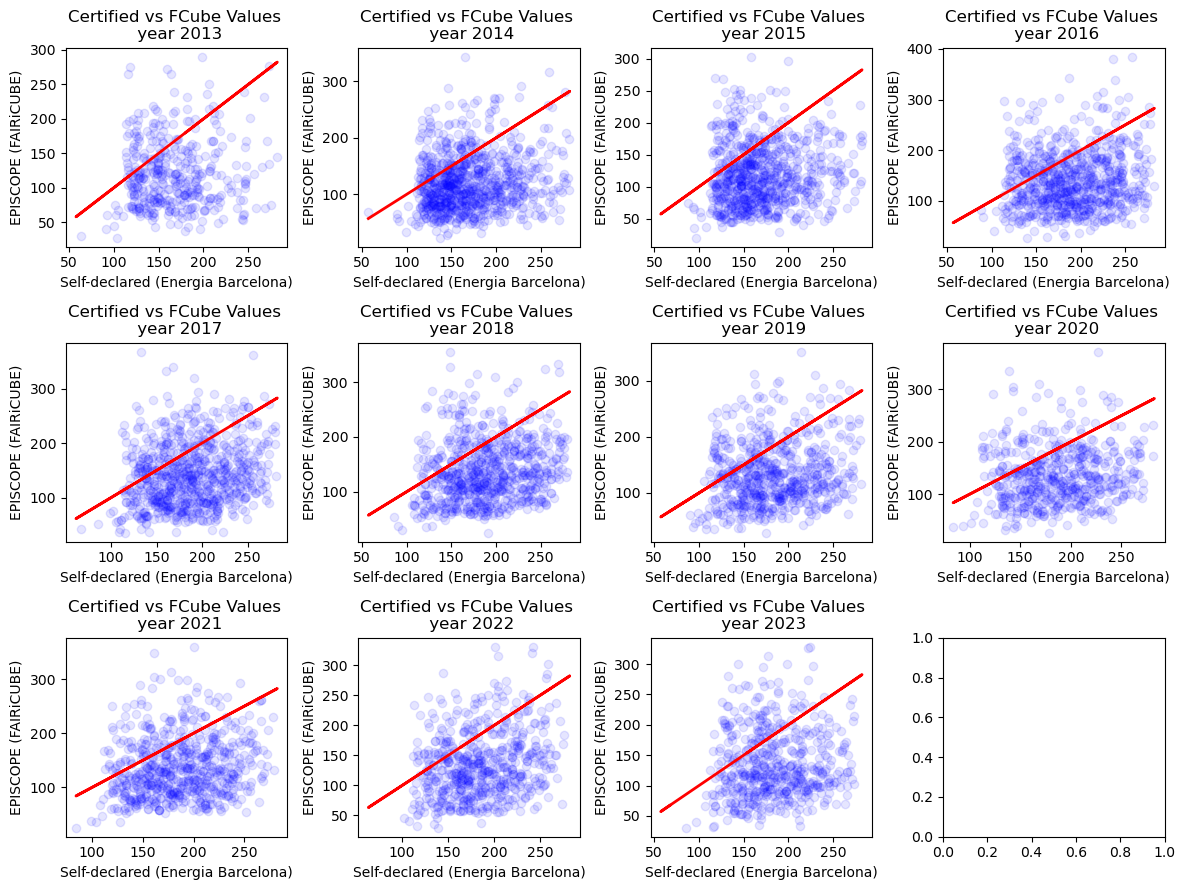

In [135]:
# Create a grid plot with 12 subplots arranged in a 3x4 grid
fig, axs = plt.subplots(3, 4, figsize=(12, 9))

# Flatten the axs array to easily access each subplot
axs = axs.flatten()

# Plot data in each subplot, skipping 2024
for i in range(12):
    year = 2013 + i
    if year == 2024:
        continue  # Skip plotting for 2024
    
    # Filter and sample 10% of the data
    data = final_df[(final_df['year'].astype(int) == year) & (final_df['qh_(kwh/m2a)_1_1'+str(year)] < 400)]
    sampled_data = data.sample(frac=0.1, random_state=42)  # Randomly sample 10% of the data
    
    print(len(sampled_data))  # Check the length of the sampled data

    axs[i].scatter(sampled_data['consum_ene'], sampled_data['qh_(kwh/m2a)_1_1'+str(year)], 
                   color='blue', marker='o', alpha=0.1, label='Observed vs Predicted')
    axs[i].plot(data['consum_ene'], data['consum_ene'], 
                color='red', linestyle='-', linewidth=2, label='Perfect Prediction (45°)')  # Add a diagonal line for perfect prediction
    axs[i].set_title(f'Certified vs FCube Values \n year {year}')
    axs[i].set_xlabel('Self-declared (Energia Barcelona)')
    axs[i].set_ylabel('EPISCOPE (FAIRiCUBE)')

# Adjust layout and show plot
plt.tight_layout()
plt.show()

593
1571
1309
1220
1223
1118
991
800
979
868
790


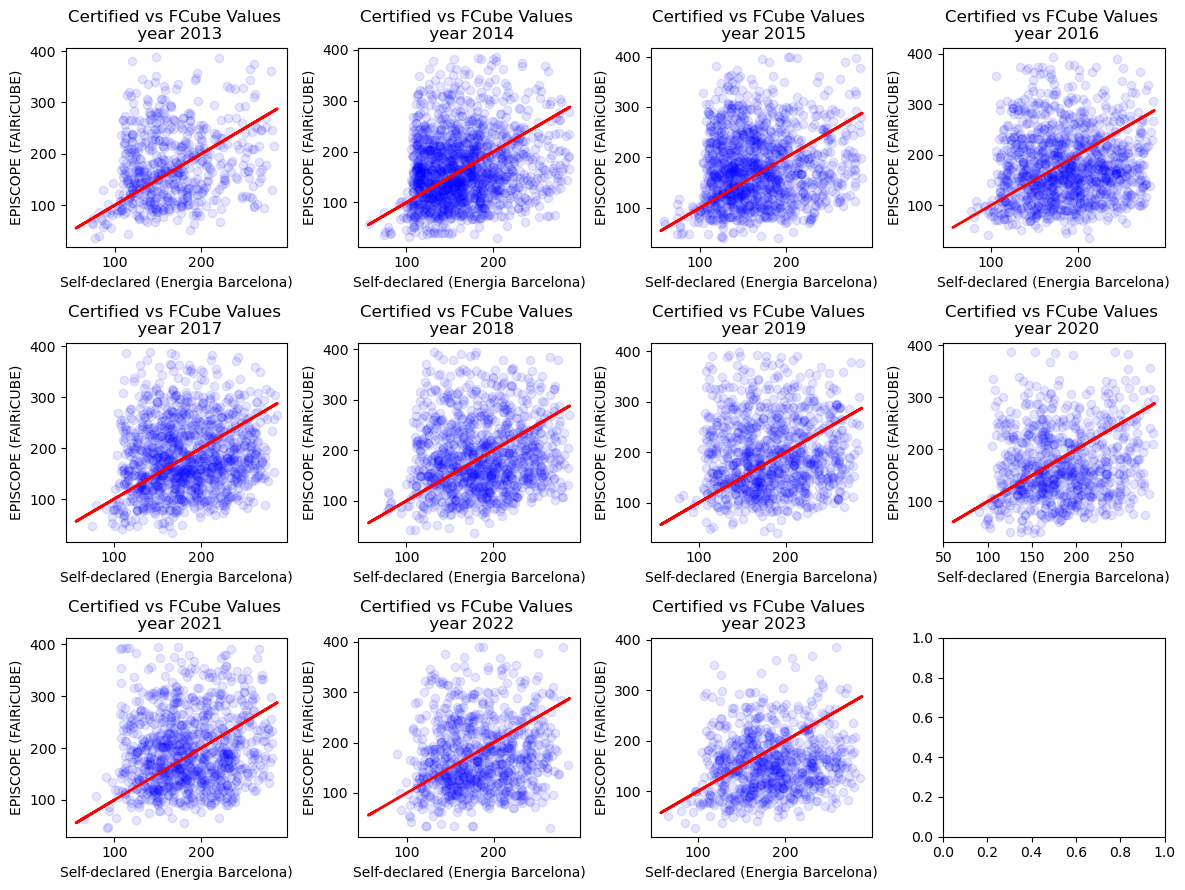

In [23]:
# Create a grid plot with 12 subplots arranged in a 3x4 grid
fig, axs = plt.subplots(3, 4, figsize=(12, 9))

# Flatten the axs array to easily access each subplot
axs = axs.flatten()

# Plot data in each subplot, skipping 2024
for i in range(12):
    year = 2013 + i
    if year == 2024:
        continue  # Skip plotting for 2024
    
    # Filter and sample 10% of the data
    data = final_df[(final_df['year'].astype(int) == year) & (final_df['qh_(kwh/m2a)_1_1'+str(year)] < 400)]
    sampled_data = data.sample(frac=0.1, random_state=42)  # Randomly sample 10% of the data
    
    print(len(sampled_data))  # Check the length of the sampled data

    axs[i].scatter(sampled_data['consum_ene'], sampled_data['qh_(kwh/m2a)_1_1'+str(year)], 
                   color='blue', marker='o', alpha=0.1, label='Observed vs Predicted')
    axs[i].plot(data['consum_ene'], data['consum_ene'], 
                color='red', linestyle='-', linewidth=2, label='Perfect Prediction (45°)')  # Add a diagonal line for perfect prediction
    axs[i].set_title(f'Certified vs FCube Values \n year {year}')
    axs[i].set_xlabel('Self-declared (Energia Barcelona)')
    axs[i].set_ylabel('EPISCOPE (FAIRiCUBE)')

# Adjust layout and show plot
plt.tight_layout()
plt.show()

1393
3735
3058
2951
2924
2740
2387
1931
2359
2116
1954


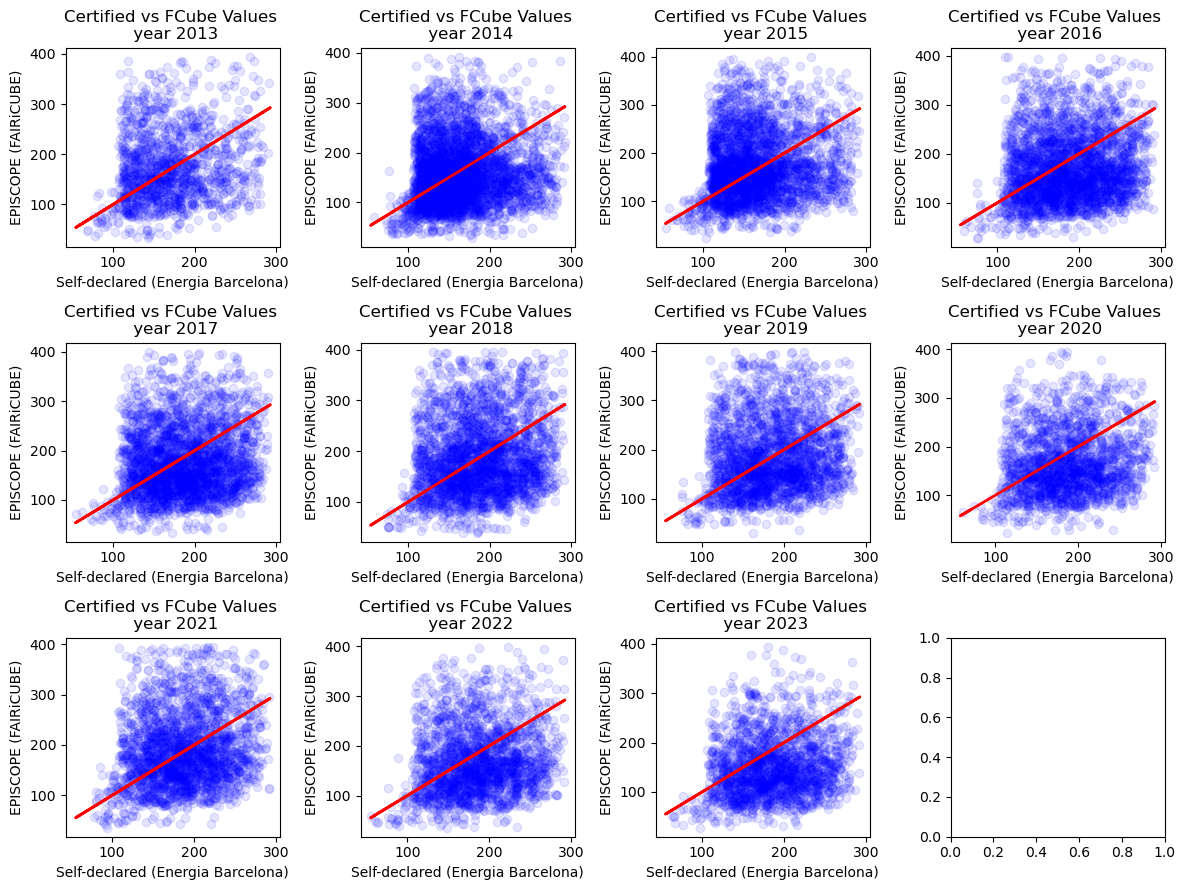

In [28]:
# Create a grid plot with 12 subplots arranged in a 3x4 grid
fig, axs = plt.subplots(3, 4, figsize=(12, 9))

# Flatten the axs array to easily access each subplot
axs = axs.flatten()

# Plot data in each subplot, skipping 2024
for i in range(12):
    year = 2013 + i
    if year == 2024:
        continue  # Skip plotting for 2024
    
    # Filter and sample 10% of the data
    data = final_df[(final_df['year'].astype(int) == year) & (final_df['qh_(kwh/m2a)_1_1'+str(year)] < 400)]
    sampled_data = data.sample(frac=0.1, random_state=42)  # Randomly sample 10% of the data
    
    print(len(sampled_data))  # Check the length of the sampled data

    axs[i].scatter(sampled_data['consum_ene'], sampled_data['qh_(kwh/m2a)_1_1'+str(year)], 
                   color='blue', marker='o', alpha=0.1, label='Observed vs Predicted')
    axs[i].plot(data['consum_ene'], data['consum_ene'], 
                color='red', linestyle='-', linewidth=2, label='Perfect Prediction (45°)')  # Add a diagonal line for perfect prediction
    axs[i].set_title(f'Certified vs FCube Values \n year {year}')
    axs[i].set_xlabel('Self-declared (Energia Barcelona)')
    axs[i].set_ylabel('EPISCOPE (FAIRiCUBE)')

# Adjust layout and show plot
plt.tight_layout()
plt.show()

1403
3746
3080
2965
2946
2770
2412
1938
2397
2126
1956


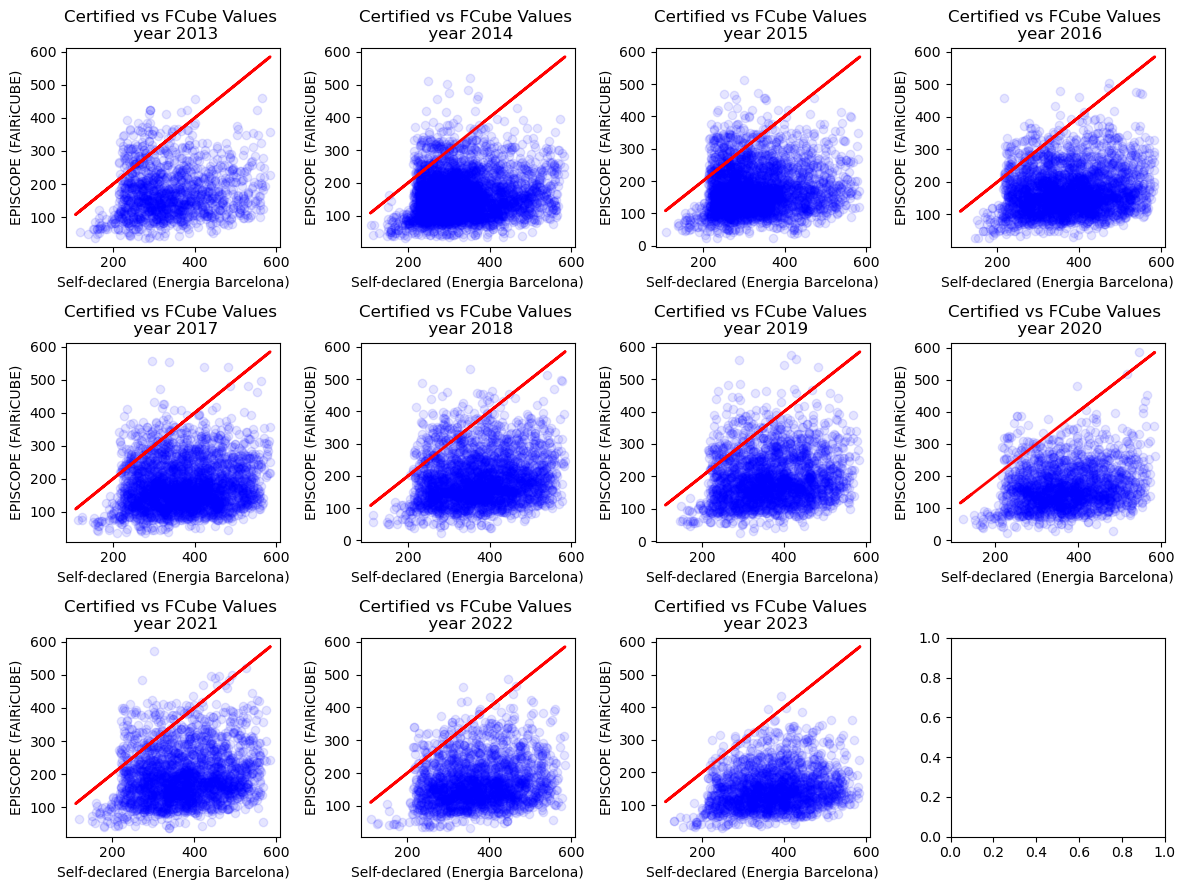

In [9]:
# Create a grid plot with 12 subplots arranged in a 3x4 grid
fig, axs = plt.subplots(3, 4, figsize=(12, 9))

# Flatten the axs array to easily access each subplot
axs = axs.flatten()

# Plot data in each subplot, skipping 2024
for i in range(12):
    year = 2013 + i
    if year == 2024:
        continue  # Skip plotting for 2024
    
    # Filter and sample 10% of the data
    data = final_df[(final_df['year'].astype(int) == year) & (final_df['qh_(kwh/m2a)_1_1'+str(year)] < 600)]
    sampled_data = data.sample(frac=0.1, random_state=42)  # Randomly sample 10% of the data
    
    print(len(sampled_data))  # Check the length of the sampled data

    axs[i].scatter(sampled_data['consum_ene']/0.5, sampled_data['qh_(kwh/m2a)_1_1'+str(year)], 
                   color='blue', marker='o', alpha=0.1, label='Observed vs Predicted')
    axs[i].plot(data['consum_ene']/0.5, data['consum_ene']/0.5, 
                color='red', linestyle='-', linewidth=2, label='Perfect Prediction (45°)')  # Add a diagonal line for perfect prediction
    axs[i].set_title(f'Certified vs FCube Values \n year {year}')
    axs[i].set_xlabel('Self-declared (Energia Barcelona)')
    axs[i].set_ylabel('EPISCOPE (FAIRiCUBE)')

# Adjust layout and show plot
plt.tight_layout()
plt.show()


14005
37419
30738
29576
29346
27622
24070
19342
23873
21238
19546


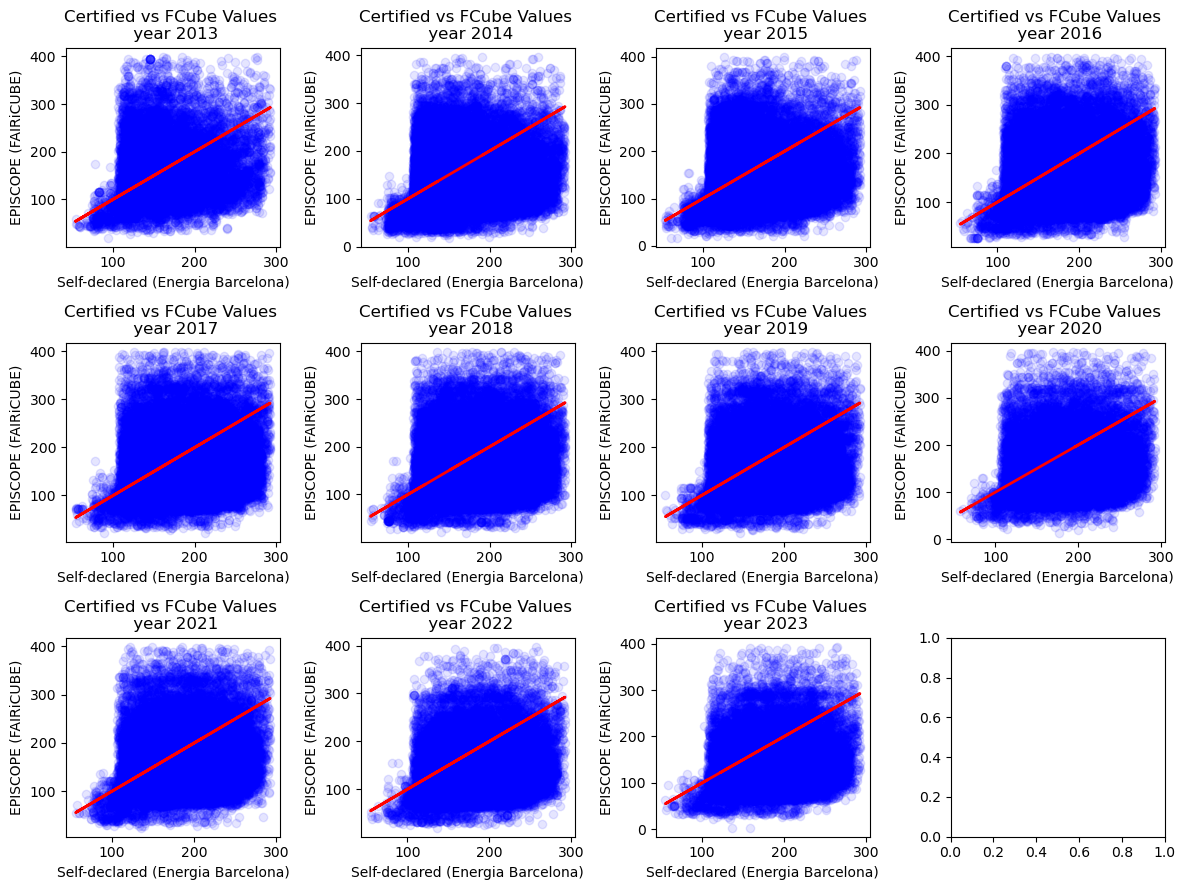

In [24]:
# Create a grid plot with 12 subplots arranged in a 3x4 grid
fig, axs = plt.subplots(3, 4, figsize=(12, 9))

# Flatten the axs array to easily access each subplot
axs = axs.flatten()

# Plot data in each subplot, skipping 2024
for i in range(12):
    year = 2013 + i
    if year == 2024:
        continue  # Skip plotting for 2024
    
    data = final_df[(final_df['year'].astype(int) == year) & (final_df['qh_(kwh/m2a)_1_1'+str(year)]<600)]
    print(len(data))

    axs[i].scatter(data['consum_ene'], data['qh_(kwh/m2a)_1_1'+str(year)]/1.5, color='blue', marker='o', alpha=0.1, label='Observed vs Predicted')
    axs[i].plot(data['consum_ene'], data['consum_ene'], color='red', linestyle='-', linewidth=2, label='Perfect Prediction (45°)')  # Add a diagonal line for perfect prediction
    axs[i].set_title(f'Certified vs FCube Values \n year {year}')
    axs[i].set_xlabel('Self-declared (Energia Barcelona)')
    axs[i].set_ylabel('EPISCOPE (FAIRiCUBE)')

# Adjust layout and show plot
plt.tight_layout()
plt.show()

12928
36099
29322
27664
27152
25606
22418
18144
21977
20281
18642


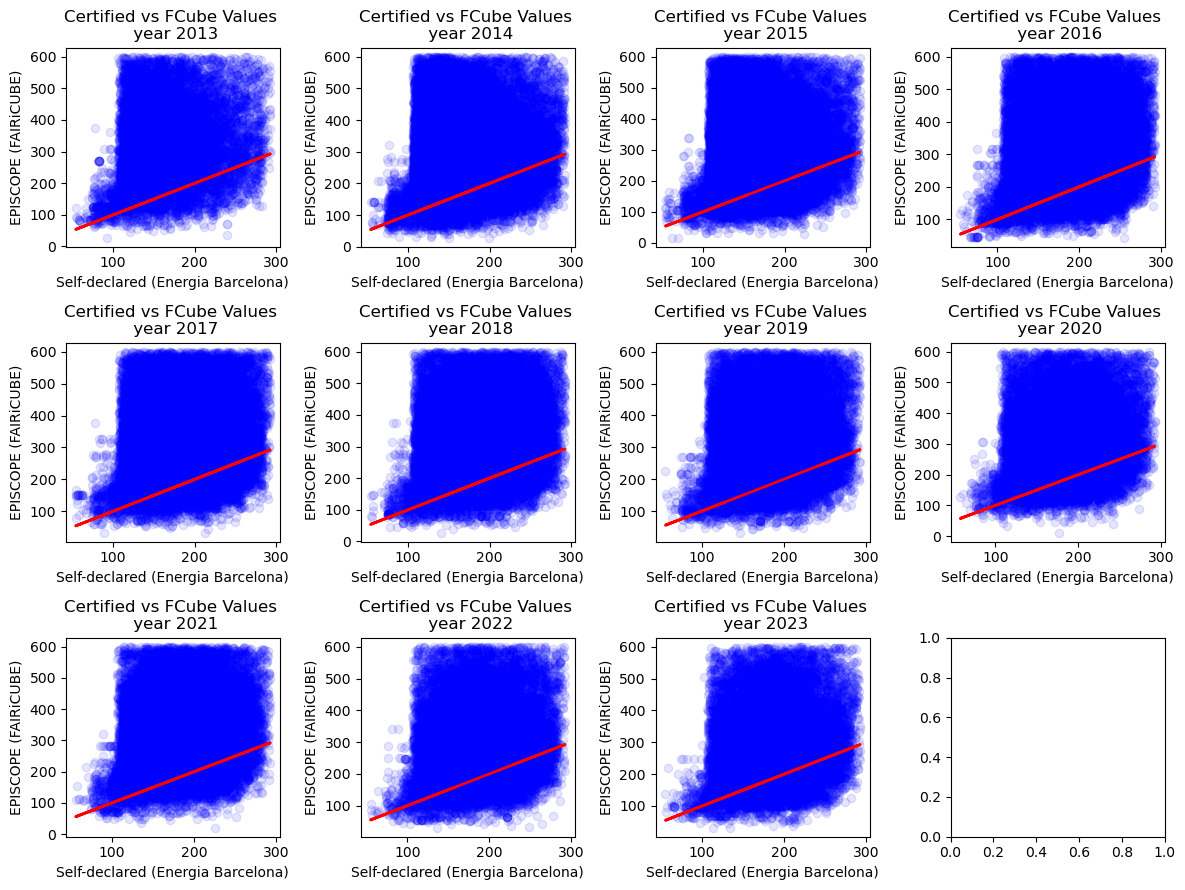

In [7]:
# Create a grid plot with 12 subplots arranged in a 3x4 grid
fig, axs = plt.subplots(3, 4, figsize=(12, 9))

# Flatten the axs array to easily access each subplot
axs = axs.flatten()

# Plot data in each subplot, skipping 2024
for i in range(12):
    year = 2013 + i
    if year == 2024:
        continue  # Skip plotting for 2024
    
    data = final_df[(final_df['year'].astype(int) == year) & (final_df['qh_(kwh/m2a)_0.6_1'+str(year)]<600)]
    
    print(len(data))

    axs[i].scatter(data['consum_ene'], data['qh_(kwh/m2a)_0.6_1'+str(year)], color='blue', marker='o', alpha=0.1, label='Observed vs Predicted')
    axs[i].plot(data['consum_ene'], data['consum_ene'], color='red', linestyle='-', linewidth=2, label='Perfect Prediction (45°)')  # Add a diagonal line for perfect prediction
    axs[i].set_title(f'Certified vs FCube Values \n year {year}')
    axs[i].set_xlabel('Self-declared (Energia Barcelona)')
    axs[i].set_ylabel('EPISCOPE (FAIRiCUBE)')

# Adjust layout and show plot
plt.tight_layout()
plt.show()

14034
37457
30798
29650
29458
27703
24123
19380
23972
21255
19561


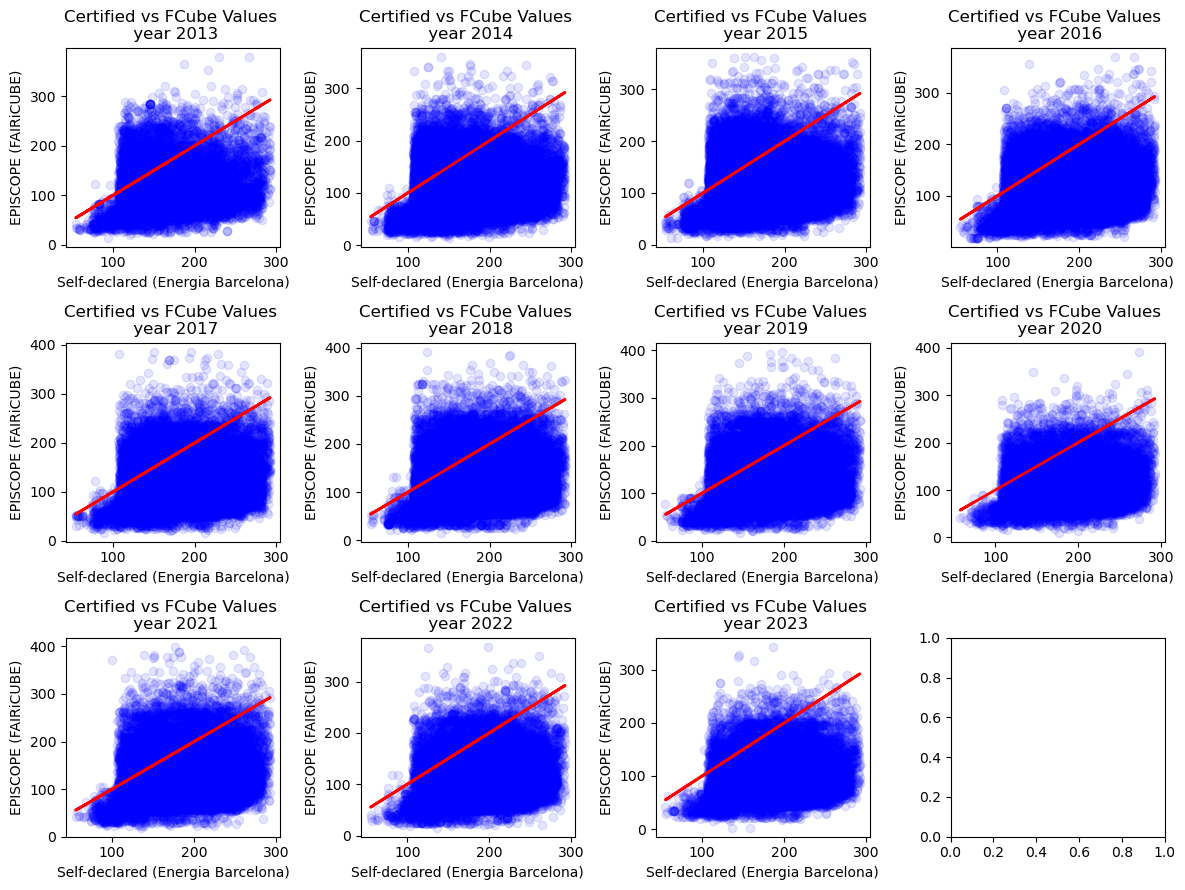

In [6]:
# Create a grid plot with 12 subplots arranged in a 3x4 grid
fig, axs = plt.subplots(3, 4, figsize=(12, 9))

# Flatten the axs array to easily access each subplot
axs = axs.flatten()

# Plot data in each subplot, skipping 2024
for i in range(12):
    year = 2013 + i
    if year == 2024:
        continue  # Skip plotting for 2024
    
    data = final_df[(final_df['year'].astype(int) == year) & (final_df['qh_(kwh/m2a)_1_1'+str(year)]<600)]
    print(len(data))

    axs[i].scatter(data['consum_ene'], data['qh_(kwh/m2a)_1_1'+str(year)]/1.5, color='blue', marker='o', alpha=0.1, label='Observed vs Predicted')
    axs[i].plot(data['consum_ene'], data['consum_ene'], color='red', linestyle='-', linewidth=2, label='Perfect Prediction (45°)')  # Add a diagonal line for perfect prediction
    axs[i].set_title(f'Certified vs FCube Values \n year {year}')
    axs[i].set_xlabel('Self-declared (Energia Barcelona)')
    axs[i].set_ylabel('EPISCOPE (FAIRiCUBE)')

# Adjust layout and show plot
plt.tight_layout()
plt.show()

In [181]:
test = gpd.read_file(os.path.join(upath, 'Barcelona/Energy_certification/Shapefile/ENERGIA_CERTIFICATS_EDIFICIS.shp'))

In [195]:
test['US_EDIFICI'].unique()

array(["Habitatge individual en bloc d'habitatges",
       'Habitatge unifamiliar', 'Vivienda unifamiliar',
       'Vivienda individual en bloque de viviendas', 'Terciari',
       "Bloc d'habitatges plurifamiliar", 'Terciario',
       "Bloc d'habitatges", 'Bloque de viviendas plurifamiliar',
       'Bloque de viviendas', 'Habitatge Unifamiliar', None], dtype=object)

In [188]:
test[['LINK_CERCA',
       'METRES_CAD', 'MOTIU_CERT', 'NOM_COMARC', 'NOM_POBLAC', 'NOM_PROVIN',
       'NORMATIVA_', 'NUM_CADAST', 'NUM_CAS', 'NUM_HABITA', 'PROCEDIMEN',
       'Q_EMISSION', 'Q_ENERGIA', 'TIPUS_TERC', 'TIPUS_TRAM', 'TITULACIO_',
       'US_EDIFICI']]

,LINK_CERCA,METRES_CAD,MOTIU_CERT,NOM_COMARC,NOM_POBLAC,NOM_PROVIN,NORMATIVA_,NUM_CADAST,NUM_CAS,NUM_HABITA,PROCEDIMEN,Q_EMISSION,Q_ENERGIA,TIPUS_TERC,TIPUS_TRAM,TITULACIO_,US_EDIFICI
0,https://certificacioenergetica.gencat.cat/icae...,73.00,Lloguer,Vallès Occidental,Terrassa,Barcelona,NBE-CT-79,0022177DG2002A0095SH,3BR6DKQWW,NaN,CE3X,E,E,None,EDIFICIS_EXISTENTS,Arquitecte,Habitatge individual en bloc d'habitatges
1,https://certificacioenergetica.gencat.cat/icae...,104.59,Lloguer,Barcelonès,Barcelona,Barcelona,Abans de 1979,1717313DF3811H0007ZL,6L9JZ7GW3,NaN,CE3X,E,E,None,EDIFICIS_EXISTENTS,Arquitecte Tècnic,Habitatge individual en bloc d'habitatges
2,https://certificacioenergetica.gencat.cat/icae...,54.38,Compra o Venda,Barcelonès,Badalona,Barcelona,Abans de 1979,6704901DF3960D0027HT,8KQCKX32H,NaN,CE3X,E,E,None,EDIFICIS_EXISTENTS,Arquitecte Tècnic,Habitatge individual en bloc d'habitatges
3,https://certificacioenergetica.gencat.cat/icae...,81.00,Lloguer,Garraf,Sitges,Barcelona,Abans de 1979,9861022CF9696S0003QD,7GPSDLM7Y,NaN,CE3X,E,F,None,EDIFICIS_EXISTENTS,Arquitecte Tècnic,Habitatge individual en bloc d'habitatges
4,https://certificacioenergetica.gencat.cat/icae...,83.00,Compravenda,Tarragonès,Salou,Tarragona,CTE 2006,3591404CF4439B0009SZ,FNJVFJDC3,NaN,CE3X,E,E,None,EDIFICIS_EXISTENTS,Enginyer,Habitatge individual en bloc d'habitatges
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1685125,https://certificacioenergetica.gencat.cat/icae...,73.00,Compra o Venda,Segrià,Lleida,Lleida,Abans de 1979,1793204CG0019D0010HX,114KN4MTY,NaN,CE3X,F,F,None,EDIFICIS_EXISTENTS,Arquitecte,Habitatge individual en bloc d'habitatges
1685126,https://certificacioenergetica.gencat.cat/icae...,61.00,Lloguer,Barcelonès,Barcelona,Barcelona,Abans de 1979,8439502DF2883G0013JJ,F79F5R7K1,NaN,CE3X,G,G,None,EDIFICIS_EXISTENTS,Enginyer Tècnic,Habitatge individual en bloc d'habitatges
1685127,https://certificacioenergetica.gencat.cat/icae...,44.19,Compra o Venda,Barcelonès,Barcelona,Barcelona,Abans de 1979,8855901DF2885F0011JJ,55C93J0YJ,NaN,CE3X,F,G,None,EDIFICIS_EXISTENTS,Arquitecte,Habitatge individual en bloc d'habitatges
1685128,https://certificacioenergetica.gencat.cat/icae...,373.60,Nova construcció,Osona,Roda de Ter,Barcelona,CTE 2013,3282201DG4438S0001OW,3N1CPMGNJ,5.0,CERMA,B,B,None,EDIFICIS_EN_PROJECTE,Arquitecte,Bloc d'habitatges plurifamiliar


In [196]:
# Keywords indicating residential buildings
residential_keywords = ['Habitatges', 'Lloguer', 'Alquiler', 'Compra', 'Venda', 'Venta']


test = test[
    test['MOTIU_CERT'].apply(lambda desc: 
        any(keyword in desc for keyword in residential_keywords) and 
        'administració pública' not in desc.lower() and 
        'administrativo' not in desc.lower() and 
        'comercial' not in desc.lower()
    )
]

# Define the mapping from US_EDIFICI labels to clusters
building_cluster_mapping = {
    "Habitatge individual en bloc d'habitatges": 'AB',  # Apartment Building
    'Habitatge unifamiliar': 'SFH',                     # Single-Family House
    'Vivienda unifamiliar': 'SFH',                      # Single-Family House
    'Vivienda individual en bloque de viviendas': 'AB', # Apartment Building
    'Terciari': None,                                   # Exclude tertiary buildings
    "Bloc d'habitatges plurifamiliar": 'MFH',           # Multi-Family House
    'Terciario': None,                                  # Exclude tertiary buildings
    "Bloc d'habitatges": 'MFH',                         # Multi-Family House
    'Bloque de viviendas plurifamiliar': 'MFH',         # Multi-Family House
    'Bloque de viviendas': 'MFH',                       # Multi-Family House
    'Habitatge Unifamiliar': 'SFH',                     # Single-Family House
    None: None                                          # Handle missing values
}

# Create a new column for building clusters
test['Building_Cluster'] = test['US_EDIFICI'].map(building_cluster_mapping)

# Filter out rows where Building_Cluster is None (non-residential or missing values)
test = test[test['Building_Cluster'].notna()]

# Display the filtered DataFrame
test

/home/babakebrahimi/.local/lib/python3.9/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


,ANY_CONSTR,CODI_POSTA,CONSUM_ENE,CONSUM_E00,COST_ENERG,DATA_ENTRA,EMISSIO_CO,ESTAT_TRAM,ID,LINK_CERCA,...,NUM_HABITA,PROCEDIMEN,Q_EMISSION,Q_ENERGIA,TIPUS_TERC,TIPUS_TRAM,TITULACIO_,US_EDIFICI,geometry,Building_Cluster
0,None,8227.0,175.07,NaN,NaN,2.017030e+13,36.42,FINALITZAT,75.0,https://certificacioenergetica.gencat.cat/icae...,...,NaN,CE3X,E,E,None,EDIFICIS_EXISTENTS,Arquitecte,Habitatge individual en bloc d'habitatges,POINT (419925.81 4602002.47),AB
1,None,8003.0,170.75,NaN,NaN,2.017031e+13,36.06,FINALITZAT,76.0,https://certificacioenergetica.gencat.cat/icae...,...,NaN,CE3X,E,E,None,EDIFICIS_EXISTENTS,Arquitecte Tècnic,Habitatge individual en bloc d'habitatges,POINT (431616.53 4581574.65),AB
2,None,8915.0,171.54,NaN,NaN,2.017031e+13,36.23,FINALITZAT,77.0,https://certificacioenergetica.gencat.cat/icae...,...,NaN,CE3X,E,E,None,EDIFICIS_EXISTENTS,Arquitecte Tècnic,Habitatge individual en bloc d'habitatges,POINT (436668.39 4590250.46),AB
3,None,8870.0,227.56,NaN,NaN,2.017052e+13,47.96,FINALITZAT,78.0,https://certificacioenergetica.gencat.cat/icae...,...,NaN,CE3X,E,F,None,EDIFICIS_EXISTENTS,Arquitecte Tècnic,Habitatge individual en bloc d'habitatges,POINT (399712.32 4565928.47),AB
4,None,43840.0,134.30,NaN,NaN,2.017062e+13,27.36,FINALITZAT,79.0,https://certificacioenergetica.gencat.cat/icae...,...,NaN,CE3X,E,E,None,EDIFICIS_EXISTENTS,Enginyer,Habitatge individual en bloc d'habitatges,POINT (343479.29 4548970.21),AB
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1685124,1978,8242.0,136.66,NaN,NaN,2.013092e+13,27.86,CADUCAT,1678626.0,https://certificacioenergetica.gencat.cat/icae...,...,NaN,CE3X,E,E,None,EDIFICIS_EXISTENTS,Arquitecte Tècnic,Habitatge individual en bloc d'habitatges,POINT (402243.13 4620918.23),AB
1685125,None,25002.0,199.85,NaN,NaN,2.013090e+13,52.17,CADUCAT,1678627.0,https://certificacioenergetica.gencat.cat/icae...,...,NaN,CE3X,F,F,None,EDIFICIS_EXISTENTS,Arquitecte,Habitatge individual en bloc d'habitatges,POINT (301614.87 4609197.62),AB
1685126,None,8006.0,388.61,NaN,NaN,2.014072e+13,96.63,CADUCAT,1678628.0,https://certificacioenergetica.gencat.cat/icae...,...,NaN,CE3X,G,G,None,EDIFICIS_EXISTENTS,Enginyer Tècnic,Habitatge individual en bloc d'habitatges,POINT (428427.02 4583789.09),AB
1685127,None,8023.0,269.56,NaN,NaN,2.017012e+13,56.67,FINALITZAT,1678899.0,https://certificacioenergetica.gencat.cat/icae...,...,NaN,CE3X,F,G,None,EDIFICIS_EXISTENTS,Arquitecte,Habitatge individual en bloc d'habitatges,POINT (428713.65 4585281.99),AB


In [3]:
def QH_calc_optimized(VV, year):
    """
    Calculates heating demand (QH) as a function of VV for a specific year.
    
    Parameters:
    - bolig: GeoDataFrame containing building data.
    - buil_set: DataFrame containing TABULA building set data.
    - VV: Ventilation multiplier (scalar).
    - year: Year for which to compute QH values.
    
    Returns:
    - List of QH values (kWh/m2a) for the specified year and VV.
    """
    
    # Extracting parts of TABULA spreadsheet
    buil_set = pd.read_excel(os.path.join(upath, 'tabula-episcope', 'subset_TABULA.xlsx'))
    
    # Removing rows that don't represent a country 
    buil_set = buil_set[buil_set['Code_Country'].notna()]
    buil_set = buil_set[buil_set['Description_BuildingVariant'].notna()]
    buil_set = buil_set[buil_set['Code_Country'] != 'XX']

    # Creating a multiindex
    buil_set.set_index(['Code_Country', 'Code_DataType_Building', 'Name_ClimateRegion', 
                        'Description_BuildingVariant', 'Code_BuildingSizeClass', 
                        'Year1_Building', 'Year2_Building'], inplace=True)

    buil_set = buil_set.sort_index(level=[0, 1, 2, 3, 4])
    
    read_file = os.path.join(upath,r'shapefile/Barcelona/Barcelona_building_shared-wall_energy_certificates_OSM-build-type_v2.sqlite')
    # Reading the generated shapefile containing building info   
    bolig = gpd.read_file(read_file).to_crs('EPSG:3857').reset_index(drop=True)

    # Filtering out buildings without age attribute
    bolig = bolig[(bolig['age'].notna()) & (bolig['type_sourc'] == '1_residential')]
    
    # Define constants
    CO = 'ES'
    Typo = 'ReEx'
    Cl = 'Mediterranean'
    COND_dic = {
        1: ['Existing condition'],
        2: ['Level 1 of improvements'],
        3: ['Level 2 of improvements']
    }

    # Filter buildings for the specified year
    bolig_filtered = bolig[bolig['year'] == year]

    
    if bolig_filtered.empty:
        print(f"No valid buildings found for year {year}.")
        return [], []

    QH_values = []
    ene_cons = []
    
    for index, row in bolig_filtered.iterrows():
        B_type = row['bolig_type']
        Y = row['age']
        
        # Match building set index
        i = None
        for a in buil_set.loc[(CO, Typo, Cl, COND_dic[1], B_type)].index:
            if a[-2] <= Y <= a[-1]:
                y0, y1 = a[-2], a[-1]
                i = (CO, Typo, Cl, COND_dic[1], B_type, y0, y1)
                break

        if i is None:
            continue  # Skip if no matching index found

        # Estimated areas
        A_C_est = row['geometry'].area
        A_wall_est = row['geometry'].length * row['height'] - row['shared_wall']

        # Heat transfer coefficients
        Htr_wall = buil_set.loc[idx[i], 'U_Wall_1'].values * A_wall_est
        Htr = Htr_wall  # Simplified; add other components as needed

        # Heat transfer by ventilation
        Cp_air = 0.34
        Hve = Cp_air * (buil_set.loc[idx[i], 'n_air_use'].values + buil_set.loc[idx[i], 'n_air_infiltration'].values) * A_C_est

#         # Heat balance calculations
#         tmp = (buil_set.loc[idx[i], 'theta_i'].values - buil_set.loc[idx[i], 'Theta_e'].values) * VV
#         Qht = (Htr + Hve) * (tmp * 0.024)

#         # Internal heat source (simplified for VV dependence)
#         Qint = 0.024 * buil_set.loc[idx[i], 'phi_int'].values * VV * A_C_est
        
        try:
            # Perform calculations (e.g., Qht, Qint)
            tmp = (buil_set.loc[idx[i], 'theta_i'].values - buil_set.loc[idx[i], 'Theta_e'].values) * VV
            Qht = (Htr + Hve) * (tmp * 0.024)
            Qint = 0.024 * buil_set.loc[idx[i], 'phi_int'].values * VV * A_C_est
        except Exception as e:
            print(f"Error during QH calculation for index {index}, VV: {VV}, Year: {year}. Exception: {e}")
            continue  # Skip to the next building

        # Energy needed for heating
        QH = Qht - Qint
        
        # Validate QH value
        if QH is None or np.isnan(QH) or QH < 0:
            # print(f"Invalid QH calculated for building index {index}. Skipping row.")
            continue
        
        QH_values.append(QH[0] / A_C_est)
        
        if np.isnan(QH).any():
            print(f"Invalid QH {QH} for index {index}.")
        
        # making sure that the observed_y represent only half of the consumed energy since in accordance with Energia Barcelona 
        # only half of the consumed energy is corresponding to the domestic heating and hot water demand. 
        ene_cons.append(row['consum_ene']/2)
        

    return QH_values, ene_cons


In [55]:
# def QH_calc_optimized(VV, year):
#     """
#     Calculates heating demand (QH) as a function of VV for a specific year.
#     Ensures non-empty results by skipping invalid rows and handling missing data gracefully.
#     """
#     # Define constants
#     CO = 'ES'
#     Typo = 'ReEx'
#     Cl = 'Mediterranean'
#     COND_dic = {
#         1: ['Existing condition'],
#         2: ['Level 1 of improvements'],
#         3: ['Level 2 of improvements']
#     }

#     # Extracting and preparing data
#     buil_set = pd.read_excel(os.path.join(upath, 'tabula-episcope', 'subset_TABULA.xlsx'))
#     buil_set = buil_set[buil_set['Code_Country'].notna()]
#     buil_set = buil_set[buil_set['Description_BuildingVariant'].notna()]
#     buil_set = buil_set[buil_set['Code_Country'] != 'XX']

#     buil_set.set_index(['Code_Country', 'Code_DataType_Building', 'Name_ClimateRegion', 
#                         'Description_BuildingVariant', 'Code_BuildingSizeClass', 
#                         'Year1_Building', 'Year2_Building'], inplace=True)

#     read_file = os.path.join(upath, r'shapefile/Barcelona/Barcelona_building_shared-wall_energy_certificates_OSM-build-type_v2.sqlite')
#     bolig = gpd.read_file(read_file).to_crs('EPSG:3857').reset_index(drop=True)
#     bolig = bolig[(bolig['age'].notna()) & (bolig['type_sourc'] == '1_residential')].drop_duplicates()

#     bolig_filtered = bolig[bolig['year'] == year]

#     # Debug: Check if data exists for the year
#     if bolig_filtered.empty:
#         print(f"No valid buildings found for year {year}.")
#         return [], []

#     QH_values = []
#     ene_cons = []
#     processed_indices = set()  # Track processed buildings

#     for index, row in bolig_filtered.iterrows():
#         if index in processed_indices:
#             continue

#         processed_indices.add(index)
#         B_type = row['bolig_type']
#         Y = row['age']
#         try:
#             # Match the index in the building set
#             i = None
#             for a in buil_set.loc[(CO, Typo, Cl, COND_dic[1], B_type)].index:
#                 if a[-2] <= Y <= a[-1]:
#                     y0, y1 = a[-2], a[-1]
#                     i = (CO, Typo, Cl, COND_dic[1], B_type, y0, y1)
#                     break

#             if i is None:
#                 print(f"No matching index for building type {B_type}, age {Y}. Skipping row.")
#                 continue

#             # Estimated areas
#             A_C_est = row['geometry'].area
#             if A_C_est <= 0:
#                 print(f"Invalid area for building index {index}. Skipping row.")
#                 continue

#             A_wall_est = row['geometry'].length * row['height'] - row['shared_wall']
#             if A_wall_est <= 0:
#                 print(f"Invalid wall area for building index {index}. Skipping row.")
#                 continue

#             # Heat transfer coefficients
#             Htr_wall = buil_set.loc[i, 'U_Wall_1'] * A_wall_est
#             Htr_window = buil_set.loc[i, 'U_Window_1'] * 0.13 * A_wall_est  # Assuming 13% window area
#             Htr_roof = buil_set.loc[i, 'U_Roof_1'] * A_C_est
#             Htr_floor = buil_set.loc[i, 'U_Floor_1'] * A_C_est
#             Htr = Htr_wall + Htr_window + Htr_roof + Htr_floor

#             # Heat transfer by ventilation
#             Cp_air = 0.34
#             Hve = Cp_air * (buil_set.loc[i, 'n_air_use'] + buil_set.loc[i, 'n_air_infiltration']) * A_C_est

#             # Heat balance calculations
#             tmp = (buil_set.loc[i, 'theta_i'] - buil_set.loc[i, 'Theta_e']) * VV
#             Qht = (Htr + Hve) * (tmp * 0.024)
#             Qint = 0.024 * buil_set.loc[i, 'phi_int'] * VV * A_C_est
#             QH = Qht - Qint

#             # Validate QH value
#             if QH is None or np.isnan(QH) or QH < 0:
#                 print(f"Invalid QH calculated for building index {index}. Skipping row.")
#                 continue

#             # Append results
#             QH_values.append(QH[0] / A_C_est)
#             ene_cons.append(row['consum_ene'])

#         except Exception as e:
#             # print(f"Error for building index {index}, year {year}, VV {VV}: {e}")
#             continue

#     # Final validation of results
#     if not QH_values:
#         print(f"No valid QH values calculated for year {year}. Returning empty lists.")
#         return [], []

#     return QH_values, ene_cons


In [4]:
def mse(VV, ratio, year):
    """
    Mean Squared Error function for optimization.
    """
    QH_values, observed_y = QH_calc_optimized(VV, year)

    # Convert observed_y to a NumPy array
    observed_y = np.array(observed_y, dtype=np.float64)

    # Validate QH_calc_optimized Output
    if QH_values is None or len(QH_values) == 0 or np.isnan(QH_values).any():
        print(f"Invalid QH_values for year {year} and VV {VV}. Applying penalty.")
        return 1e6  # Large penalty for invalid results
    if observed_y is None or len(observed_y) == 0 or np.isnan(observed_y).any():
        print(f"Invalid observed_y for year {year}. Applying penalty.")
        return 1e6  # Large penalty for missing observed data

    # Check alignment between QH_values and observed_y
    if len(QH_values) != len(observed_y):
        print(f"Mismatch in data lengths for year {year}: QH_values ({len(QH_values)}) vs observed_y ({len(observed_y)}).")
        return 1e6  # Large penalty for mismatched lengths

    # Compute MSE
    return np.mean((np.array(QH_values) - ratio * observed_y) ** 2)

In [8]:
from scipy.optimize import minimize

def optimize_VV_per_years(years):
    """
    Optimizes VV and ratio for each year to minimize MSE.
    """
    optimal_values = {}

    for year in years:
        print(f"Optimizing for year: {year}")

        # Define the MSE function to minimize for the specific year
        def mse_for_year(params):
            VV, ratio = params  # Unpack parameters
            return mse(VV, ratio, year)

        # Initial guesses for VV and ratio
        initial_guess = [100.0, 0.5]  # VV=100.0, ratio=0.5
        bounds = [(24, 150), (0.4, 1)]  # Bounds for VV and ratio

        # Perform optimization for the current year
        result = minimize(
            mse_for_year,
            x0=initial_guess,  # Initial guesses for VV and ratio
            bounds=bounds,     # Bounds for both parameters
            method="L-BFGS-B"  # Optimization method (recommended for bounded problems)
        )

        # Store the optimal VV and ratio for the current year
        optimal_values[year] = (result.x[0], result.x[1])  # Optimal VV and ratio

        print(f"Year: {year}, Optimal VV: {result.x[0]}, Optimal Ratio: {result.x[1]}, MSE: {result.fun}")

    return optimal_values


In [ ]:
# Run the optimization
years_to_optimize = list(range(2013, 2024))
optimal_VV_results = optimize_VV_per_years(years_to_optimize)

# Store results in a DataFrame
results_df = pd.DataFrame(
    {
        "Year": list(optimal_VV_results.keys()),
        "Optimal VV": [v[0] for v in optimal_VV_results.values()],
        "Optimal Ratio": [v[1] for v in optimal_VV_results.values()]
    }
)

# Output the DataFrame
print("Optimal VV and Ratio values per year:")
print(results_df)

# Save to a CSV file for future reference
results_df.to_csv("optimal_VV_and_ratio_results.csv", index=False)


Optimizing for year: 2013
Year: 2013, Optimal VV: 30.72898035901923, Optimal Ratio: 0.4, MSE: 830.7345350807896
Optimizing for year: 2014
Year: 2014, Optimal VV: 30.78065043886265, Optimal Ratio: 0.4, MSE: 1716.3957681093605
Optimizing for year: 2015
Year: 2015, Optimal VV: 30.094860304801433, Optimal Ratio: 0.4, MSE: 4117.347273144806
Optimizing for year: 2016
Year: 2016, Optimal VV: 35.653602975759874, Optimal Ratio: 0.4, MSE: 1068.0468489901784
Optimizing for year: 2017
Year: 2017, Optimal VV: 35.833235696786794, Optimal Ratio: 0.4, MSE: 1858.3267126191083
Optimizing for year: 2018
Year: 2018, Optimal VV: 35.32954745796016, Optimal Ratio: 0.4, MSE: 729.4630877298627
Optimizing for year: 2019
Year: 2019, Optimal VV: 34.97699118622205, Optimal Ratio: 0.4, MSE: 601.6046515335769
Optimizing for year: 2020


In [11]:
results_df = pd.read_csv(os.path.join(upath, r'Oslo/optimal_temp_results.csv'))
# Converting to a dictionary
year_vv_dict = results_df.set_index("Year")["Optimal VV"].to_dict()
year_vv_dict

{2013: 76.82244257153194,
 2014: 76.95164147069066,
 2015: 75.23741964476586,
 2016: 89.13403723866686,
 2017: 89.5830853560958,
 2018: 88.3238599146904,
 2019: 87.44250353935617,
 2020: 89.59641839340098,
 2021: 89.30338519899377,
 2022: 88.55947520535898,
 2023: 86.8303445484466}

In [39]:
len(data['Concrete (kg/sqm)'])

86

In [32]:
# Parse the building materials and masses into structured data
data = {
    "Timber (kg/sqm)": [
        15, 10, 10, 10, 10, None, None, 20, 15, None, None, 30, 15, 15, 20, 20, 25, 25, 30, 15, 15, 20, 20, 25, 25, None, None,
        15, 15, 15, 15, 15, 20, 15, 20, 20, 25, 20, 20, 20, 15, 20, 20, 25, 20, 20, 20, None, None, None, None, None, None, 20,
        15, 20, 20, None, None, None, 20, 15, 20, 20, None, None, None, None, None, None, None, 20, 25, 25, 25, 25, 30, 30, 30,
        25, 30, 30, 30, 30, 30, 60, None, None, 80, None, 20, None, 100, 30, 30, None, 120, None, None, None, None, 20, 25, None
    ],
    "Mineral Wool (kg/sqm)": [
        10, 10, 40, 5, 15, None, None, None, 10, None, None, None, 10, 10, 15, 15, 20, 25, None, 10, 10, 15, 15, 20, 25, 5, 10,
        10, 15, 15, 20, 20, 60, 10, 20, 20, 25, 30, 35, 60, 10, 20, 20, 25, 30, 35, 60, 5, 10, 18, 18, 18, 22, 22, 60, 10, 15,
        20, 10, None, None, 60, 10, 15, 20, 10, None, None, None, 12, 12, 22, None, None, None, None, None, None, None, 5, 5,
        5, 5, 8, 8, None, None, 10, 5, 14, 36, 8, None, 7.5, 10, 10, None, None, 50, 35
    ],
    "Concrete (kg/sqm)": [
        None, None, None, None, None, None, None, None, None, 80, 80, None, None, None, None, None, None, None, None, None, None, 
        None, None, None, None, 120, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, 
        None, None, None, None, 80, 80, 80, 80, 100, 100, None, None, None, None, 80, 100, 100, None, None, None, None, 80, None, 
        None, None, None, 120, 80, None, None, None, None, None, None, 120, None, 100, 100, None, None, None, None, 20, None, None
    ],
    "Glass (kg/sqm)": [
        None, None, None, None, None, None, 25, None, None, None, None, None, None, None, None, None, None, None, None, None, None,
        None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None,
        None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, 20,
        25, 25, 25, 25, 30, 30, 30, 25, 30, 30, 30, None, 30, None, None, None, None, None, None, None, None, None, None, None
    ],
    "Framing Material (kg/sqm)": [
        None, None, None, None, None, None, 5, None, None, None, None, None, None, None, None, None, None, None, None, None, None,
        None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None,
        None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, 5,
        5, 5, 5, 5, 8, 8, 8, 5, 5, 8, 8, None, None, None, None, None, None, None, None, None, None, None, None, None, None
    ],
    "Other (kg/sqm)": [
        None, None, None, None, None, None, None, None, None, 10, 10, None, None, None, None, None, 2, None, None, None, None, None,
        None, None, 5, None, None, None, None, None, 5, None, None, None, None, None, None, None, None, None, None, None, None,
        None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None,
        None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None
    ]
}

# Create a DataFrame
df = pd.DataFrame(data)


ValueError: All arrays must be of the same length

In [36]:
# Relevant libraries
import geopandas as gpd
import numpy as np
import os
import rasterio
from rasterio.env import Env
from rasterio.merge import merge
from rasterio.crs import CRS
from rasterio.plot import show
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from pyproj import Transformer

In [46]:
# # Function to read and concatenate DEM files
# def DEM_file(read_location, write_location):
#     # Get list of DEM files in the specified directory
#     fd = os.path.join(upath, read_location)
#     files = []
    
#     for fn in os.listdir(fd):
#         if os.path.isfile(os.path.join(fd, fn)) and fn.split('.')[-1] == 'tif':
#             files.append(os.path.join(fd, fn))
    
#     dem_raster_to_mosaic = []
    
#     for p in files:
#         dem_raster_to_mosaic.append(rasterio.open(p))
    
#     # Merge DEM files
#     mosaic, output = merge(dem_raster_to_mosaic)
    
#     print('done')

#     # Copy metadata of the first DEM file and update
#     out_meta = dem_raster_to_mosaic[0].meta.copy()
#     out_meta.update({
#         "driver": "GTiff",
#         "height": mosaic.shape[1],
#         "width": mosaic.shape[2],
#         "transform": output,
#         "crs": CRS.from_epsg(25831)  # Set CRS to EPSG:25831
#     })
    
#     # Use a rasterio environment context to disable the disk check
#     with Env(CHECK_DISK_FREE_SPACE=False):
#         # Write the merged DEM file
#         with rasterio.open(os.path.join(upath, write_location), "w", **out_meta) as dest:
#             dest.write(mosaic)


In [89]:
import os
import rasterio
from rasterio.merge import merge
from rasterio.env import Env
from rasterio.crs import CRS
from pyproj import Transformer

def read_and_merge_DEM_with_bounds(read_location, write_location, target_crs=None, disable_disk_check=True):
    """
    Reads and merges DEM files from a specified directory, extracts geographic bounds,
    and writes the result to a new GeoTIFF file.

    Parameters:
        read_location (str): Path to the directory containing DEM files.
        write_location (str): Path to save the merged DEM file.
        target_crs (str or CRS, optional): CRS to reproject the merged DEM. If None, keeps the original CRS.
        disable_disk_check (bool, optional): Disable disk space check when writing the file. Default is True.

    Returns:
        dict: Geographic bounds (lon/lat) of each input DEM file and the merged DEM file.
    """
    # Get list of all GeoTIFF files in the directory
    fd = os.path.join(upath, read_location)
    files = [
        os.path.join(fd, fn)
        for fn in os.listdir(fd)
        if os.path.isfile(os.path.join(fd, fn)) and fn.lower().endswith('.tif')
    ]
    
    if not files:
        raise FileNotFoundError(f"No GeoTIFF files found in directory: {read_location}")

    # Open each file and prepare for merging
    dem_raster_to_mosaic = [rasterio.open(file) for file in files]

    # Extract geographic bounds (lat/lon) for each input file
    file_bounds = {}
    for file, raster in zip(files, dem_raster_to_mosaic):
        transform = Transformer.from_crs(raster.crs, "EPSG:4326", always_xy=True)
        min_x, min_y, max_x, max_y = raster.bounds
        min_lon, min_lat = transform.transform(min_x, min_y)
        max_lon, max_lat = transform.transform(max_x, max_y)
        file_bounds[file] = {
            "min_lon": min_lon, "min_lat": min_lat,
            "max_lon": max_lon, "max_lat": max_lat
        }

    # Merge the DEM files
    mosaic, output_transform = merge(dem_raster_to_mosaic)
    print(f"Merging {len(files)} DEM files completed.")

    # Use metadata from the first DEM file
    out_meta = dem_raster_to_mosaic[0].meta.copy()

    # Update metadata for the merged DEM
    out_meta.update({
        "driver": "GTiff",
        "height": mosaic.shape[1],
        "width": mosaic.shape[2],
        "transform": output_transform,
        "crs": target_crs or out_meta.get("crs")
    })

    # Calculate bounds for the merged DEM in lat/lon
    transform = Transformer.from_crs(out_meta["crs"], "EPSG:4326", always_xy=True)
    min_x, min_y, max_x, max_y = rasterio.transform.array_bounds(
        mosaic.shape[1], mosaic.shape[2], output_transform
    )
    min_lon, min_lat = transform.transform(min_x, min_y)
    max_lon, max_lat = transform.transform(max_x, max_y)

    # Write the merged DEM to a file
    write_env = Env(CHECK_DISK_FREE_SPACE=not disable_disk_check)
    with write_env:
        with rasterio.open(os.path.join(upath, write_location), "w", **out_meta) as dest:
            dest.write(mosaic)
            print(f"Merged DEM written to: {write_location}")

    # Add merged DEM bounds to the results
    file_bounds["merged"] = {
        "min_lon": min_lon, "min_lat": min_lat,
        "max_lon": max_lon, "max_lat": max_lat
    }

    # Ensure all raster files are properly closed
    for raster in dem_raster_to_mosaic:
        raster.close()

    return file_bounds


In [90]:
%%time

bounds = read_and_merge_DEM_with_bounds(os.path.join(upath,(r'Barcelona/dem/dtm')),
                                        os.path.join(upath,(r'Barcelona/dem/Barcelona_dtm_mosaic.tif')),
                                        target_crs=CRS.from_epsg(25831))

Merging 5 DEM files completed.
Merged DEM written to: /home/babakebrahimi/s3/data/Barcelona/dem/Barcelona_dtm_mosaic.tif
CPU times: user 4.04 s, sys: 1.88 s, total: 5.92 s
Wall time: 1min 50s


In [94]:
import rasterio
from rasterio.warp import reproject, Resampling, calculate_default_transform
import numpy as np

def CHM(dsm_read, dtm_read, write_location):
    """
    Calculate Canopy Height Model (CHM) by subtracting DTM from DSM.

    Parameters:
        dsm_read (str): Path to the DSM GeoTIFF file.
        dtm_read (str): Path to the DTM GeoTIFF file.
        write_location (str): Path to save the output CHM GeoTIFF file.

    Returns:
        None
    """
    # Open DSM and DTM files
    with rasterio.open(dsm_read) as dsm_src, rasterio.open(dtm_read) as dtm_src:
        # Ensure CRS matches
        if dsm_src.crs != dtm_src.crs:
            raise ValueError("DSM and DTM CRS do not match. Please reproject the files to the same CRS.")
        
        # Reproject and resample DTM to match DSM
        dst_transform, dst_width, dst_height = calculate_default_transform(
            dtm_src.crs, dsm_src.crs, dsm_src.width, dsm_src.height, *dsm_src.bounds
        )
        dtm_resampled = np.empty((dsm_src.height, dsm_src.width), dtype=dtm_src.dtypes[0])
        reproject(
            source=rasterio.band(dtm_src, 1),
            destination=dtm_resampled,
            src_transform=dtm_src.transform,
            src_crs=dtm_src.crs,
            dst_transform=dsm_src.transform,
            dst_crs=dsm_src.crs,
            resampling=Resampling.bilinear
        )
        
        # Read DSM data
        dsm_data = dsm_src.read(1, masked=True)
        
        # Calculate CHM
        chm = dsm_data - dtm_resampled
        
        # Prepare metadata for output
        out_meta = dsm_src.meta.copy()
        out_meta.update({
            "driver": "GTiff",
            "height": dsm_src.height,
            "width": dsm_src.width,
            "transform": dsm_src.transform,
            "crs": dsm_src.crs
        })
        
        # Write CHM to a new file
        with rasterio.open(write_location, "w", **out_meta) as dest:
            dest.write(chm, 1)
            
    print(f"CHM successfully created and saved to {write_location}")


In [95]:
CHM(os.path.join(upath,(r'Barcelona/dem/Barcelona_dsm_mosaic.tif')),
    os.path.join(upath,(r'Barcelona/dem/Barcelona_dtm_mosaic.tif')),
    os.path.join(upath,(r'Barcelona/dem/Barcelona_chm_mosaic.tif')))

CHM successfully created and saved to /home/babakebrahimi/s3/data/Barcelona/dem/Barcelona_chm_mosaic.tif


Fetching Barcelona boundary from OpenStreetMap...
Masking raster with Barcelona's boundary...
Filtering height values between -100 and 1000 meters...
Saving filtered raster to /home/babakebrahimi/s3/data/Barcelona/dem/Barcelona_chm_mosaic_clipped_filtered.tif...
Plotting filtered raster...


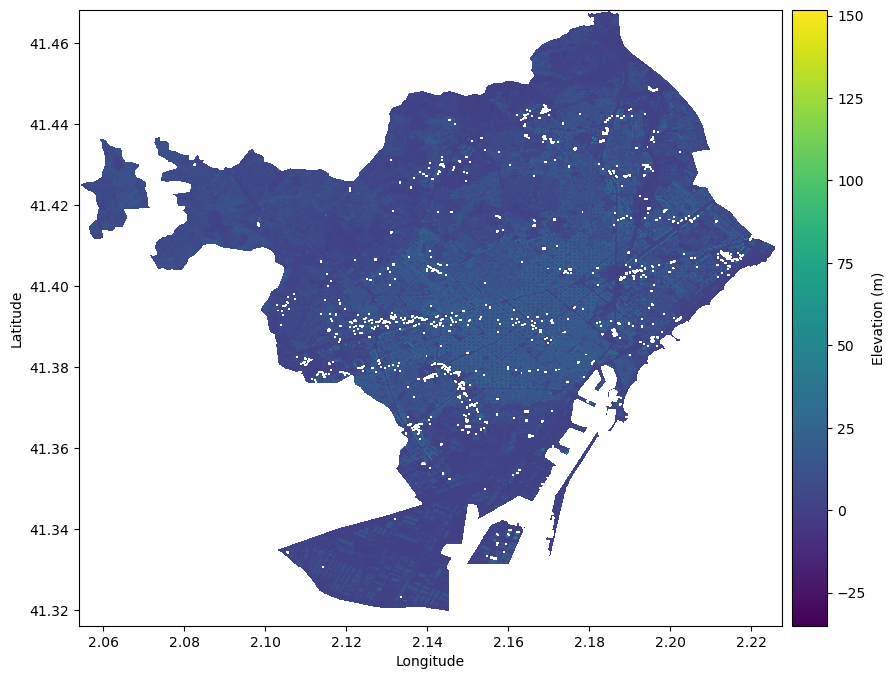

In [7]:
import os
import rasterio
import rasterio.mask
import geopandas as gpd
from pyproj import Transformer
import osmnx as ox
import numpy as np

# Define paths
input_tif_path = os.path.join(upath, r'Barcelona/dem/Barcelona_chm_mosaic.tif')
output_tif_path = os.path.join(upath, r'Barcelona/dem/Barcelona_chm_mosaic_clipped_filtered.tif')

# Step 1: Get Barcelona's boundary from OpenStreetMap
print("Fetching Barcelona boundary from OpenStreetMap...")
barcelona_boundary = ox.geocode_to_gdf("Barcelona, Spain")

# Step 2: Reproject Barcelona's boundary to match raster CRS
with rasterio.open(input_tif_path) as src:
    raster_crs = src.crs
    barcelona_boundary = barcelona_boundary.to_crs(raster_crs)

# Step 3: Mask the raster with Barcelona's boundary
print("Masking raster with Barcelona's boundary...")
with rasterio.open(input_tif_path) as src:
    out_image, out_transform = rasterio.mask.mask(src, barcelona_boundary.geometry, crop=True)
    out_meta = src.meta.copy()

# Step 4: Filter raster values between 0 and 200 meters
print("Filtering height values between -100 and 1000 meters...")
filtered_image = np.where((out_image[0] >= -10000) & (out_image[0] <= 10000), out_image[0], np.nan)

# Update metadata to match the new shape and transform
out_meta.update({
    "driver": "GTiff",
    "height": filtered_image.shape[0],
    "width": filtered_image.shape[1],
    "transform": out_transform,
})

# Step 5: Save the filtered raster
print(f"Saving filtered raster to {output_tif_path}...")
with rasterio.open(output_tif_path, "w", **out_meta) as dest:
    dest.write(np.expand_dims(filtered_image, axis=0))


# Step 6: Plot the filtered raster
print("Plotting filtered raster...")
with rasterio.open(output_tif_path) as src:
    filtered_data = src.read(1)
    transform = src.transform
    crs = src.crs

    # Define a transformer to convert raster CRS to EPSG:4326 (lat/lon)
    transformer = Transformer.from_crs(crs, "EPSG:4326", always_xy=True)

    # Get the corners of the raster in pixel coordinates
    min_x, min_y = transform * (0, src.height)  # Bottom-left corner
    max_x, max_y = transform * (src.width, 0)  # Top-right corner

    # Convert corners to lat/lon
    min_lon, min_lat = transformer.transform(min_x, min_y)
    max_lon, max_lat = transformer.transform(max_x, max_y)

    # Create a figure and axis
    fig, ax = plt.subplots(figsize=(10, 8))

    # Plot the filtered DSM data with lat/lon extent
    img = ax.imshow(
        filtered_data,
        cmap='viridis',
        extent=[min_lon, max_lon, min_lat, max_lat],  # Set extent to lat/lon bounds
        origin='upper'  # Ensure correct orientation
    )

    # Create a divider for the axis to place the color bar in a separate axis
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.1)  # Color bar axis size

    # Create color bar in the separate axis
    plt.colorbar(img, cax=cax, label='Elevation (m)')

    # Set title and labels
    # ax.set_title('Digital Surface Model (DSM) - Clipped and Filtered (0-200m)')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

    # Save the plot as a PNG file
    # plt.savefig(os.path.join(upath, r'Barcelona/Barcelona_dsm_clipped_filtered_plot.png'), dpi=300, bbox_inches='tight')

    # Display the plot
    plt.show()


In [ ]:
import os
import geopandas as gpd
import rasterio
import numpy as np

# Paths
dem_path = os.path.join(upath, r'Barcelona/dem/Barcelona_chm_mosaic.tif')
barca_path = os.path.join(upath, r'shapefile/Barcelona/Barcelona_building-QH_BRA_share_HDD+refurbish_W2W-13%_as_built_W-KM-BT_13degree_OSM_v4.sqlite')

# Read the vector data
barca = gpd.read_file(barca_path).to_crs('EPSG:25831').reset_index(drop=True)

# Compute centroids
barca['centroid'] = barca.geometry.centroid

# Open the raster file
with rasterio.open(dem_path) as src:
    # Ensure raster CRS matches the vector CRS
    raster_crs = src.crs
    print(f"Raster CRS: {raster_crs}")
    print(f"Vector CRS: {barca.crs}")
    
    if raster_crs != barca.crs:
        barca = barca.to_crs(raster_crs)

    # Sample raster values at the centroids
    heights = []
    for centroid in barca['centroid']:
        # Check if centroid is within raster bounds
        if not (src.bounds.left <= centroid.x <= src.bounds.right and
                src.bounds.bottom <= centroid.y <= src.bounds.top):
            print(f"Centroid {centroid} is outside raster bounds.")
            heights.append(np.nan)
            continue

        # Convert the centroid point to raster coordinates
        try:
            row, col = src.index(centroid.x, centroid.y)
            # Get the raster value at the given location
            height = src.read(1)[row, col]
            heights.append(height)
        except IndexError:
            print(f"Error sampling raster for centroid {centroid}.")
            heights.append(np.nan)

# Add the height values to the GeoDataFrame
barca['height_dem'] = heights

# Drop the centroid column if no longer needed
barca = barca.drop(columns=['centroid'])

# Display the resulting GeoDataFrame
print(barca)


Raster CRS: EPSG:25831
Vector CRS: EPSG:25831


In [44]:
barca

,index_left,bolig_type,id,height,age,type,id_source,type_sourc,neighbors,wall_length,...,qh_(kwh/m2a).001_1_12016,qh_(kwh/m2a).001_1_12017,qh_(kwh/m2a).001_1_12018,qh_(kwh/m2a).001_1_12019,qh_(kwh/m2a).001_1_12020,qh_(kwh/m2a).001_1_12021,qh_(kwh/m2a).001_1_12022,qh_(kwh/m2a).001_1_12023,geometry,height_dem
0,5798.0,AB,v0.1-ESP.6.1.3.21_1-94,15.0,1961.0,residential,ES.SDGC.BU.4557801DF3845F,1_residential,[],[],...,NaN,NaN,49.415797,NaN,NaN,NaN,NaN,NaN,"POLYGON ((434468.999 4585487.617, 434420.249 4...",16.953674
1,5798.0,AB,v0.1-ESP.6.1.3.21_1-94,15.0,1961.0,residential,ES.SDGC.BU.4557801DF3845F,1_residential,[],[],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((434468.999 4585487.617, 434420.249 4...",16.953674
2,5798.0,AB,v0.1-ESP.6.1.3.21_1-94,15.0,1961.0,residential,ES.SDGC.BU.4557801DF3845F,1_residential,[],[],...,NaN,NaN,NaN,NaN,NaN,NaN,49.558624,NaN,"POLYGON ((434468.999 4585487.617, 434420.249 4...",16.953674
3,5798.0,AB,v0.1-ESP.6.1.3.21_1-94,15.0,1961.0,residential,ES.SDGC.BU.4557801DF3845F,1_residential,[],[],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,48.51049,"POLYGON ((434468.999 4585487.617, 434420.249 4...",16.953674
4,5798.0,AB,v0.1-ESP.6.1.3.21_1-94,15.0,1961.0,residential,ES.SDGC.BU.4557801DF3845F,1_residential,[],[],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((434468.999 4585487.617, 434420.249 4...",16.953674
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
151781,11819.0,AB,v0.1-ESP.6.1.11.15_1-190,27.5,1995.0,residential,ES.SDGC.BU.7691426DF2779B,1_residential,"['v0.1-ESP.6.1.11.15_1-189', 'v0.1-ESP.6.1.11....","[27.999675973578775, 28.001610807008053]",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((427560.348 4579107.164, 427564.219 4...",33.975731
151782,11819.0,AB,v0.1-ESP.6.1.11.15_1-190,27.5,1995.0,residential,ES.SDGC.BU.7691426DF2779B,1_residential,"['v0.1-ESP.6.1.11.15_1-189', 'v0.1-ESP.6.1.11....","[27.999675973578775, 28.001610807008053]",...,NaN,NaN,26.876749,NaN,NaN,NaN,NaN,NaN,"POLYGON ((427560.348 4579107.164, 427564.219 4...",33.975731
151783,11819.0,AB,v0.1-ESP.6.1.11.15_1-190,27.5,1995.0,residential,ES.SDGC.BU.7691426DF2779B,1_residential,"['v0.1-ESP.6.1.11.15_1-189', 'v0.1-ESP.6.1.11....","[27.999675973578775, 28.001610807008053]",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((427560.348 4579107.164, 427564.219 4...",33.975731
151784,11819.0,AB,v0.1-ESP.6.1.11.15_1-190,27.5,1995.0,residential,ES.SDGC.BU.7691426DF2779B,1_residential,"['v0.1-ESP.6.1.11.15_1-189', 'v0.1-ESP.6.1.11....","[27.999675973578775, 28.001610807008053]",...,NaN,NaN,NaN,NaN,NaN,27.207805,NaN,NaN,"POLYGON ((427560.348 4579107.164, 427564.219 4...",33.975731


In [45]:
# Save the outcome
barca_dem_path = os.path.join(upath, r'shapefile/Barcelona/Barcelona_building-QH_BRA_share_HDD+refurbish_W2W-13%_as_built_W-KM-BT_13degree_OSM_v4_DEM.sqlite')
barca.to_file(barca_dem_path , driver='SQLite')

812
2153
1780
1528
1508
1378
1192
953
1166
1025
925


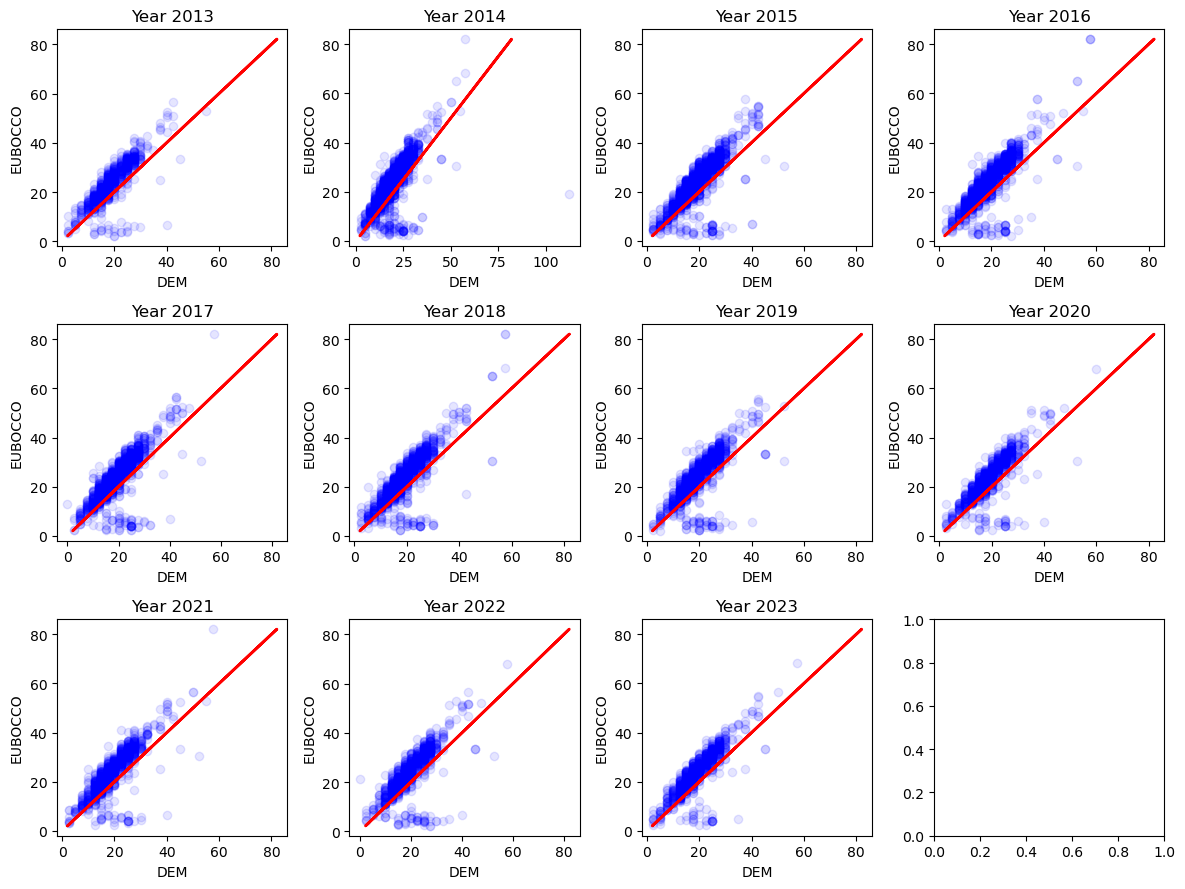

In [51]:
# Create a grid plot with 12 subplots arranged in a 3x4 grid
fig, axs = plt.subplots(3, 4, figsize=(12, 9))

# Flatten the axs array to easily access each subplot
axs = axs.flatten()

# Plot data in each subplot, skipping 2024
for i in range(12):
    year = 2013 + i
    if year == 2024:
        continue  # Skip plotting for 2024
    
    # Filter and sample 10% of the data
    data = barca[(barca['year'].astype(int) == year) & (barca['height_dem'] > 2)]
    sampled_data = data.sample(frac=0.1, random_state=42)  # Randomly sample 10% of the data
    
    print(len(sampled_data))  # Check the length of the sampled data

    axs[i].scatter(sampled_data['height'], sampled_data['height_dem'], 
                   color='blue', marker='o', alpha=0.1, label='Observed vs Predicted')
    axs[i].plot(data['height_dem'], data['height_dem'], 
                color='red', linestyle='-', linewidth=2, label='Perfect Prediction (45°)')  # Add a diagonal line for perfect prediction
    axs[i].set_title(f'Year {year}')
    axs[i].set_xlabel('DEM')
    axs[i].set_ylabel('EUBOCCO')

# Adjust layout and show plot
plt.tight_layout()
plt.show()

In [9]:
barca_dem_path = os.path.join(upath, r'shapefile/Barcelona/Barcelona_building-QH_BRA_share_HDD+refurbish_W2W-13%_as_built_W-KM-BT_13degree_OSM_v4_DEM.sqlite')
barca = gpd.read_file(barca_dem_path)

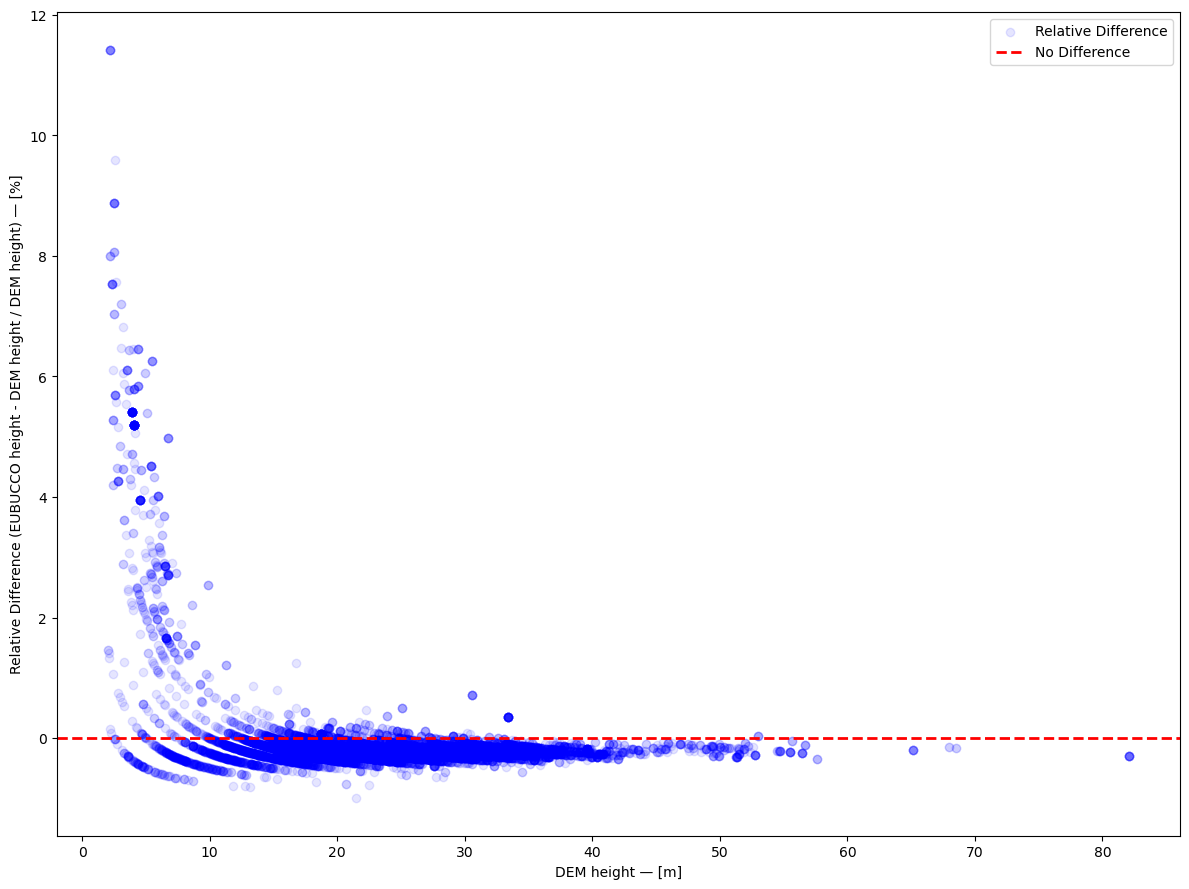

In [21]:
# Calculate relative difference (e.g., observed vs predicted normalized by predicted height_dem)
sampled_data['relative_difference'] = (
    sampled_data['height'] - sampled_data['height_dem']
) / sampled_data['height_dem']

# Scatter plot for relative difference
fig, ax = plt.subplots(figsize=(12, 9))
ax.scatter(
    sampled_data['height_dem'],  # Predicted (DEM values as the x-axis)
    sampled_data['relative_difference'],  # Relative difference as y-axis
    color='blue', marker='o', alpha=0.1, label='Relative Difference'
)

# Add horizontal line for zero relative difference
ax.axhline(0, color='red', linestyle='--', linewidth=2, label='No Difference')

# Set title and labels
ax.set_xlabel('DEM height — [m]')
ax.set_ylabel('Relative Difference (EUBUCCO height - DEM height / DEM height) — [%]')

# Add legend
ax.legend()

# Adjust layout and show plot
plt.tight_layout()
plt.show()


In [46]:
barca.columns

Index(['index_left', 'bolig_type', 'id', 'height', 'age', 'type', 'id_source',
       'type_sourc', 'neighbors', 'wall_length', 'wall_height', 'shared_wall',
       'barca_index_right', 'consum_ene', 'data_entra', 'building_cluster',
       'renovation_status', 'scaled_data_entra', 'date_ec', 'year',
       'qh_(kwh/m2a).001_1_12013', 'qh_(kwh/m2a).001_1_12014',
       'qh_(kwh/m2a).001_1_12015', 'qh_(kwh/m2a).001_1_12016',
       'qh_(kwh/m2a).001_1_12017', 'qh_(kwh/m2a).001_1_12018',
       'qh_(kwh/m2a).001_1_12019', 'qh_(kwh/m2a).001_1_12020',
       'qh_(kwh/m2a).001_1_12021', 'qh_(kwh/m2a).001_1_12022',
       'qh_(kwh/m2a).001_1_12023', 'height_dem', 'geometry'],
      dtype='object')

In [16]:
import geopandas as gpd
import folium
from branca.colormap import linear

def visualize_building_age(gdf, age_col="building_age"):
    # Ensure GeoDataFrame has the correct CRS
    gdf = gdf.to_crs("EPSG:4326")

    # Convert Timestamp to string if present
    datetime_columns = gdf.select_dtypes(include=['datetime64[ns]', 'datetime']).columns
    for col in datetime_columns:
        gdf[col] = gdf[col].astype(str)

    # Reproject to a projected CRS for centroid calculations
    gdf_projected = gdf.to_crs("EPSG:3857")

    # Compute the center of the map
    center_lat = gdf_projected.geometry.centroid.y.mean()
    center_lon = gdf_projected.geometry.centroid.x.mean()

    # Create a base map
    m = folium.Map(location=[center_lat, center_lon], zoom_start=13, tiles="OpenStreetMap")

    # Normalize building age for color mapping
    min_age, max_age = gdf[age_col].min(), gdf[age_col].max()
    colormap = linear.viridis.scale(min_age, max_age)
    colormap.caption = "Building Age"

    # Add building polygons to the map
    folium.GeoJson(
        gdf,
        style_function=lambda feature: {
            "fillColor": colormap(feature["properties"][age_col]),
            "color": "black",
            "weight": 0.5,
            "fillOpacity": 0.7,
        },
        tooltip=folium.GeoJsonTooltip(fields=[age_col], aliases=["Building Age"]),
    ).add_to(m)

    # Add the color legend to the map
    colormap.add_to(m)

    return m

In [ ]:
# Example usage
# Replace with your actual GeoDataFrame
# Ensure 'building_age' is a column in your GeoDataFrame containing the building age data
gdf = gpd.read_file(os.path.join(upath, r'shapefile/Barcelona/Barcelona_building-QH_BRA_share_HDD+refurbish_W2W-13%_as_built_W-KM-BT_13degree_OSM_v4_DEM.sqlite'))  # Replace with your file
# gdf["building_age"] = gdf["age"].apply(lambda x: 2025 - x)  # Calculate building age

# Visualize the map
map_with_buildings = visualize_building_age(gdf, age_col="age")
map_with_buildings

In [ ]:
gdf.explore()

In [6]:
final_df.to_csv(r'/home/babakebrahimi/s3/data/Barcelona/plot_Barcelona.csv')

/home/babakebrahimi/.local/lib/python3.9/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


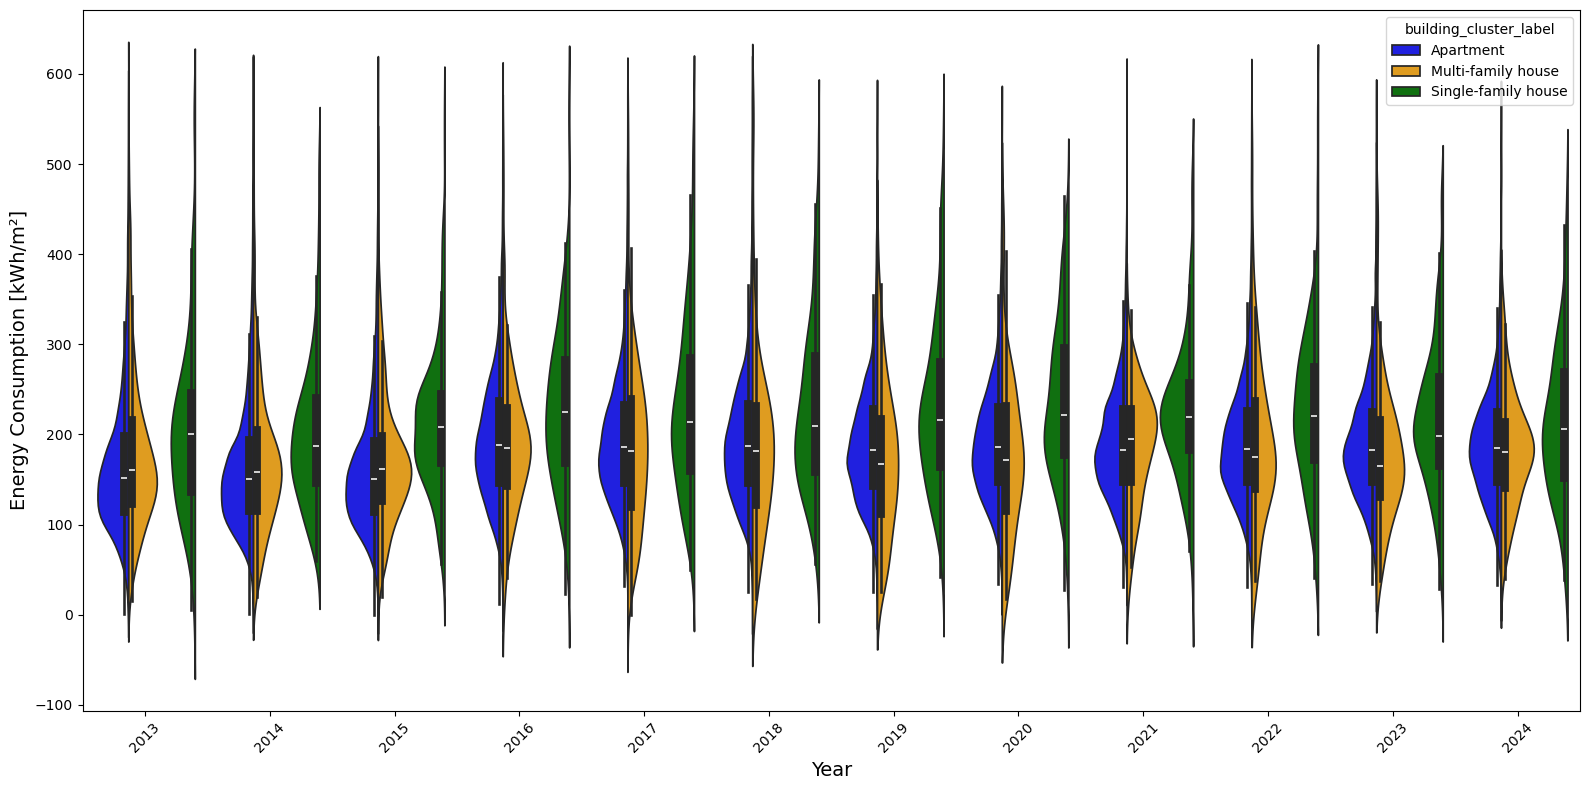

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

upath = r'/home/babakebrahimi/s3/data'

arca_dem_path = os.path.join(upath, r'shapefile/Barcelona/Barcelona_building-QH_BRA_share_HDD+refurbish_W2W-13%_as_built_W-KM-BT_13degree_OSM_v4_DEM.sqlite')
barca = gpd.read_file(barca_dem_path)

# Filter out energy values above 600
filtered_barca = barca[barca['consum_ene'] <= 600]

# Map building cluster labels to more descriptive names
cluster_labels = {
    "AB": "Apartment",
    "SFH": "Single-family house",
    "MFH": "Multi-family house"
}

# Add a column for labeled building clusters
filtered_barca['building_cluster_label'] = filtered_barca['building_cluster'].map(cluster_labels)

# Create a violin plot
fig, ax = plt.subplots(figsize=(16, 8))  # Increase figure width for wider gaps
sns.violinplot(
    data=filtered_barca,
    x='year',
    y='consum_ene',
    hue='building_cluster_label',
    split=True,
    palette={"Apartment": "blue", "Single-family house": "green", "Multi-family house": "orange"},
    ax=ax
)

# Set plot title and labels
# ax.set_title('Energy Consumption Distribution by Building Type Over Years', fontsize=16)
ax.set_xlabel('Year', fontsize=14)
ax.set_ylabel('Energy Consumption [kWh/m²]', fontsize=14)

# Add room between years on x-axis
unique_years = sorted(filtered_barca['year'].unique())
ax.set_xticks(range(len(unique_years)))
ax.set_xticklabels(unique_years, fontsize=10, rotation=45)
ax.set_xlim(-0.5, len(unique_years) - 0.5)

# Adjust layout and display the plot
plt.tight_layout()
plt.show()


In [2]:
from scipy.optimize import minimize
import numpy as np
import pandas as pd
import geopandas as gpd
import os

idx = pd.IndexSlice

def QH_calc_optimized(VV, year, BRA, WR):
    """
    Calculates heating demand (QH) as a function of VV for a specific year.
    
    Parameters:
    - bolig: GeoDataFrame containing building data.
    - buil_set: DataFrame containing TABULA building set data.
    - VV: Ventilation multiplier (scalar).
    - year: Year for which to compute QH values.
    
    Returns:
    - List of QH values (kWh/m2a) for the specified year and VV.
    """

    upath = r'/home/babakebrahimi/s3/data'
    
    # Extracting parts of TABULA spreadsheet
    buil_set = pd.read_excel(os.path.join(upath, 'tabula-episcope', 'subset_TABULA.xlsx'))
    sys_set = pd.read_excel(os.path.join(upath, 'tabula-episcope', 'TABULA_sys_set_ES.xlsx'))
    
    # Removing rows that don't represent a country 
    buil_set = buil_set[buil_set['Code_Country'].notna()]
    buil_set = buil_set[buil_set['Description_BuildingVariant'].notna()]
    buil_set = buil_set[buil_set['Code_Country'] != 'XX']

    # Creating a multiindex
    buil_set.set_index(['Code_Country', 'Code_DataType_Building', 'Name_ClimateRegion', 
                        'Description_BuildingVariant', 'Code_BuildingSizeClass', 
                        'Year1_Building', 'Year2_Building'], inplace=True)

    buil_set = buil_set.sort_index(level=[0, 1, 2, 3, 4])

    # Creating a multiindex for system set
    sys_set.set_index(['Code_BuildingVariant'], inplace=True)
    sys_set = sys_set.sort_index(level=[0])

    read_file = os.path.join(upath,r'shapefile/Barcelona/Barcelona_building-QH_BRA_share_HDD+refurbish_W2W-13%_as_built_W-KM-BT_13degree_OSM_v4_DEM.sqlite')
    # Reading the generated shapefile containing building info   
    bolig = gpd.read_file(read_file).to_crs('EPSG:3857').reset_index(drop=True)

    # Filtering out buildings without age attribute
    bolig = bolig[(bolig['age'].notna()) & (bolig['type_sourc'] == '1_residential')]

    # Define constants
    CO = 'ES'
    Typo = 'ReEx'
    Cl = 'Mediterranean'
    COND_dic = {
        1: ['Existing condition'],
        2: ['Level 1 of improvements'],
        3: ['Level 2 of improvements']
    }

    # Filter buildings for the specified year
    bolig_filtered = bolig[(bolig['year'] == year) & (bolig['age'] < 2000)]
    
    # Randomly select 10% of the data (if not empty)
    if not bolig_filtered.empty:
        bolig_filtered = bolig_filtered.sample(frac=0.01, random_state=42)  # 10% sample

    
    if bolig_filtered.empty:
        print(f"No valid buildings found for year {year}.")
        return [], []

    QH_values = []
    ene_cons = []
    
    # Looping through building energy performance levels
    for c in [2]:
             
        for index, row in bolig_filtered.iterrows():
                
            B_type = row['bolig_type']
            
            Y = row['age']
            
            # Creating a multiindex element
            i = None
            for a in buil_set.loc[(CO, Typo, Cl, COND_dic[c], B_type)].index:
                if a[-2] <= Y <= a[-1]:
                    y0, y1 = a[-2], a[-1]
                    i = (CO, Typo, Cl, COND_dic[c], B_type, y0, y1)
                    break
            
            if i is None:
                continue  # Skip if no matching index found
            
            try:
                if 0 <= Y <= 1955:
                    sys_i = f"{CO}.ME.{B_type}.01.Gen.{Typo}.001.00{c}"
                elif 1956 <= Y <= 1970:
                    sys_i = f"{CO}.ME.{B_type}.02.Gen.{Typo}.001.00{c}"
                elif 1971 <= Y <= 1980:
                    sys_i = f"{CO}.ME.{B_type}.03.Gen.{Typo}.001.00{c}"
                elif 1981 <= Y <= 1990:
                    sys_i = f"{CO}.ME.{B_type}.04.Gen.{Typo}.001.00{c}"
                elif 1991 <= Y <= 2000:
                    sys_i = f"{CO}.ME.{B_type}.05.Gen.{Typo}.001.00{c}"
                elif 2001 <= Y <= 2010:
                    sys_i = f"{CO}.ME.{B_type}.06.Gen.{Typo}.001.00{c}"
                elif 2011 <= Y <= 9999:
                    sys_i = f"{CO}.ME.{B_type}.07.Gen.{Typo}.001.00{c}"
                else:
                    raise ValueError("Unexpected value of Y:", Y)
            except Exception as e:
                print("Error:", e)
                continue  # Skip to next iteration
    
            # Estimated air-conditioned area
            A_C_est = BRA * row['geometry'].area
    
            # Estimated areas
            A_roof_est = BRA * row['geometry'].area
            A_floor_est = BRA * row['geometry'].area
            A_wall_est = WR * ((row.geometry.length * row['height_dem'] - row['shared_wall']) * (1 - 0.13))
            A_window_est = WR * ((row.geometry.length * row['height_dem'] - row['shared_wall']) * 0.13)
            A_door_est = 0
    
            # Heat transfer coefficients
            Htr_roof = buil_set.loc[idx[i], 'U_Roof_1'].values * A_roof_est * buil_set.loc[idx[i], 'b_Transmission_Roof_1'].values
            Htr_floor = buil_set.loc[idx[i], 'U_Floor_1'].values * A_floor_est * buil_set.loc[idx[i], 'b_Transmission_Floor_1'].values
            Htr_wall = buil_set.loc[idx[i], 'U_Wall_1'].values * A_wall_est * buil_set.loc[idx[i], 'b_Transmission_Wall_1'].values
            Htr_window = buil_set.loc[idx[i], 'U_Window_1'].values * A_window_est
            Htr_door = buil_set.loc[idx[i], 'U_Door_1'].values * A_door_est
            Htr_tb = buil_set.loc[idx[i], 'delta_U_ThermalBridging_Original'].values * (A_roof_est + A_floor_est + A_wall_est + A_window_est + A_door_est)
    
            Htr = Htr_roof + Htr_floor + Htr_wall + Htr_window + Htr_door + Htr_tb
    
            # Heat transfer by ventilation
            Cp_air = 0.34
            Hve = Cp_air * (buil_set.loc[idx[i], 'n_air_use'].values + buil_set.loc[idx[i], 'n_air_infiltration'].values) * A_C_est * buil_set.loc[idx[i], 'h_room'].values
    
            # Internal temperature
            if buil_set.loc[idx[i],'theta_i'].values >= 0:
                int_tmp = buil_set.loc[idx[i], 'theta_i']
            else:
                int_tmp = buil_set.loc[idx[i], 'theta_i_htr1'].values + (Htr - 1) / 3 * (buil_set.loc[idx[i], 'theta_i_htr4'].values - buil_set.loc[idx[i], 'theta_i_htr1'].values)
    
            tmp = (int_tmp - buil_set.loc[idx[i], 'Theta_e'].values) * VV
    
            # Ensure Htr and A_C_est are not zero or NaN
            if A_C_est is None or A_C_est == 0 or np.isnan(A_C_est):
                Fred = np.nan
            elif Htr is None or Htr == 0 or np.isnan(Htr):
                Fred = np.nan
            else:
                # Temperature reduction factor
                if Htr / A_C_est <= 1:
                    Fred = min(
                        buil_set.loc[idx[i], 'F_red_htr1'].values + 
                        (1 - (Htr / A_C_est)) / 0.5 * 
                        (1 - buil_set.loc[idx[i], 'F_red_htr1'].values), 1
                    )
                elif Htr / A_C_est >= 4:
                    Fred = buil_set.loc[idx[i], 'F_red_htr4'].values
                else:
                    Fred = (
                        buil_set.loc[idx[i], 'F_red_htr1'].values +
                        (Htr / A_C_est - 1) * 
                        (buil_set.loc[idx[i], 'F_red_htr4'].values - buil_set.loc[idx[i], 'F_red_htr1'].values) / 3
                    )
    
            # Ensure Hve is not zero or NaN before computing aH
            if Htr + Hve > 0:
                aH = 0.8 + ((buil_set.loc[idx[i], 'c_m'].values * A_C_est / (Htr + Hve)) / 30)
            else:
                aH = np.nan  # Handle invalid cases gracefully
            
            Qht = (Htr + Hve) * Fred * (tmp * 0.024)
    
            # Solar heat load
            Qsol = 0
            for w in ['Hor', 'East', 'South', 'West', 'North']:
                if w == 'Hor':
                    Qsol += buil_set.loc[idx[i], 'F_sh_hor'].values * (1 - buil_set.loc[idx[i], 'F_f'].values) * buil_set.loc[idx[i], 'F_w'].values * buil_set.loc[idx[i], 'g_gl_n_Window_1'].values * 0 * buil_set.loc[idx[i], f'I_Sol_{w}'].values
                else:
                    Qsol += buil_set.loc[idx[i], 'F_sh_vert'].values * (1 - buil_set.loc[idx[i], 'F_f'].values) * buil_set.loc[idx[i], 'F_w'].values * buil_set.loc[idx[i], 'g_gl_n_Window_1'].values * (A_window_est * 0.25) * buil_set.loc[idx[i], f'I_Sol_{w}'].values
    
            # Internal heat source
            Qint = 0.024 * buil_set.loc[idx[i], 'phi_int'].values * VV * A_C_est
    
            # Check if Htr + Hve is valid
            if Htr is None or Hve is None or np.isnan(Htr) or np.isnan(Hve) or (Htr + Hve) == 0:
                aH = np.nan  # Assign NaN if the denominator is invalid
            else:
                aH = 0.8 + ((buil_set.loc[idx[i], 'c_m'].values * A_C_est / (Htr + Hve)) / 30)
    
            # Heat balance ratio
            lamd = (Qsol + Qint) / Qht
    
            # Gain utilization factor for heating
            mu = (1 - lamd ** aH) / (1 - lamd ** (aH + 1))
    
            # Energy needed for heating
            QH = Qht - mu * (Qsol + Qint)

            # Debugging QH Type
            # print(f"QH type: {type(QH)}, QH shape: {QH.shape if hasattr(QH, 'shape') else 'scalar'}")

            # Ensure QH is a scalar
            if isinstance(QH, pd.Series):
                QH = QH.iloc[0]  # Take first value if Series
            elif isinstance(QH, np.ndarray):
                QH = QH[0]  # Take first value if array
            
            # Validate QH value
            if QH is None or np.isnan(QH) or QH < 0:
                continue  # Skip invalid results
                
            if np.isnan(QH).any():
                print(f"Invalid QH {QH} for index {index}.")
            
            # Ensure QH is a valid numeric value
            if isinstance(QH, (list, np.ndarray, pd.Series)):  
                QH_values.append(QH[0] / A_C_est)  # Take first element if iterable
            else:
                QH_values.append(QH / A_C_est)  # Use directly if scalar
            
            if isinstance(QH, (np.ndarray, pd.Series)) and np.isnan(QH).any():
                print(f"Invalid QH {QH} for index {index}.")
            elif np.isnan(QH):
                print(f"Invalid QH {QH} for index {index}.")
            
            # making sure that the observed_y represent only half of the consumed energy since in accordance with Energia Barcelona 
            # only half of the consumed energy is corresponding to the domestic heating and hot water demand. 
            ene_cons.append(row['consum_ene']/2)

    return QH_values, ene_cons

def mse(VV, year, BRA, WR):
    """
    Mean Squared Error function for optimization.
    """
    QH_values, observed_y = QH_calc_optimized(VV, year, BRA, WR)

    # Convert observed_y to a NumPy array
    observed_y = np.array(observed_y, dtype=np.float64)

    # Validate QH_calc_optimized Output
    if QH_values is None or len(QH_values) == 0 or np.isnan(QH_values).any():
        print(f"Invalid QH_values for year {year} and VV {VV}. Applying penalty.")
        return 1e6  # Large penalty for invalid results
    if observed_y is None or len(observed_y) == 0 or np.isnan(observed_y).any():
        print(f"Invalid observed_y for year {year}. Applying penalty.")
        return 1e6  # Large penalty for missing observed data

    # Check alignment between QH_values and observed_y
    if len(QH_values) != len(observed_y):
        print(f"Mismatch in data lengths for year {year}: QH_values ({len(QH_values)}) vs observed_y ({len(observed_y)}).")
        return 1e6  # Large penalty for mismatched lengths

    # Compute MSE
    return np.mean((np.array(QH_values) - observed_y) ** 2)

def optimize_VV_per_years(years):
    """
    Optimizes VV, BRA, and WR for each year to minimize MSE.
    """
    optimal_values = {}

    for year in years:
        print(f"Optimizing for year: {year}")

        # Define the MSE function to minimize for the specific year
        def mse_for_year(params):
            VV, BRA, WR = params  # Unpack parameters
            return mse(VV, year, BRA, WR) # Ensure mse is defined

        # Initial guesses for VV and ratio
        initial_guess = [100.0, 1, 1]  # VV=100.0, BRA=1, WR=1
        bounds = [(1, 300), (0.6, 1), (0.6, 1)]  # Bounds for VV, BRA, WR

        # Perform optimization for the current year
        result = minimize(
            mse_for_year,
            x0=initial_guess,  # Initial guesses for VV, BRA, WR
            bounds=bounds,     # Bounds for parameters
            method="L-BFGS-B"  # Bounded optimization method
        )

        # Check if optimization was successful
        if result.success:
            optimal_values[year] = (result.x[0], result.x[1], result.x[2])
            print(f"Year: {year}, Optimal VV: {result.x[0]}, Optimal BRA: {result.x[1]}, Optimal WR: {result.x[2]}, MSE: {result.fun}")
        else:
            print(f"Optimization failed for year {year}. Reason: {result.message}")

    return optimal_values
    
# Run the optimization
years_to_optimize = list(range(2020, 2021))
optimal_VV_results = optimize_VV_per_years(years_to_optimize)

# Store results in a DataFrame
results_df = pd.DataFrame(
    {
        "Year": list(optimal_VV_results.keys()),
        "Optimal VV": [v[0] if v else np.nan for v in optimal_VV_results.values()],
        "Optimal BRA": [v[1] if v else np.nan for v in optimal_VV_results.values()],
        "Optimal WR": [v[2] if v else np.nan for v in optimal_VV_results.values()]
    }
)

# Output the DataFrame
print("Optimal VV, BRA, WR values per year:")
print(results_df)

# Save to a CSV file for future reference
results_df.to_csv("/home/babakebrahimi/s3/data/Barcelona_optimal_VV_BRA_WR_results.csv", index=False)

Optimizing for year: 2020
Year: 2020, Optimal VV: 58.174867323687664, Optimal BRA: 1.0, Optimal WR: 0.6, MSE: 3246.8516656782017
Optimal VV, BRA, WR values per year:
   Year  Optimal VV  Optimal BRA  Optimal WR
0  2020   58.174867          1.0         0.6


In [8]:
def QH_calc(write_file):
    """
    Calculates heating demand (QH) as a function of VV for a specific year.
    
    Parameters:
    - bolig: GeoDataFrame containing building data.
    - buil_set: DataFrame containing TABULA building set data.
    - VV: Ventilation multiplier (scalar).
    - year: Year for which to compute QH values.
    
    Returns:
    - List of QH values (kWh/m2a) for the specified year and VV.
    """

    upath = r'/home/babakebrahimi/s3/data'
    
    # Extracting parts of TABULA spreadsheet
    buil_set = pd.read_excel(os.path.join(upath, 'tabula-episcope', 'subset_TABULA.xlsx'))
    sys_set = pd.read_excel(os.path.join(upath, 'tabula-episcope', 'TABULA_sys_set_ES.xlsx'))
    
    # Removing rows that don't represent a country 
    buil_set = buil_set[buil_set['Code_Country'].notna()]
    buil_set = buil_set[buil_set['Description_BuildingVariant'].notna()]
    buil_set = buil_set[buil_set['Code_Country'] != 'XX']

    # Creating a multiindex
    buil_set.set_index(['Code_Country', 'Code_DataType_Building', 'Name_ClimateRegion', 
                        'Description_BuildingVariant', 'Code_BuildingSizeClass', 
                        'Year1_Building', 'Year2_Building'], inplace=True)

    buil_set = buil_set.sort_index(level=[0, 1, 2, 3, 4])

    # Creating a multiindex for system set
    sys_set.set_index(['Code_BuildingVariant'], inplace=True)
    sys_set = sys_set.sort_index(level=[0])

    read_file = os.path.join(upath,r'shapefile/Barcelona/Barcelona_building-QH_BRA_share_HDD+refurbish_W2W-13%_as_built_W-KM-BT_13degree_OSM_v4_DEM.sqlite')
    # Reading the generated shapefile containing building info   
    bolig = gpd.read_file(read_file).to_crs('EPSG:3857').reset_index(drop=True)

    # Filtering out buildings without age attribute
    bolig = bolig[(bolig['age'].notna()) & (bolig['type_sourc'] == '1_residential')]

    # Define constants
    CO = 'ES'
    Typo = 'ReEx'
    Cl = 'Mediterranean'
    COND_dic = {
        1: ['Existing condition'],
        2: ['Level 1 of improvements'],
        3: ['Level 2 of improvements']
    }

    opt = pd.read_csv(r'/home/babakebrahimi/s3/data/optimization/Barcelona_optimal_VV_BRA_WR_results.csv')

    YY = opt['Year']

    # Filter buildings for the specified year
    bolig_filtered = bolig[(bolig['year'] == opt['Year'][0])]
    
    # Randomly select 10% of the data (if not empty)
    if not bolig_filtered.empty:
        bolig_filtered = bolig_filtered.sample(frac=1, random_state=42)  # 10% sample

    
    if bolig_filtered.empty:
        print(f"No valid buildings found for year {year}.")
        return [], []

    QH_values = []
    ene_cons = []
    
    # Looping through building energy performance levels
    for c in [1,2]:
             
        for index, row in bolig_filtered.iterrows():

        # Ensure 'År' meets the condition based on c
            if (c == 1 and row['age'] < 2000) or (c == 2 and row['age'] >= 2000):
                continue  # Skip this row if it doesn't meet the condition
                
            B_type = row['bolig_type']
            
            Y = row['age']
            
            # Creating a multiindex element
            i = None
            for a in buil_set.loc[(CO, Typo, Cl, COND_dic[c], B_type)].index:
                if a[-2] <= Y <= a[-1]:
                    y0, y1 = a[-2], a[-1]
                    i = (CO, Typo, Cl, COND_dic[c], B_type, y0, y1)
                    break
            
            if i is None:
                continue  # Skip if no matching index found
            
            try:
                if 0 <= Y <= 1955:
                    sys_i = f"{CO}.ME.{B_type}.01.Gen.{Typo}.001.00{c}"
                elif 1956 <= Y <= 1970:
                    sys_i = f"{CO}.ME.{B_type}.02.Gen.{Typo}.001.00{c}"
                elif 1971 <= Y <= 1980:
                    sys_i = f"{CO}.ME.{B_type}.03.Gen.{Typo}.001.00{c}"
                elif 1981 <= Y <= 1990:
                    sys_i = f"{CO}.ME.{B_type}.04.Gen.{Typo}.001.00{c}"
                elif 1991 <= Y <= 2000:
                    sys_i = f"{CO}.ME.{B_type}.05.Gen.{Typo}.001.00{c}"
                elif 2001 <= Y <= 2010:
                    sys_i = f"{CO}.ME.{B_type}.06.Gen.{Typo}.001.00{c}"
                elif 2011 <= Y <= 9999:
                    sys_i = f"{CO}.ME.{B_type}.07.Gen.{Typo}.001.00{c}"
                else:
                    raise ValueError("Unexpected value of Y:", Y)
            except Exception as e:
                print("Error:", e)
                continue  # Skip to next iteration
    
            # Estimated air-conditioned area
            A_C_est = opt['Optimal BRA'][0] * row['geometry'].area
    
            # Estimated areas
            A_roof_est = opt['Optimal BRA'][0] * row['geometry'].area
            A_floor_est = opt['Optimal BRA'][0] * row['geometry'].area
            A_wall_est = opt['Optimal WR'][0] * ((row.geometry.length * row['height_dem'] - row['shared_wall']) * (1 - 0.13))
            A_window_est = opt['Optimal WR'][0] * ((row.geometry.length * row['height_dem'] - row['shared_wall']) * 0.13)
            A_door_est = 0
    
            # Heat transfer coefficients
            Htr_roof = buil_set.loc[idx[i], 'U_Roof_1'].values * A_roof_est * buil_set.loc[idx[i], 'b_Transmission_Roof_1'].values
            Htr_floor = buil_set.loc[idx[i], 'U_Floor_1'].values * A_floor_est * buil_set.loc[idx[i], 'b_Transmission_Floor_1'].values
            Htr_wall = buil_set.loc[idx[i], 'U_Wall_1'].values * A_wall_est * buil_set.loc[idx[i], 'b_Transmission_Wall_1'].values
            Htr_window = buil_set.loc[idx[i], 'U_Window_1'].values * A_window_est
            Htr_door = buil_set.loc[idx[i], 'U_Door_1'].values * A_door_est
            Htr_tb = buil_set.loc[idx[i], 'delta_U_ThermalBridging_Original'].values * (A_roof_est + A_floor_est + A_wall_est + A_window_est + A_door_est)
    
            Htr = Htr_roof + Htr_floor + Htr_wall + Htr_window + Htr_door + Htr_tb
    
            # Heat transfer by ventilation
            Cp_air = 0.34
            Hve = Cp_air * (buil_set.loc[idx[i], 'n_air_use'].values + buil_set.loc[idx[i], 'n_air_infiltration'].values) * A_C_est * buil_set.loc[idx[i], 'h_room'].values
    
            # Internal temperature
            if buil_set.loc[idx[i],'theta_i'].values >= 0:
                int_tmp = buil_set.loc[idx[i], 'theta_i']
            else:
                int_tmp = buil_set.loc[idx[i], 'theta_i_htr1'].values + (Htr - 1) / 3 * (buil_set.loc[idx[i], 'theta_i_htr4'].values - buil_set.loc[idx[i], 'theta_i_htr1'].values)
    
            tmp = (int_tmp - buil_set.loc[idx[i], 'Theta_e'].values) * opt['Optimal VV'][0]
    
            # Ensure Htr and A_C_est are not zero or NaN
            if A_C_est is None or A_C_est == 0 or np.isnan(A_C_est):
                Fred = np.nan
            elif Htr is None or Htr == 0 or np.isnan(Htr):
                Fred = np.nan
            else:
                # Temperature reduction factor
                if Htr / A_C_est <= 1:
                    Fred = min(
                        buil_set.loc[idx[i], 'F_red_htr1'].values + 
                        (1 - (Htr / A_C_est)) / 0.5 * 
                        (1 - buil_set.loc[idx[i], 'F_red_htr1'].values), 1
                    )
                elif Htr / A_C_est >= 4:
                    Fred = buil_set.loc[idx[i], 'F_red_htr4'].values
                else:
                    Fred = (
                        buil_set.loc[idx[i], 'F_red_htr1'].values +
                        (Htr / A_C_est - 1) * 
                        (buil_set.loc[idx[i], 'F_red_htr4'].values - buil_set.loc[idx[i], 'F_red_htr1'].values) / 3
                    )
    
            # Ensure Hve is not zero or NaN before computing aH
            if Htr + Hve > 0:
                aH = 0.8 + ((buil_set.loc[idx[i], 'c_m'].values * A_C_est / (Htr + Hve)) / 30)
            else:
                aH = np.nan  # Handle invalid cases gracefully
            
            Qht = (Htr + Hve) * Fred * (tmp * 0.024)
    
            # Solar heat load
            Qsol = 0
            for w in ['Hor', 'East', 'South', 'West', 'North']:
                if w == 'Hor':
                    Qsol += buil_set.loc[idx[i], 'F_sh_hor'].values * (1 - buil_set.loc[idx[i], 'F_f'].values) * buil_set.loc[idx[i], 'F_w'].values * buil_set.loc[idx[i], 'g_gl_n_Window_1'].values * 0 * buil_set.loc[idx[i], f'I_Sol_{w}'].values
                else:
                    Qsol += buil_set.loc[idx[i], 'F_sh_vert'].values * (1 - buil_set.loc[idx[i], 'F_f'].values) * buil_set.loc[idx[i], 'F_w'].values * buil_set.loc[idx[i], 'g_gl_n_Window_1'].values * (A_window_est * 0.25) * buil_set.loc[idx[i], f'I_Sol_{w}'].values
    
            # Internal heat source
            Qint = 0.024 * buil_set.loc[idx[i], 'phi_int'].values * opt['Optimal VV'][0] * A_C_est
    
            # Check if Htr + Hve is valid
            if Htr is None or Hve is None or np.isnan(Htr) or np.isnan(Hve) or (Htr + Hve) == 0:
                aH = np.nan  # Assign NaN if the denominator is invalid
            else:
                aH = 0.8 + ((buil_set.loc[idx[i], 'c_m'].values * A_C_est / (Htr + Hve)) / 30)
    
            # Heat balance ratio
            lamd = (Qsol + Qint) / Qht
    
            # Gain utilization factor for heating
            mu = (1 - lamd ** aH) / (1 - lamd ** (aH + 1))
    
            # Energy needed for heating
            QH = Qht - mu * (Qsol + Qint)
                        
            bolig_filtered.at[index, f'QH_(kWh/m2a)_OPT_2020'] = QH.iloc[0] / A_C_est

    return bolig_filtered.to_csv(write_file)

In [9]:
QH_calc(r'/home/babakebrahimi/s3/data/Oslo/Barcelona_optimized_2020_renovated.csv')

In [10]:
final_df = pd.read_csv(r'/home/babakebrahimi/s3/data/Oslo/Barcelona_optimized_2020_renovated.csv')

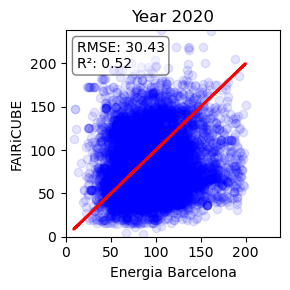

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

# Function to calculate and display RMSE and R² for 2D data
def calculate_and_display_metrics(ax, true_x, true_y, pred_x, pred_y):
    """
    Compute RMSE and R² for 2D predictor and true values and display them on a plot.

    Parameters:
        ax (matplotlib.axes.Axes): The axis to annotate the metrics.
        true_x (array-like): X-coordinates of true values.
        true_y (array-like): Y-coordinates of true values.
        pred_x (array-like): X-coordinates of predicted values.
        pred_y (array-like): Y-coordinates of predicted values.
    
    Returns:
        tuple: RMSE and R² values.
    """
    # Compute Euclidean distances for true and predicted points
    true_distances = np.sqrt(true_x**2 + true_y**2)
    pred_distances = np.sqrt(pred_x**2 + pred_y**2)

    # Compute RMSE and R² score
    mse = mean_squared_error(true_distances, pred_distances)
    rmse = np.sqrt(mse)
    r2 = r2_score(true_distances, pred_distances)

    # Annotate metrics on the plot
    ax.text(0.05, 0.95, f'RMSE: {rmse:.2f}\nR²: {r2:.2f}', transform=ax.transAxes, 
            fontsize=10, verticalalignment='top', bbox=dict(boxstyle="round", facecolor="white", alpha=0.5))
    
    return rmse, r2

# Define the specific year to plot
year_to_plot = 2020
column_name = f'QH_(kWh/m2a)_OPT_2020'

# Check if the column exists in the dataset
if column_name in final_df.columns:
    # Filter data for the selected year
    data = final_df[(final_df['year'].astype(int) == year_to_plot) & 
                    (final_df[column_name] < 600) & 
                    (final_df['consum_ene'] < 400) &
                    (final_df['consum_ene'] > 0)].copy()

    # Ensure non-empty dataset
    if not data.empty:
        true_x = data['consum_ene']/2
        true_y = data['consum_ene']/2
        pred_x = data['consum_ene']/2
        pred_y = data[column_name]

        # Create the plot
        fig, ax = plt.subplots(figsize=(3, 3))
        ax.scatter(true_x, pred_y, color='blue', marker='o', alpha=0.1)
        ax.plot(true_x, true_x, color='red', linestyle='-', linewidth=2)  # Diagonal reference line
        ax.set_title(f'Year {year_to_plot}')
        ax.set_xlabel('Energia Barcelona')
        ax.set_ylabel('FAIRiCUBE')

        # Ensure identical x- and y-axis scales
        max_limit = max(true_x.max(), pred_y.max())
        ax.set_xlim(0, max_limit)
        ax.set_ylim(0, max_limit)

        # Calculate and display metrics
        calculate_and_display_metrics(ax, true_x, true_y, pred_x, pred_y)

        # Adjust layout and show plot
        # plt.legend()
        plt.tight_layout()
        plt.savefig("barcelona_opt_energy_use_esimate.png", dpi=300)
        plt.show()


In [26]:
final_df = pd.read_csv(r'/home/babakebrahimi/s3/data/Barcelona/plot_Barcelona.csv')

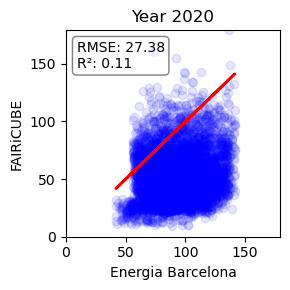

In [44]:
# Function to calculate and display RMSE and R² for 2D data
def calculate_and_display_metrics(ax, true_x, true_y, pred_x, pred_y):
    """
    Compute RMSE and R² for 2D predictor and true values and display them on a plot.

    Parameters:
        ax (matplotlib.axes.Axes): The axis to annotate the metrics.
        true_x (array-like): X-coordinates of true values.
        true_y (array-like): Y-coordinates of true values.
        pred_x (array-like): X-coordinates of predicted values.
        pred_y (array-like): Y-coordinates of predicted values.
    
    Returns:
        tuple: RMSE and R² values.
    """
    # Compute Euclidean distances for true and predicted points
    true_distances = np.sqrt(true_x**2 + true_y**2)
    pred_distances = np.sqrt(pred_x**2 + pred_y**2)

    # Compute RMSE and R² score
    mse = mean_squared_error(true_distances, pred_distances)
    rmse = np.sqrt(mse)
    r2 = r2_score(true_distances, pred_distances)

    # Annotate metrics on the plot
    ax.text(0.05, 0.95, f'RMSE: {rmse:.2f}\nR²: {r2:.2f}', transform=ax.transAxes, 
            fontsize=10, verticalalignment='top', bbox=dict(boxstyle="round", facecolor="white", alpha=0.5))
    
    return rmse, r2

# Define the specific year to plot
year_to_plot = 2020
column_name = f'qh_(kwh/m2a)_1_12020'

# Check if the column exists in the dataset
if column_name in final_df.columns:
    # Filter data for the selected year
    data = final_df[(final_df['year'].astype(int) == year_to_plot) & 
                    (final_df[column_name] < 400) &
                    (final_df['consum_ene'] < 400) &
                    (final_df['consum_ene'] > 0)].copy()

    # Ensure non-empty dataset
    if not data.empty:
        true_x = data['consum_ene']/2
        true_y = data['consum_ene']/2
        pred_x = data['consum_ene']/2
        pred_y = data[column_name]

        # Create the plot
        fig, ax = plt.subplots(figsize=(3, 3))
        ax.scatter(true_x, pred_y, color='blue', marker='o', alpha=0.1)
        ax.plot(true_x, true_x, color='red', linestyle='-', linewidth=2)  # Diagonal reference line
        ax.set_title(f'Year {year_to_plot}')
        ax.set_xlabel('Energia Barcelona')
        ax.set_ylabel('FAIRiCUBE')

        # Ensure identical x- and y-axis scales
        max_limit = max(true_x.max(), pred_y.max())
        ax.set_xlim(0, max_limit)
        ax.set_ylim(0, max_limit)

        # Calculate and display metrics
        calculate_and_display_metrics(ax, true_x, true_y, pred_x, pred_y)

        # Adjust layout and show plot
        # plt.legend()
        plt.tight_layout()
        plt.savefig("barcelona_original_energy_use_esimate.png", dpi=300)
        plt.show()

In [7]:
gdf.crs

<Derived Projected CRS: EPSG:25831>
Name: ETRS89 / UTM zone 31N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Europe between 0°E and 6°E: Andorra; Belgium - onshore and offshore; Denmark - offshore; Germany - offshore; Jan Mayen - offshore; Norway including Svalbard - onshore and offshore; Spain - onshore and offshore.
- bounds: (0.0, 37.0, 6.01, 82.45)
Coordinate Operation:
- name: UTM zone 31N
- method: Transverse Mercator
Datum: European Terrestrial Reference System 1989 ensemble
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [47]:
import pandas as pd
import geopandas as gpd
from shapely import wkt

# Step 1: Load CSV
final_df = pd.read_csv(r'/home/babakebrahimi/s3/data/Oslo/Barcelona_optimized_2020_renovated.csv')

# Step 2: Convert 'geometry' column to shapely geometries
final_df['geometry'] = final_df['geometry'].apply(wkt.loads)

# Step 3: Create a GeoDataFrame
gdf = gpd.GeoDataFrame(final_df, geometry='geometry', crs='EPSG:3857')



In [44]:
# List of columns to drop
columns_to_drop = [
    'Unnamed: 0', 'index_left', 'id', 'type', 'id_source',
 'type_sourc', 'height',
 'neighbors',
 'wall_length',
 'wall_height'
]

# Drop all qh_... columns except qh_(kwh/m2a)_0.7_0.9XXXX
years = list(range(2010, 2023))
for col in gdf.columns:
    if col.startswith('qh_'):
        keep = any(col == f'qh_(kwh/m2a)_0_0{year}' for year in years)
        if not keep:
            columns_to_drop.append(col)

gdf = gdf.drop(columns=[col for col in columns_to_drop if col in gdf.columns])

# Step 2: Rename 'qh_(kwh/m2a)_0.7_0.9XXXX' → 'qh_(kwh/m2a)_XXXX'
# rename_qh_cols = {
#     f'qh_(kwh/m2a)_1_1{year}': f'qh_(kwh/m2a)_{year}' for year in years
# }

# # Add the repetitive columns (e.g., qh_(...)_YEAR) using a pattern
# years = list(range(2010, 2023))
# versions = ['0.6', '0.7']
# levels = ['0.5', '0.7', '0.9']
# metrics = ['qh_(kwh/a)', 'qh_(kwh/m2a)']

# for year in years:
#     for version in versions:
#         for level in levels:
#             for metric in metrics:
#                 col_name = f"{metric}_{version}_{level}{year}"
#                 columns_to_drop.append(col_name)


# Step 3: Rename other columns
manual_renames = {
    'age': 'construction_year',
    'consum_ene': 'observed_energy_performance',
    'bolig_type': 'building_type',
    'height_dem': 'height'
}

# # Combine and apply all renames
# gdf = gdf.rename(columns={**rename_qh_cols, **manual_renames})

# # # Combine and apply all renames
gdf = gdf.rename(columns={**manual_renames})

In [45]:
gdf.head()

,building_type,construction_year,shared_wall,barca_index_right,observed_energy_performance,data_entra,building_cluster,renovation_status,scaled_data_entra,date_ec,year,height,geometry,QH_(kWh/m2a)_OPT_2020
0,AB,1963.0,0.000000,1225855.0,143.65,2.020121e+13,AB,Unknown,20201214.0,2020-12-14,2020,14.518309,"POLYGON ((245800.699 5074755.692, 245800.287 5...",64.686091
1,AB,1970.0,670.226329,1243823.0,226.62,2.020031e+13,AB,Unknown,20200309.0,2020-03-09,2020,31.155161,"POLYGON ((244048.591 5076658.507, 244048.876 5...",80.887595
2,AB,1936.0,523.329172,885856.0,137.06,2.020081e+13,AB,Unknown,20200809.0,2020-08-09,2020,13.515184,"POLYGON ((240749.483 5067696.889, 240752.19 50...",84.494322
3,AB,1963.0,69.216569,1079645.0,75.13,2.020091e+13,AB,Unknown,20200910.0,2020-09-10,2020,14.109299,"POLYGON ((242875.356 5078822.118, 242876.411 5...",74.278618
4,AB,1910.0,986.582261,419442.0,393.19,2.020073e+13,AB,Unknown,20200729.0,2020-07-29,2020,26.146751,"POLYGON ((242250.415 5068783.177, 242253.249 5...",121.369012


In [46]:
# Save as GeoJSON
gdf.to_file('/home/babakebrahimi/s3/data/Barcelona/Barcelona_EPISCOPE_OPT_2020.geojson', driver='GeoJSON')